## Bring Up Resources

In [ ]:
from fabrictestbed_extensions.fablib.fablib import FablibManager as fablib_manager
import json, ipaddress, itertools, re
from collections import defaultdict
from pathlib import Path
import networkx as nx
from networkx.readwrite import json_graph


fablib = fablib_manager()
conf = fablib.show_config()

CONFIG_PATH = "small_config.json"  # <- put your pasted JSON in this path, or change it

with open(CONFIG_PATH) as f:
    cfg = json.load(f)

net_conf       = cfg["net_conf"]        # inter-AS /30s
core_net_conf  = cfg["core_net_conf"]   # edge<->core /30s
access_net_conf= cfg["access_net_conf"] # access LANs (/24)
node_conf      = cfg["node_conf"]
access_border_net_conf = cfg["access_border_net_conf"]

# Site & naming knobs
DEFAULT_SITE = "NCSA"       # change if you must place at another site
SLICE_NAME   = "NCSA-topo-new"

IMAGE_DEFAULT = "default_ubuntu_22" #default node image

In [ ]:
fablib.show_site(DEFAULT_SITE)

In [ ]:
# Cell 2 — create slice & nodes
try:
    slice = fablib.get_slice(SLICE_NAME)
    print("You already have a slice by this name!")
    print("If you previously reserved resources, skip to the 'log in to resources' section.")
except:
    print("You don't have a slice named %s yet." % SLICE_NAME)
    print("Continue to the next step to make one.")
    slice = fablib.new_slice(name=SLICE_NAME)

In [ ]:
def iface_name(net_name: str, node_name: str) -> str:
    # Stable NIC component names (no spaces, short)
    base = re.sub(r"[^a-zA-Z0-9_-]", "", net_name)
    return f"nic_{base}_{node_name}"

In [ ]:
nodes = {}

for n in node_conf:
    node = slice.add_node(
        name=n["name"],
        site=DEFAULT_SITE,
        cores=n.get("cores", 4),
        ram=n.get("ram", 4),
        disk=n.get("disk", 10),
        image=n.get("image", IMAGE_DEFAULT),
    )
    nodes[n["name"]] = node

print(f"Planned nodes: {list(nodes)}")

Planned nodes: ['e-0-5', 'e-0-6', 'e-1-5', 'e-1-6', 'e-2-5', 'e-2-6', 'r-1-2', 'r-1-4', 'r-2-1', 'r-2-3', 'r-2-6', 'r-3-2', 'r-3-4', 'r-4-1', 'r-4-3', 'r-4-5', 'r-5-4', 'r-6-2', 'r-access-5', 'r-access-6', 'r-core1-1', 'r-core1-2', 'r-core1-3', 'r-core1-4', 'r-core1-5', 'r-core1-6', 'r-core2-1', 'r-core2-2', 'r-core2-3', 'r-core2-4', 'r-core2-5', 'r-core2-6']


In [ ]:
# Cell 3 — edge-edge L2 networks
edge_nics = defaultdict(list)

for entry in net_conf:
    net_name = entry["name"]  # e.g., net-1-2
    for dev in entry["nodes"]:
        node_name = dev["name"]
        nic = nodes[node_name].add_component(model="NIC_Basic", name=iface_name(net_name, node_name))
        iface = nic.get_interfaces()[0]
        edge_nics[net_name].append(iface)

for net_name, nics in edge_nics.items():
    slice.add_l2network(name=net_name, interfaces=nics)

print(f"Planned edge-edge nets: {list(edge_nics)}")


Planned edge-edge nets: ['net-1-2', 'net-1-4', 'net-2-3', 'net-2-6', 'net-3-4', 'net-4-5']


In [ ]:
# Cell 4 — edge-core L2 networks
core_nics = defaultdict(list)

for entry in core_net_conf:
    net_name = entry["name"]  # e.g., net-1-2-core1
    for dev in entry["nodes"]:
        node_name = dev["name"]
        nic = nodes[node_name].add_component(model="NIC_Basic", name=iface_name(net_name, node_name))
        iface = nic.get_interfaces()[0]
        core_nics[net_name].append(iface)

for net_name, nics in core_nics.items():
    slice.add_l2network(name=net_name, interfaces=nics)

print(f"Planned edge-core nets: {list(core_nics)}")


Planned edge-core nets: ['net-1-2-core1', 'net-1-2-core2', 'net-1-4-core1', 'net-1-4-core2', 'net-2-1-core1', 'net-2-1-core2', 'net-2-3-core1', 'net-2-3-core2', 'net-2-6-core1', 'net-2-6-core2', 'net-3-2-core1', 'net-3-2-core2', 'net-3-4-core1', 'net-3-4-core2', 'net-4-1-core1', 'net-4-1-core2', 'net-4-3-core1', 'net-4-3-core2', 'net-4-5-core1', 'net-4-5-core2', 'net-5-4-core1', 'net-5-4-core2', 'net-6-2-core1', 'net-6-2-core2']


In [ ]:
# Cell 4b — access-core (uplink) L2 networks
access_uplink_nics = defaultdict(list)

for entry in access_border_net_conf:
    net_name = entry["name"]  # e.g., net-<asn>-access-uplink / -uplink2
    for dev in entry["nodes"]:
        node_name = dev["name"]
        nic = nodes[node_name].add_component(model="NIC_Basic", name=iface_name(net_name, node_name))
        iface = nic.get_interfaces()[0]
        access_uplink_nics[net_name].append(iface)

for net_name, nics in access_uplink_nics.items():
    slice.add_l2network(name=net_name, interfaces=nics)

print(f"Planned access-core uplinks: {list(access_uplink_nics)}")

Planned access-core uplinks: ['net-5-access-uplink', 'net-5-access-uplink2', 'net-6-access-uplink', 'net-6-access-uplink2']


In [ ]:
# Cell 5 — access LANs
access_nics = defaultdict(list)

for access in access_net_conf:
    net_name = access["name"]  # e.g., net-3-access
    for dev in access["nodes"]:
        node_name = dev["name"]
        nic = nodes[node_name].add_component(model="NIC_Basic", name=iface_name(net_name, node_name))
        iface = nic.get_interfaces()[0]
        access_nics[net_name].append(iface)

for net_name, nics in access_nics.items():
    slice.add_l2network(name=net_name, interfaces=nics)

print(f"Planned access LANs: {list(access_nics)}")


Planned access LANs: ['net-5-access', 'net-6-access']


### Add Nodes

In [ ]:
### We added additional source and sink nodes to generate background traffic, as shown below. The current implementation is somewhat manual and may not be entirely accurate, as we modify it from time to time.
### Note that our `small_config.json` file defines the entire topology, including the routers and endpoints.
### However, we added the background-traffic endpoints separately and manually, along with their corresponding routes.

In [ ]:
slice = fablib.get_slice(SLICE_NAME)

In [ ]:
node_conf_add=[{'name': 'node_k',
  'cores': 4,
  'ram': 4,
  'disk': 10,
  'image': 'default_ubuntu_22',
  'packages': ['iperf3', 'net-tools', 'moreutils', 'python3']},{'name': 'node_s',
  'cores': 4,
  'ram': 4,
  'disk': 10,
  'image': 'default_ubuntu_22',
  'packages': ['iperf3', 'net-tools', 'moreutils', 'python3']},{'name': 'node_m',
  'cores': 4,
  'ram': 4,
  'disk': 10,
  'image': 'default_ubuntu_22',
  'packages': ['iperf3', 'net-tools', 'moreutils', 'python3']}]

In [ ]:
node_conf_add=[{'name': 'newnode1',
  'cores': 4,
  'ram': 4,
  'disk': 10,
  'image': 'default_ubuntu_22',
  'packages': ['iperf3', 'net-tools', 'moreutils', 'python3']},{'name': 'newnode2',
  'cores': 4,
  'ram': 4,
  'disk': 10,
  'image': 'default_ubuntu_22',
  'packages': ['iperf3', 'net-tools', 'moreutils', 'python3']}]

In [ ]:
node_conf_add=[{'name': 'node_p',
  'cores': 4,
  'ram': 4,
  'disk': 10,
  'image': 'default_ubuntu_22',
  'packages': ['iperf3', 'net-tools', 'moreutils', 'python3']}]

In [ ]:
new_nets=[ {'name': 'node_f_network',
  'subnet': '10.9.0.0/24',
  'nodes': [{'name': 'r-2-3', 'addr': '10.9.0.1'},
   {'name': 'node_f', 'addr': '10.9.0.2'}]},

{'name': 'node_g_network',
  'subnet': '10.10.0.0/24',
  'nodes': [{'name': 'r-6-2', 'addr': '10.10.0.1'},
   {'name': 'node_g', 'addr': '10.10.0.2'}]}]

In [ ]:
new_nets=[ {'name': 'node_k_network',
  'subnet': '10.15.0.0/24',
  'nodes': [{'name': 'r-core1-5', 'addr': '10.15.0.1'},
   {'name': 'node_k', 'addr': '10.15.0.2'}]},

{'name': 'node_s_network',
  'subnet': '10.16.0.0/24',
  'nodes': [{'name': 'r-4-5', 'addr': '10.16.0.1'},
   {'name': 'node_s', 'addr': '10.16.0.2'}]},

{'name': 'node_m_network',
  'subnet': '10.17.0.0/24',
  'nodes': [{'name': 'r-4-3', 'addr': '10.17.0.1'},
   {'name': 'node_m', 'addr': '10.17.0.2'}]}]

In [ ]:
new_nets=[ {'name': 'node_p_network',
  'subnet': '10.18.0.0/24',
  'nodes': [{'name': 'r-4-1', 'addr': '10.18.0.1'},
   {'name': 'node_p', 'addr': '10.18.0.2'}]}]

In [ ]:
new_nets=[ {'name': 'newnode1_network',
  'subnet': '10.20.0.0/24',
  'nodes': [{'name': 'r-3-4', 'addr': '10.20.0.1'},
   {'name': 'newnode1', 'addr': '10.20.0.2'}]},


{'name': 'newnode2_network',
  'subnet': '10.21.0.0/24',
  'nodes': [{'name': 'r-3-2', 'addr': '10.21.0.1'},
   {'name': 'newnode2', 'addr': '10.21.0.2'}]}
]

In [ ]:
nodes = {}

for n in node_conf_add:
    node = slice.add_node(
        name=n["name"],
        site=DEFAULT_SITE,
        cores=n.get("cores", 4),
        ram=n.get("ram", 4),
        disk=n.get("disk", 10),
        image=n.get("image", IMAGE_DEFAULT))

    nodes[n["name"]] = node

new_nics = defaultdict(list)

for access in new_nets:
    net_name = access["name"]  # e.g., net-3-access
    for dev in access["nodes"]:
        node_name = dev["name"]
        node=slice.get_node(name=node_name)
        nic = node.add_component(model="NIC_Basic", name=iface_name(net_name, node_name)+"_new")
        iface = nic.get_interfaces()[0]
        new_nics[net_name].append(iface)

for net_name, nics in new_nics.items():
    slice.add_l2network(name=net_name, interfaces=nics)

In [ ]:
node1 = slice.get_node(name="node_m")
#node1.list_components()

In [ ]:
node1 = slice.get_node(name="node_f")
node1.list_components()

In [ ]:
slice.submit()

In [ ]:
slice.list_nodes()

In [ ]:
# Cell 6 — submit & wait for SSH
slice.show()
slice.wait_ssh()   # ensures NICs exist and OS is reachable

In [ ]:
# Check SSH access to all nodes one by one
results = []

for node in slice.get_nodes():
    name = node.get_name()

    try:
        mgmt_ip = node.get_management_ip()
    except Exception:
        mgmt_ip = "unknown"

    print("=" * 80)
    print(f"Checking node: {name}")
    print(f"Management IP: {mgmt_ip}")

    try:
        stdout, stderr = node.execute(
            "echo SSH_OK; hostname; date",
            timeout=20,
            quiet=True
        )

        if "SSH_OK" in stdout:
            print(f"[OK] SSH works for {name}")
            print(stdout.strip())
            results.append((name, mgmt_ip, "OK", ""))
        else:
            print(f"[FAIL] SSH command ran but unexpected output for {name}")
            print("STDOUT:", stdout)
            print("STDERR:", stderr)
            results.append((name, mgmt_ip, "FAIL", stderr))

    except Exception as e:
        print(f"[FAIL] Cannot SSH to {name}")
        print(str(e))
        results.append((name, mgmt_ip, "FAIL", str(e)))

print("\n\nSummary")
print("=" * 80)

for name, mgmt_ip, status, error in results:
    print(f"{status:5s}  {name:20s}  {mgmt_ip}")

## Configure Resources

In [ ]:
cmds = [
    'wget https://github.com/L4STeam/linux/releases/download/l4steam-6.6.y-build/l4s-l4steam-6.6.y.zip',
    'sudo apt install unzip',
    'unzip l4s-l4steam-6.6.y.zip',
    'sudo dpkg --install debian_build/*',
    'sudo update-grub',
    'sudo reboot'
]

# Automatically collect ALL endpoints (names that start with "e-")
endpoint_nodes = [n["name"] for n in node_conf if n["name"].startswith(("e-0", "e-1", "e-2"))]

new_nodes=["node_f","node_g"]


print("Endpoints detected:", endpoint_nodes)

#for n in endpoint_nodes:
for n in new_nodes:
    node = slice.get_node(n)
    print(f"[INFO] Installing L4S kernel on {n} ...")

    for cmd in cmds:
        result = node.execute(cmd, quiet=False)

    print(f"[OK] {n} finished.")


In [ ]:
# --- Build per-node interface maps (no new manager; reuses `slice`) ---
OUT_DIR = Path("./ifmaps")
OUT_DIR.mkdir(parents=True, exist_ok=True)

by_node = {}

for net in slice.get_l2networks():
    net_name = net.get_name()
    for iface in net.get_interfaces():
        try:
            node = iface.get_node().get_name()
            nic  = iface.get_os_interface()
            if not nic:
                continue
        except Exception:
            continue
        by_node.setdefault(node, {})[net_name] = nic

for node, mapping in by_node.items():
    path = OUT_DIR / f"ifmap-{node}.json"
    with open(path, "w") as f:
        json.dump(mapping, f, indent=2)
    print("wrote", path)

with open(OUT_DIR / "ifmaps-all.json", "w") as f:
    json.dump(by_node, f, indent=2)

print("done.")

wrote ifmaps/ifmap-r-3-2.json
wrote ifmaps/ifmap-r-core2-3.json
wrote ifmaps/ifmap-r-core1-3.json
wrote ifmaps/ifmap-r-3-4.json
wrote ifmaps/ifmap-r-4-1.json
wrote ifmaps/ifmap-r-core1-4.json
wrote ifmaps/ifmap-r-core2-4.json
wrote ifmaps/ifmap-r-4-3.json
wrote ifmaps/ifmap-r-4-5.json
wrote ifmaps/ifmap-r-core1-5.json
wrote ifmaps/ifmap-r-5-4.json
wrote ifmaps/ifmap-r-core2-5.json
wrote ifmaps/ifmap-r-6-2.json
wrote ifmaps/ifmap-r-core1-6.json
wrote ifmaps/ifmap-r-core2-6.json
wrote ifmaps/ifmap-r-1-2.json
wrote ifmaps/ifmap-r-2-1.json
wrote ifmaps/ifmap-r-1-4.json
wrote ifmaps/ifmap-r-access-6.json
wrote ifmaps/ifmap-r-access-5.json
wrote ifmaps/ifmap-e-0-5.json
wrote ifmaps/ifmap-e-1-5.json
wrote ifmaps/ifmap-e-2-5.json
wrote ifmaps/ifmap-e-2-6.json
wrote ifmaps/ifmap-e-0-6.json
wrote ifmaps/ifmap-e-1-6.json
wrote ifmaps/ifmap-r-core1-1.json
wrote ifmaps/ifmap-r-core2-1.json
wrote ifmaps/ifmap-r-core1-2.json
wrote ifmaps/ifmap-r-core2-2.json
wrote ifmaps/ifmap-r-2-3.json
wrote ifmaps

In [ ]:
# Install FRR only on routers (names starting with "r-") and save an initial config
router_names = [n["name"] for n in node_conf if n["name"].startswith("r-")]
cmd = r"sudo bash -lc 'apt-get update && apt-get install -y frr frr-pythontools && vtysh -w'"

for name in router_names:
    node = slice.get_node(name)
    node.execute(cmd, timeout=900)

In [ ]:
router_names

['e-0-5',
 'e-0-6',
 'e-1-5',
 'e-1-6',
 'e-2-5',
 'e-2-6',
 'r-1-2',
 'r-1-4',
 'r-2-1',
 'r-2-3',
 'r-2-6',
 'r-3-2',
 'r-3-4',
 'r-4-1',
 'r-4-3',
 'r-4-5',
 'r-5-4',
 'r-6-2',
 'r-access-5',
 'r-access-6',
 'r-core1-1',
 'r-core1-2',
 'r-core1-3',
 'r-core1-4',
 'r-core1-5',
 'r-core1-6',
 'r-core2-1',
 'r-core2-2',
 'r-core2-3',
 'r-core2-4',
 'r-core2-5',
 'r-core2-6']

In [ ]:
# === Clean stale SRv6/mangle/rule state on every router (no FRR restart) ===
router_names = [n["name"] for n in node_conf if n["name"].startswith("r-")]

cleanup_cmd = (
    # 1) Remove DSCP/fwmark mangle rules
    "sudo ip6tables -t mangle -F PREROUTING 2>/dev/null; "
    # 2) Remove fwmark->table-100 rule (silent if absent)
    "sudo ip -6 rule del fwmark 0x64 table 100 2>/dev/null; "
    "sudo ip -6 rule del fwmark 100 table 100 2>/dev/null; "
    # 3) Flush table 100 entirely
    "sudo ip -6 route flush table 100 2>/dev/null; "
    # 4) Remove SRv6 encap routes from main table (keeps plain BGP routes)
    "ip -6 route show | awk '/encap seg6/{print $1}' | while read dst; do "
    "  sudo ip -6 route del \"$dst\" 2>/dev/null; "
    "done; "
    "echo cleaned"
)

for name in router_names:
    try:
        out, _ = slice.get_node(name).execute(cleanup_cmd, quiet=True)
        print(f"[{name}] {out.strip()}")
    except Exception as e:
        print(f"[WARN] {name}: {e}")

print("\nCleanup done. Plain BGP/OSPF routes remain intact.")

In [ ]:
# Run router configuration sequentially using node.execute (with timeout)
SCRIPT_LOCAL = "configure_node_routing.py"
GRAPH_LOCAL  = "topology_node_link.json" # generate-graph.py generates this file.
IFMAP_DIR    = "ifmaps"
CONFIG_LOCAL = "small_config.json"
CMD_TIMEOUT  = 1200  # seconds

router_names = [n["name"] for n in node_conf if n["name"].startswith("r-")]

for name in router_names:
    node = slice.get_node(name)
    print(f"{name} is configuring")

    # Upload all needed files to /tmp (always exists)
    node.upload_file(SCRIPT_LOCAL, "/tmp/configure_node_routing.py")
    node.upload_file(GRAPH_LOCAL,  "/tmp/topology_node_link.json")
    node.upload_file(f"{IFMAP_DIR}/ifmap-{name}.json",
                     f"/tmp/ifmap-{name}.json")
    node.upload_file(CONFIG_LOCAL, "/tmp/small_config.json")

    # Build execution command
    cmd = (
        'sudo bash -lc '
        f'"python3 /tmp/configure_node_routing.py '
        f'--graph /tmp/topology_node_link.json '
        f'--ifmap /tmp/ifmap-{name}.json '
        f'--config /tmp/small_config.json '
        f'--node {name} '
        f'--restart-frr"'
    )

    print(f"[INFO] Configuring {name} ...")
    result = node.execute(cmd, timeout=CMD_TIMEOUT)
    print(f"[OK] {name} configuration completed.")

print("All routers configured.")


r-1-2 is configuring
[INFO] Configuring r-1-2 ...
net.ipv6.conf.all.forwarding = 1
net.ipv6.conf.all.seg6_enabled = 1
net.ipv6.conf.lo.seg6_enabled = 1
net.ipv6.conf.enp9s0.seg6_enabled = 1
net.ipv6.conf.enp8s0.seg6_enabled = 1
net.ipv6.conf.enp7s0.seg6_enabled = 1
wrote /etc/frr/frr.conf
[OK] r-1-2 configuration completed.
r-1-4 is configuring
[INFO] Configuring r-1-4 ...
net.ipv6.conf.all.forwarding = 1
net.ipv6.conf.all.seg6_enabled = 1
net.ipv6.conf.lo.seg6_enabled = 1
net.ipv6.conf.enp8s0.seg6_enabled = 1
net.ipv6.conf.enp7s0.seg6_enabled = 1
net.ipv6.conf.enp9s0.seg6_enabled = 1
wrote /etc/frr/frr.conf
[OK] r-1-4 configuration completed.
All routers configured.


In [ ]:
router_names = [n["name"] for n in node_conf if n["name"].startswith("r-")]

for name in router_names:
    node = slice.get_node(name)
    print(f"\n========== {name} ==========")
    out, _ = node.execute(
        'sudo vtysh -c "show ipv6 ospf6 neighbor" | tail -n +2 | wc -l; '
        'sudo vtysh -c "show bgp ipv6 unicast summary" | grep -E "^fd00" | awk \'{print $1, $10}\'',
        quiet=True
    )
    print(out)

In [ ]:
nudges = [
    ("r-1-2", "fd00:ffff:14:1::4"),
    ("r-1-4", "fd00:ffff:14:1::2"),
    ("r-3-2", "fd00:ffff:14:3::4"),
    ("r-3-4", "fd00:ffff:14:3::2"),
]
for name, peer in nudges:
    slice.get_node(name).execute(
        f'sudo vtysh -c "clear bgp ipv6 unicast {peer}"', quiet=True
    )
    print(f"[CLEARED] {name} -> {peer}")

In [ ]:
# === Fix stuck iBGP sessions caused by zebra nhid bookkeeping bug ===
# Run on any router that has BGP peers stuck in Active/Connect.

STUCK_NODES = ["r-1-2", "r-3-2", "r-3-4"]   # adjust as needed

for name in STUCK_NODES:
    node = slice.get_node(name)
    node.execute(
        "sudo ip nexthop flush; "
        "sudo vtysh -c 'clear ipv6 ospf6 process'",
        quiet=True
    )
    print(f"[{name}] flushed nhids and re-cleared OSPF6")

import time; time.sleep(15)

# Then nudge any still-stuck BGP sessions
nudges = [
    ("r-1-2", "fd00:ffff:14:1::4"),
    ("r-1-4", "fd00:ffff:14:1::2"),
    ("r-3-2", "fd00:ffff:14:3::4"),
    ("r-3-4", "fd00:ffff:14:3::2"),
]
for name, peer in nudges:
    slice.get_node(name).execute(
        f'sudo vtysh -c "clear bgp ipv6 unicast {peer}"', quiet=True
    )

In [ ]:
# Rebuild edge_nics, core_nics, and access_nics from the existing slice
#edit so that ALL interfaces up

edge_nics            = defaultdict(list)
core_nics            = defaultdict(list)
access_nics          = defaultdict(list)
access_uplink_nics   = defaultdict(list)   # <-- NEW

edge_names    = {e["name"] for e in net_conf}
core_names    = {e["name"] for e in core_net_conf}
access_names  = {e["name"] for e in access_net_conf}
uplink_names  = {e["name"] for e in access_border_net_conf}   # <-- NEW

name_to_bucket = {}
for n in edge_names:    name_to_bucket[n] = edge_nics
for n in core_names:    name_to_bucket[n] = core_nics
for n in access_names:  name_to_bucket[n] = access_nics
for n in uplink_names:  name_to_bucket[n] = access_uplink_nics   # <-- NEW

for net in slice.get_l2networks():
    net_name = net.get_name()
    bucket = name_to_bucket.get(net_name)
    if not bucket:
        continue
    for iface in net.get_interfaces():
        bucket[net_name].append(iface)



# Cell 7 — IPv4 assignment only
def assign_ip(node, os_ifname, ip_cidr):
    node.execute(f"sudo ip addr flush dev {os_ifname}")
    node.execute(f"sudo ip addr add {ip_cidr} dev {os_ifname}")
    node.execute(f"sudo ip link set {os_ifname} up")

def cidr_mask(v4_subnet: str) -> int:
    return int(v4_subnet.split("/")[-1])

# Build (node -> {net_name: "X.Y.Z.W/M"})
v4_addrs = defaultdict(dict)

# Inter-AS /30 + edge-core /30 + access-core uplink /30   <-- UPDATED
for entry in itertools.chain(net_conf, core_net_conf, access_border_net_conf):  # <-- NEW list included
    mask = cidr_mask(entry["subnet"])
    for dev in entry["nodes"]:
        v4_addrs[dev["name"]][entry["name"]] = f'{dev["addr"]}/{mask}'

# Access /24
for access in access_net_conf:
    mask = cidr_mask(access["subnet"])
    for dev in access["nodes"]:
        v4_addrs[dev["name"]][access["name"]] = f'{dev["addr"]}/{mask}'

# Apply to each interface in each L2 network (include uplinks)  <-- UPDATED
for net_name in itertools.chain(edge_nics.keys(), core_nics.keys(), access_uplink_nics.keys(), access_nics.keys()):  # <-- uplinks added
    net = slice.get_l2network(name=net_name)
    for iface in net.get_interfaces():
        node = iface.get_node()
        os_if = iface.get_os_interface()
        node_name = node.get_name()
        if net_name in v4_addrs[node_name]:
            assign_ip(node, os_if, v4_addrs[node_name][net_name])

print("Assigned IPv4 addresses on all links.")


In [ ]:
# === Apply IPv6 using ifmaps-all.json (reboot-safe) ===
import json, ipaddress
from networkx.readwrite import json_graph
from pathlib import Path

NODE_LINK_PATH  = "topology_node_link.json"
IFMAPS_ALL_PATH = "./ifmaps/ifmaps-all.json"

# Nodes that were rebooted -> wipe their fd00:* before reapplying
REBOOTED_NODES = ["r-2-1", "r-2-3", "r-4-1"]

# Load topology and ifmaps
G = json_graph.node_link_graph(json.load(open(NODE_LINK_PATH)))
ifmaps_all = json.load(open(IFMAPS_ALL_PATH))

# ---- 1) Flush fd00:* on rebooted nodes (skip lo and mgmt enp3s0) ----
flush_cmd = (
    "for nic in $(ls /sys/class/net | grep -E '^enp' | grep -v enp3s0); do "
    "  for a in $(ip -6 -o addr show dev $nic 2>/dev/null | awk '{print $4}' | grep '^fd00'); do "
    "    sudo ip -6 addr del $a dev $nic; "
    "  done; "
    "done; "
    "echo flushed"
)
for n in REBOOTED_NODES:
    try:
        out, _ = slice.get_node(name=n).execute(flush_cmd, quiet=True)
        print(f"[FLUSH] {n}: {out.strip()}")
    except Exception as e:
        print(f"[WARN] flush failed on {n}: {e}")

# ---- 2) Loopback /128 on every node ----
for n, data in G.nodes(data=True):
    lo = str(data.get("lo_v6", "")).strip().split("/")[0]
    if not lo:
        print(f"[WARN] {n}: no lo_v6 in {NODE_LINK_PATH}; skipping lo")
        continue
    try:
        slice.get_node(name=n).execute(
            f"sudo ip -6 addr replace {lo}/128 dev lo", quiet=True
        )
    except Exception as e:
        print(f"[WARN] lo failed on {n}: {e}")
print("Loopback /128 addresses applied.")

# ---- 3) Edge IPv6 from topology, using ifmaps-all.json for NIC names ----
for u, v, d in G.edges(data=True):
    net_name = d.get("net_name") or d.get("lan")
    if not net_name:
        raise RuntimeError(f"Missing net_name/lan on edge {u}--{v}")
    if "v6_prefix" not in d or "ip_map_v6" not in d:
        raise RuntimeError(f"Missing v6 fields on edge {u}--{v}")

    v6_prefix = d["v6_prefix"]
    ip_map    = d["ip_map_v6"]
    plen      = ipaddress.IPv6Network(v6_prefix, strict=False).prefixlen

    for node_name in (u, v):
        if node_name not in ip_map:
            continue
        addr = str(ip_map[node_name]).split("/")[0]
        nic  = ifmaps_all.get(node_name, {}).get(net_name)
        if not nic:
            print(f"[WARN] no NIC for {node_name} on {net_name}; skipping")
            continue
        try:
            slice.get_node(name=node_name).execute(
                f"sudo ip -6 addr replace {addr}/{plen} dev {nic}", quiet=True
            )
            print(f"  {node_name:14s} {nic:8s} <- {addr}/{plen}  ({net_name})")
        except Exception as e:
            print(f"[WARN] failed on {node_name}/{nic}: {e}")

print("IPv6 addresses applied from ifmaps-all.json.")

In [ ]:
G = json_graph.node_link_graph(json.load(open("topology_node_link.json")))
ifmaps = json.load(open("./ifmaps/ifmaps-all.json"))

# Access routers: add endpoint /128 routes
for n, d in G.nodes(data=True):
    if d.get("role") != "access":
        continue
    r = slice.get_node(name=n)
    for u, v, e in G.edges(n, data=True):
        if e.get("flavor") == "edge-access":
            ep = v if u == n else u
            ip = e["ip_map_v6"][ep].split("/")[0]
            dev = ifmaps[n][e["lan"]]
            r.execute(f"sudo ip -6 route replace {ip}/128 via {ip} dev {dev}")
            print(f"[ACCESS] {n}: installed {ip}/128 via {dev}")

# Endpoints: link up + forward traffic to access router
for n, d in G.nodes(data=True):
    if d.get("role") != "endpoint":
        continue
    ep = slice.get_node(name=n)
    for u, v, e in G.edges(n, data=True):
        if e.get("flavor") == "edge-access":
            acc = v if u == n else u
            ip = e["ip_map_v6"][acc].split("/")[0]
            dev = ifmaps[n][e["lan"]]
            ep.execute(f"sudo ip link set {dev} up")
            ep.execute(f"sudo ip -6 route replace fd00::/8 via {ip} dev {dev}")
            print(f"[ENDPOINT] {n}: {dev} up, default via {ip}")

print("done.")

In [ ]:
import time

SCRIPT_LOCAL   = "srv6_policy.py"
GRAPH_LOCAL    = "topology_node_link.json"
IFMAP_DIR      = "ifmaps"
CMD_TIMEOUT    = 900

router_names = [n["name"] for n in node_conf if n["name"].startswith("r-")]

# Optional: explicit order so cores/edges install in a predictable sequence.
# If you don't care, just use router_names directly.
SAFE_ORDER = router_names

GAP = 8     # seconds between routers (gives kernel time to settle)

failed = []

for i, name in enumerate(SAFE_ORDER, 1):
    node = slice.get_node(name)
    print(f"\n[{i}/{len(SAFE_ORDER)}] -> {name}")

    # Liveness check before doing anything
    try:
        out, _ = node.execute("hostname; uptime", quiet=True)
        print(f"   alive: {out.strip().splitlines()[0]}")
    except Exception as e:
        print(f"   [FATAL] {name} not reachable, stopping rollout: {e}")
        failed.append(name)
        break

    # Upload + run
    try:
        node.upload_file(SCRIPT_LOCAL, "/tmp/srv6_policy.py")
        node.upload_file(GRAPH_LOCAL,  "/tmp/topology_node_link.json")
        node.upload_file(f"{IFMAP_DIR}/ifmap-{name}.json", f"/tmp/ifmap-{name}.json")

        cmd = (
            'sudo bash -lc '
            f'"python3 /tmp/srv6_policy.py '
            f'--graph /tmp/topology_node_link.json '
            f'--ifmap /tmp/ifmap-{name}.json '
            f'--node {name}"'
        )
        node.execute(cmd, timeout=CMD_TIMEOUT)
        print(f"   [OK] applied")
    except Exception as e:
        print(f"   [ERROR] {name}: {e}")
        failed.append(name)
        print("   Stopping rollout — fix this node before continuing.")
        break

    # Quick post-check: did rules + mangle install on this node?
    try:
        verify, _ = node.execute(
            "ip -6 rule show | grep -c 'fwmark 0x64' ; "
            "sudo ip6tables -t mangle -S PREROUTING | grep -c MARK ; "
            "ip -6 route show table 100 | wc -l",
            quiet=True
        )
        print(f"   verify (fwmark_rules / mangle_marks / table100_lines): {verify.strip().replace(chr(10), ' / ')}")
    except Exception as e:
        print(f"   [WARN] verify failed on {name}: {e}")

    time.sleep(GAP)

print("\n" + ("Done." if not failed else f"Stopped at: {failed}"))

In [ ]:
#Will change for endpoints in general

cmds = [
    'sudo apt update',
    'sudo apt install iperf3 -y',
    'sudo apt install traceroute',
    'sudo modprobe tcp_prague',
    'sudo sysctl -w net.ipv4.tcp_congestion_control=prague',
    'sudo sysctl -w net.ipv4.tcp_ecn=3',
    'sudo ip link set mtu 1420 enp7s0',
]

node_ls = ["e-0-5", "e-0-6"]

for n in node_ls:
    node = slice.get_node(n)
    for cmd in cmds:
        node.execute(cmd, quiet=False)

cmds = [
    'sudo apt update',
    'sudo apt install iperf3 -y',
    'sudo apt install traceroute',
    'sudo ip link set mtu 1420 enp7s0',
]

node_ls = ["e-1-5", "e-1-6","e-2-5", "e-2-6"]

for n in node_ls:
    node = slice.get_node(n)
    for cmd in cmds:
        node.execute(cmd, quiet=False)


In [ ]:
cmds = [
    'sudo apt update',
    'sudo apt install iperf3 -y',
    'sudo apt install traceroute',
    'sudo ip link set mtu 1420 enp7s0',
]

node_ls = ["node_f","node_g"]

for n in node_ls:
    node = slice.get_node(n)
    for cmd in cmds:
        node.execute(cmd, quiet=False)

## Validation

In [ ]:
#WILL BE ADDED TO SRV6 POLICY

node = slice.get_node("e-0-5")
node.execute("sudo ip link set enp7s0 up")
node.execute("sudo ip -6 route add fd00::/8 via fd00:5::1 dev enp7s0")
node = slice.get_node("e-0-6")
node.execute("sudo ip link set enp7s0 up")
node.execute("sudo ip -6 route add fd00::/8 via fd00:6::1 dev enp7s0")

In [ ]:
#validation
router_names = [n['name'] for n in node_conf]
print(router_names)

for n in router_names:
    node_name = n
    node = slice.get_node(n)

    print(f"\n {n} \n")

    print("\n bgp summary: \n")
    node.execute('sudo vtysh -c "show bgp ipv6 summary"')
    print("\n bgp routes: \n")
    node.execute('sudo vtysh -c "show bgp ipv6 unicast"')

In [ ]:
router_names = [n['name'] for n in node_conf]
print(router_names)

for n in router_names:
    node_name = n
    node = slice.get_node(n)

    print(f"\n {n} \n")

    print("\n bgp config: \n")
    node.execute('sudo cat /etc/frr/frr.conf')

In [ ]:
#validation
router_names = [n['name'] for n in node_conf]

for n in router_names:
    node_name = n
    node = slice.get_node(n)

    print(f"\n {n} \n")

    print(node.get_ssh_command())

In [ ]:
#restart frr
router_names = [n['name'] for n in node_conf]

for n in router_names:
    node_name = n
    node = slice.get_node(n)

    print(f"\n {n}: restarting frr \n")

    node.execute('sudo systemctl restart frr')

In [ ]:
#validation --> Will change for endpoints in general

node = slice.get_node("e-0-5")
node.execute("ip -6 addr show")
node.execute("ping -6 -c 3 fd00:6::2")
node = slice.get_node("e-0-6")
node.execute("ip -6 addr show")
node.execute("ping -6 -c 3 fd00:5::2")

In [ ]:
#traceroute does not work with srv6, also subject to change

node = slice.get_node("e-0-4")
print('\n without ecn \n')
node.execute('sudo sysctl -w net.ipv4.tcp_ecn=0')
node.execute('sudo traceroute -6 -T fd00:3::2', quiet=False)
print('\n with ecn \n')
node.execute('sudo sysctl -w net.ipv4.tcp_ecn=3')
node.execute('sudo traceroute -6 -T fd00:3::2', quiet=False)

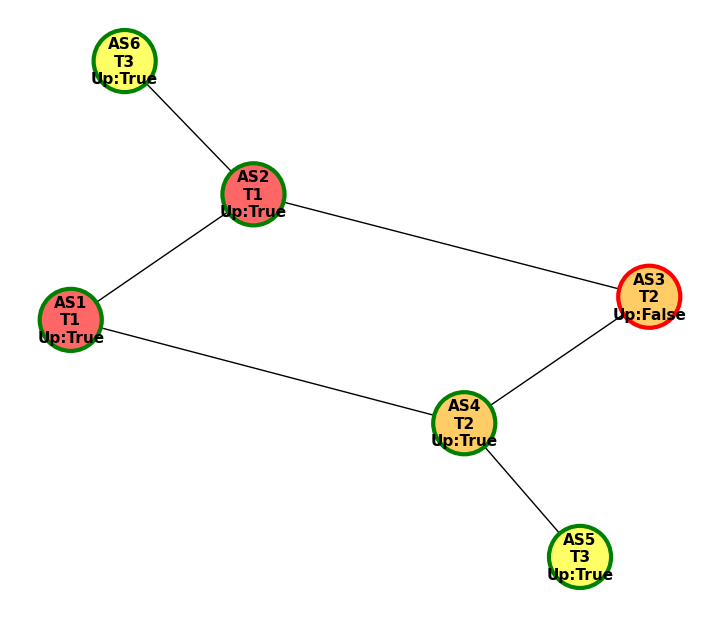

In [ ]:
import json, networkx as nx, matplotlib.pyplot as plt

cfg = json.load(open("small_config.json"))
G = nx.Graph()

# Add nodes with attributes
for a in cfg["all_as"]:
    G.add_node(a["number"], tier=a["tier"], upgraded=a.get("upgraded", False))

# Add edges
for src, dsts in cfg["connections"].items():
    for dst in dsts:
        G.add_edge(int(src), dst)

# Colors
tier_colors = {1:"#ff6666", 2:"#ffcc66", 3:"#ffff66"}
fill = [tier_colors[G.nodes[n]["tier"]] for n in G.nodes()]
border = ["green" if G.nodes[n]["upgraded"] else "red" for n in G.nodes()]

# Draw
pos = nx.spring_layout(G, seed=3)
plt.figure(figsize=(7,6))
nx.draw(G,pos,node_size=2000,node_color=fill,edgecolors=border,linewidths=3,with_labels=False)

labels = {n: f"AS{n}\nT{G.nodes[n]['tier']}\nUp:{G.nodes[n]['upgraded']}" for n in G.nodes()}
nx.draw_networkx_labels(G,pos,labels,font_size=11,font_weight="bold")

plt.axis("off")
plt.show()



In [ ]:
from fabrictestbed_extensions.fablib.fablib import FablibManager as fablib_manager
import re

fab = fablib_manager()
slice = fab.get_slice("NCSA-topo-new")

for node in slice.get_nodes():
    out, err = node.execute("ip -6 addr", quiet=True)
    mg = re.search(r'(\w+):.*2001:400:', out)
    mg = mg.group(1) if mg else None
    for iface in node.get_interfaces():
        os_if = iface.get_os_interface()
        if os_if == mg: continue
        node.execute(f"sudo ip link set {os_if} down")
        node.execute(f"sudo ip link set {os_if} up")
    node.execute(f"sudo ip link set lo down")
    node.execute(f"sudo ip link set lo up")

print("done")

In [ ]:
nodes = slice.get_nodes()

In [ ]:
node_vars = {}

In [ ]:
for n in nodes:
    pyname = n.get_name().replace("-", "_")
    node_vars[pyname] = n
    globals()[pyname] = n

In [ ]:
node_vars

### Newnode1 -- Newnode2

In [ ]:
# =========================================================================
# Manual route for NEW m_to_f pair (AS3-internal only):
#   newnode1 -> r-3-4 -> r-core2-3 -> r-3-2 -> newnode2
#
# Forces traffic through r-core2-3 (AS3 core2). New IPv6 prefixes are chosen
# different from every existing pair (m_to_f uses fd10:43:100 / fd10:23:100;
# s_to_m, f_to_g, eps_to_k use other prefixes — no collisions).
# Idempotent: re-running just replaces addresses and routes in place.
# =========================================================================

# ---------- 1. node handles ----------
newnode1  = slice.get_node(name="newnode1")
newnode2  = slice.get_node(name="newnode2")
r_3_4     = slice.get_node(name="r-3-4")
r_core2_3 = slice.get_node(name="r-core2-3")
r_3_2     = slice.get_node(name="r-3-2")

# ---------- 2. NEW addressing plan ----------
N1_PREFIX = "fd10:34:200"   # newnode1 ↔ r-3-4 link
N2_PREFIX = "fd10:32:200"   # newnode2 ↔ r-3-2 link
NEWNODE1_ADDR = f"{N1_PREFIX}::2"
R34_N1_ADDR   = f"{N1_PREFIX}::1"
NEWNODE2_ADDR = f"{N2_PREFIX}::2"
R32_N2_ADDR   = f"{N2_PREFIX}::1"

# Existing AS3 internal next-hops (already assigned by earlier topology cells):
NH_R34_TO_C23 = "fd00:3:204::2"   # r-3-4   → r-core2-3
NH_C23_TO_R34 = "fd00:3:204::1"   # r-core2-3 → r-3-4
NH_R32_TO_C23 = "fd00:3:202::2"   # r-3-2   → r-core2-3
NH_C23_TO_R32 = "fd00:3:202::1"   # r-core2-3 → r-3-2

# ---------- 3. NIC discovery via shared L2 + MAC matching ----------
def find_link(node_a, node_b):
    nets_a, nets_b = {}, {}
    for nobj, sink in [(node_a, nets_a), (node_b, nets_b)]:
        for iface in nobj.get_interfaces():
            try:
                net = iface.get_network()
                if net:
                    sink[net.get_name()] = (iface.get_mac() or "").lower()
            except Exception:
                continue
    common = set(nets_a) & set(nets_b)
    if not common:
        return None, None, None
    net_name = sorted(common)[0]
    def mac_to_nic(nobj, mac):
        out, _ = nobj.execute(
            "for n in $(ls /sys/class/net); do "
            "  echo $n $(cat /sys/class/net/$n/address 2>/dev/null); "
            "done", quiet=True)
        for line in (out or "").strip().splitlines():
            parts = line.split()
            if len(parts) == 2 and parts[1].lower() == mac:
                return parts[0]
        return None
    return (mac_to_nic(node_a, nets_a[net_name]),
            mac_to_nic(node_b, nets_b[net_name]),
            net_name)

print("Discovering NICs...")
NIC_N1_TO_R34,  NIC_R34_TO_N1,  NET_N1   = find_link(newnode1, r_3_4)
NIC_R34_TO_C23, NIC_C23_TO_R34, NET_34_C = find_link(r_3_4,    r_core2_3)
NIC_R32_TO_C23, NIC_C23_TO_R32, NET_32_C = find_link(r_3_2,    r_core2_3)
NIC_N2_TO_R32,  NIC_R32_TO_N2,  NET_N2   = find_link(newnode2, r_3_2)

discoveries = [
    ("newnode1 -> r-3-4",   NIC_N1_TO_R34,  NET_N1),
    ("r-3-4    -> newnode1", NIC_R34_TO_N1, NET_N1),
    ("r-3-4    -> core2-3", NIC_R34_TO_C23, NET_34_C),
    ("core2-3  -> r-3-4",   NIC_C23_TO_R34, NET_34_C),
    ("r-3-2    -> core2-3", NIC_R32_TO_C23, NET_32_C),
    ("core2-3  -> r-3-2",   NIC_C23_TO_R32, NET_32_C),
    ("r-3-2    -> newnode2", NIC_R32_TO_N2, NET_N2),
    ("newnode2 -> r-3-2",   NIC_N2_TO_R32,  NET_N2),
]
for label, nic, net in discoveries:
    print(f"  {label:<23} : {nic}    (net: {net})")

missing = [label for label, nic, _ in discoveries if nic is None]
if missing:
    raise RuntimeError(f"Could not resolve NICs: {missing}. "
                       "Check newnode1/newnode2 are attached to r-3-4/r-3-2 in the slice.")

# ---------- 4. assign IPv6 addresses on the new links ----------
print("\n[1/3] Assigning IPv6 addresses on the new links...")
addr_assignments = [
    (newnode1, NIC_N1_TO_R34, NEWNODE1_ADDR, "newnode1"),
    (r_3_4,    NIC_R34_TO_N1, R34_N1_ADDR,   "r-3-4 (newnode1 side)"),
    (newnode2, NIC_N2_TO_R32, NEWNODE2_ADDR, "newnode2"),
    (r_3_2,    NIC_R32_TO_N2, R32_N2_ADDR,   "r-3-2 (newnode2 side)"),
]
for nobj, nic, addr, label in addr_assignments:
    nobj.execute(
        f"sudo ip -6 addr replace {addr}/64 dev {nic}; sudo ip link set {nic} up",
        quiet=True
    )
    print(f"  {label:<28} : {addr}/64 on {nic}")

# ---------- 5. ensure IPv6 forwarding on routers ----------
print("\n[2/3] Ensuring IPv6 forwarding on routers...")
for r in (r_3_4, r_core2_3, r_3_2):
    r.execute("sudo sysctl -w net.ipv6.conf.all.forwarding=1 >/dev/null 2>&1",
              quiet=True)

# ---------- 6. install static routes ----------
print("\n[3/3] Installing static routes...")
forward_routes = [
    (newnode1,  f"{N2_PREFIX}::/64", R34_N1_ADDR,   NIC_N1_TO_R34,  "newnode1"),
    (r_3_4,     f"{N2_PREFIX}::/64", NH_R34_TO_C23, NIC_R34_TO_C23, "r-3-4"),
    (r_core2_3, f"{N2_PREFIX}::/64", NH_C23_TO_R32, NIC_C23_TO_R32, "core2-3"),
    # r-3-2: directly connected to newnode2's subnet, no route needed
]
reverse_routes = [
    (newnode2,  f"{N1_PREFIX}::/64", R32_N2_ADDR,   NIC_N2_TO_R32,  "newnode2"),
    (r_3_2,     f"{N1_PREFIX}::/64", NH_R32_TO_C23, NIC_R32_TO_C23, "r-3-2"),
    (r_core2_3, f"{N1_PREFIX}::/64", NH_C23_TO_R34, NIC_C23_TO_R34, "core2-3"),
    # r-3-4: directly connected
]
for nobj, dst, via, dev, label in forward_routes + reverse_routes:
    nobj.execute(
        f"sudo ip -6 route replace {dst} via {via} dev {dev}",
        quiet=True
    )
    print(f"  {label:<10} : {dst}  via {via} dev {dev}")

# ---------- 7. quick verification ----------
print("\nPing test (newnode1 -> newnode2):")
out, _ = newnode1.execute(f"ping6 -c 3 -W 2 {NEWNODE2_ADDR}", quiet=True)
print(out)

print("\nTraceroute (newnode1 -> newnode2) — MUST include r-core2-3:")
out, _ = newnode1.execute(f"traceroute6 -n {NEWNODE2_ADDR}", quiet=True)
print(out)

print(f"\nNEWNODE1_ADDR = {NEWNODE1_ADDR}")
print(f"NEWNODE2_ADDR = {NEWNODE2_ADDR}")
print(f"Use NEWNODE2_ADDR as sink_address when updating BACKGROUND_PAIRS['m_to_f'].")

### Nodes <--> Nodem

In [ ]:
# =========================================================================
# Manual route: node_s -> r-4-5 -> r-core2-4 -> r-4-3 -> node_m
#
# Forces traffic through r-core2-4 explicitly. Idempotent (uses
# `ip -6 addr replace` and `ip -6 route replace`).
# =========================================================================
import json

# ---------- 1. node handles ----------
node_s    = slice.get_node(name="node_s")
r_4_5     = slice.get_node(name="r-4-5")
r_core2_4 = slice.get_node(name="r-core2-4")
r_4_3     = slice.get_node(name="r-4-3")
node_m    = slice.get_node(name="node_m")

# ---------- 2. addressing plan ----------
# Endpoint /64s
S_PREFIX = "fd10:45:100"   # node_s <-> r-4-5
M_PREFIX = "fd10:43:100"   # r-4-3 <-> node_m

NODE_S_ADDR  = f"{S_PREFIX}::2"   # node_s
R45_S_ADDR   = f"{S_PREFIX}::1"   # r-4-5 side of node_s link
R43_M_ADDR   = f"{M_PREFIX}::1"   # r-4-3 side of node_m link
NODE_M_ADDR  = f"{M_PREFIX}::2"   # node_m

# Inter-router next-hops (already assigned by topology):
# net-4-5-core2 :  r-4-5  = fd00:4:205::1   r-core2-4 = fd00:4:205::2
# net-4-3-core2 :  r-4-3  = fd00:4:203::1   r-core2-4 = fd00:4:203::2
NH_R45_TO_C24 = "fd00:4:205::2"
NH_C24_TO_R45 = "fd00:4:205::1"
NH_R43_TO_C24 = "fd00:4:203::2"
NH_C24_TO_R43 = "fd00:4:203::1"

# Network names on the slice
NET_NODE_S    = "node_s_network"
NET_NODE_M    = "node_m_network"
NET_45_CORE2  = "net-4-5-core2"
NET_43_CORE2  = "net-4-3-core2"

# ---------- 3. NIC discovery via MAC matching ----------
def find_nic(node_obj, network_name):
    """Look up the OS NIC on node_obj attached to the given FABRIC L2 network,
       using MAC matching (reboot-safe; doesn't trust fablib's NIC cache)."""
    target_mac = None
    for iface in node_obj.get_interfaces():
        try:
            net = iface.get_network()
            if net and net.get_name() == network_name:
                target_mac = (iface.get_mac() or "").lower()
                break
        except Exception:
            continue
    if not target_mac:
        return None
    out, _ = node_obj.execute(
        "for n in $(ls /sys/class/net); do "
        "  echo $n $(cat /sys/class/net/$n/address 2>/dev/null); "
        "done", quiet=True)
    for line in (out or "").strip().splitlines():
        parts = line.split()
        if len(parts) == 2 and parts[1].lower() == target_mac:
            return parts[0]
    return None

NIC_NS_TO_R45  = find_nic(node_s,    NET_NODE_S)
NIC_R45_TO_NS  = find_nic(r_4_5,     NET_NODE_S)
NIC_R45_TO_C24 = find_nic(r_4_5,     NET_45_CORE2)
NIC_C24_TO_R45 = find_nic(r_core2_4, NET_45_CORE2)
NIC_C24_TO_R43 = find_nic(r_core2_4, NET_43_CORE2)
NIC_R43_TO_C24 = find_nic(r_4_3,     NET_43_CORE2)
NIC_R43_TO_NM  = find_nic(r_4_3,     NET_NODE_M)
NIC_NM_TO_R43  = find_nic(node_m,    NET_NODE_M)

print("Discovered NICs:")
for label, nic in [
    ("node_s -> r-4-5",      NIC_NS_TO_R45),
    ("r-4-5  -> node_s",     NIC_R45_TO_NS),
    ("r-4-5  -> r-core2-4",  NIC_R45_TO_C24),
    ("core2-4 -> r-4-5",     NIC_C24_TO_R45),
    ("core2-4 -> r-4-3",     NIC_C24_TO_R43),
    ("r-4-3  -> r-core2-4",  NIC_R43_TO_C24),
    ("r-4-3  -> node_m",     NIC_R43_TO_NM),
    ("node_m -> r-4-3",      NIC_NM_TO_R43),
]:
    print(f"  {label:<24} : {nic}")

# Bail out early if any are missing
missing = [name for name, nic in [
    ("node_s/NS-net",  NIC_NS_TO_R45),
    ("r-4-5/NS-net",   NIC_R45_TO_NS),
    ("r-4-5/c24",      NIC_R45_TO_C24),
    ("c24/r-4-5",      NIC_C24_TO_R45),
    ("c24/r-4-3",      NIC_C24_TO_R43),
    ("r-4-3/c24",      NIC_R43_TO_C24),
    ("r-4-3/NM-net",   NIC_R43_TO_NM),
    ("node_m/NM-net",  NIC_NM_TO_R43),
] if nic is None]
if missing:
    raise RuntimeError(f"Could not resolve NICs: {missing}. "
                       f"Did you run cell 43 (build ifmaps) after adding node_s/node_m?")

# ---------- 4. assign IPv6 on the four endpoint-link sides ----------
print("\n[1/2] Assigning IPv6 addresses (idempotent)...")
for node_obj, nic, addr, label in [
    (node_s, NIC_NS_TO_R45, NODE_S_ADDR, "node_s"),
    (r_4_5,  NIC_R45_TO_NS, R45_S_ADDR,  "r-4-5  (node_s side)"),
    (r_4_3,  NIC_R43_TO_NM, R43_M_ADDR,  "r-4-3  (node_m side)"),
    (node_m, NIC_NM_TO_R43, NODE_M_ADDR, "node_m"),
]:
    node_obj.execute(f"sudo ip -6 addr replace {addr}/64 dev {nic}", quiet=True)
    print(f"  {label:<22} {nic}: {addr}/64")

# ---------- 5. install static routes ----------
print("\n[2/2] Installing static routes...")

# Forward (toward node_m: dst = fd10:43:100::/64)
forward_routes = [
    (node_s,    f"{M_PREFIX}::/64", R45_S_ADDR,    NIC_NS_TO_R45,  "node_s"),
    (r_4_5,     f"{M_PREFIX}::/64", NH_R45_TO_C24, NIC_R45_TO_C24, "r-4-5"),
    (r_core2_4, f"{M_PREFIX}::/64", NH_C24_TO_R43, NIC_C24_TO_R43, "core2-4"),
    # r-4-3: NODE_M_NET is directly connected — no static needed
]

# Reverse (toward node_s: dst = fd10:45:100::/64)
reverse_routes = [
    (node_m,    f"{S_PREFIX}::/64", R43_M_ADDR,    NIC_NM_TO_R43,  "node_m"),
    (r_4_3,     f"{S_PREFIX}::/64", NH_R43_TO_C24, NIC_R43_TO_C24, "r-4-3"),
    (r_core2_4, f"{S_PREFIX}::/64", NH_C24_TO_R45, NIC_C24_TO_R45, "core2-4"),
    # r-4-5: NODE_S_NET is directly connected — no static needed
]

for node_obj, dst, via, dev, label in forward_routes + reverse_routes:
    node_obj.execute(
        f"sudo ip -6 route replace {dst} via {via} dev {dev}",
        quiet=True
    )
    print(f"  {label:<10} : {dst}  via {via} dev {dev}")

# Make sure forwarding is on at the routers (should already be, but be safe)
for r in (r_4_5, r_core2_4, r_4_3):
    r.execute("sudo sysctl -w net.ipv6.conf.all.forwarding=1 >/dev/null 2>&1", quiet=True)

# ---------- 6. quick verification ----------
print("\nQuick ping test...")
out, _ = node_s.execute(f"ping6 -c 3 -W 2 {NODE_M_ADDR}", quiet=True)
print(out)

### Nodem <--> Nodef

In [ ]:
# =========================================================================
# Manual route: node_m -> r-4-3 -> r-3-4 -> r-core2-3 -> r-3-2 -> r-2-3 -> node_f
#
# Forces traffic through r-core2-3 (AS3 core2). Idempotent.
# Reuses addresses already assigned:
#   node_m has fd10:43:100::2  (set by s_to_m cell)
#   r-4-3  has fd10:43:100::1  (set by s_to_m cell)
#   node_f has fd10:23:100::2  (set by f_to_g cell)
#   r-2-3  has fd10:23:100::1  (set by f_to_g cell)
# =========================================================================
import json

# ---------- 1. node handles ----------
node_m    = slice.get_node(name="node_m")
r_4_3     = slice.get_node(name="r-4-3")
r_3_4     = slice.get_node(name="r-3-4")
r_core2_3 = slice.get_node(name="r-core2-3")
r_3_2     = slice.get_node(name="r-3-2")
r_2_3     = slice.get_node(name="r-2-3")
node_f    = slice.get_node(name="node_f")

# ---------- 2. addressing plan (no new addresses needed) ----------
M_PREFIX = "fd10:43:100"   # node_m side
F_PREFIX = "fd10:23:100"   # node_f side
NODE_M_ADDR  = f"{M_PREFIX}::2"
R43_M_ADDR   = f"{M_PREFIX}::1"
NODE_F_ADDR  = f"{F_PREFIX}::2"
R23_F_ADDR   = f"{F_PREFIX}::1"

# Inter-router next-hops (assigned by topology):
#   AS3-AS4 link    fd00:3:4::/64        r-3-4=::1   r-4-3=::2
#   AS3 core2 r-3-4 fd00:3:204::/64      r-3-4=::1   r-core2-3=::2
#   AS3 core2 r-3-2 fd00:3:202::/64      r-3-2=::1   r-core2-3=::2
#   AS2-AS3 link    fd00:2:3::/64        r-2-3=::1   r-3-2=::2
NH_R43_TO_R34 = "fd00:3:4::1"
NH_R34_TO_R43 = "fd00:3:4::2"
NH_R34_TO_C23 = "fd00:3:204::2"
NH_C23_TO_R34 = "fd00:3:204::1"
NH_R32_TO_C23 = "fd00:3:202::2"
NH_C23_TO_R32 = "fd00:3:202::1"
NH_R32_TO_R23 = "fd00:2:3::1"
NH_R23_TO_R32 = "fd00:2:3::2"

# ---------- 3. NIC discovery via shared L2 network + MAC matching ----------
def find_link(node_a, node_b):
    """Find the L2 network shared by node_a and node_b → (nic_a, nic_b, net_name)."""
    nets_a, nets_b = {}, {}
    for nobj, sink in [(node_a, nets_a), (node_b, nets_b)]:
        for iface in nobj.get_interfaces():
            try:
                net = iface.get_network()
                if net:
                    sink[net.get_name()] = (iface.get_mac() or "").lower()
            except Exception:
                continue
    common = set(nets_a) & set(nets_b)
    if not common:
        return None, None, None
    net_name = sorted(common)[0]

    def mac_to_nic(nobj, mac):
        out, _ = nobj.execute(
            "for n in $(ls /sys/class/net); do "
            "  echo $n $(cat /sys/class/net/$n/address 2>/dev/null); "
            "done", quiet=True)
        for line in (out or "").strip().splitlines():
            parts = line.split()
            if len(parts) == 2 and parts[1].lower() == mac:
                return parts[0]
        return None

    return mac_to_nic(node_a, nets_a[net_name]), mac_to_nic(node_b, nets_b[net_name]), net_name

print("Discovering NICs (MAC matching)...")
NIC_NM_TO_R43,  NIC_R43_TO_NM,  NET_NM    = find_link(node_m,    r_4_3)
NIC_R43_TO_R34, NIC_R34_TO_R43, NET_43_34 = find_link(r_4_3,     r_3_4)
NIC_R34_TO_C23, NIC_C23_TO_R34, NET_34_C  = find_link(r_3_4,     r_core2_3)
NIC_R32_TO_C23, NIC_C23_TO_R32, NET_32_C  = find_link(r_3_2,     r_core2_3)
NIC_R32_TO_R23, NIC_R23_TO_R32, NET_32_23 = find_link(r_3_2,     r_2_3)
NIC_R23_TO_NF,  NIC_NF_TO_R23,  NET_NF    = find_link(r_2_3,     node_f)

discoveries = [
    ("node_m -> r-4-3",    NIC_NM_TO_R43,  NET_NM),
    ("r-4-3  -> node_m",   NIC_R43_TO_NM,  NET_NM),
    ("r-4-3  -> r-3-4",    NIC_R43_TO_R34, NET_43_34),
    ("r-3-4  -> r-4-3",    NIC_R34_TO_R43, NET_43_34),
    ("r-3-4  -> core2-3",  NIC_R34_TO_C23, NET_34_C),
    ("core2-3 -> r-3-4",   NIC_C23_TO_R34, NET_34_C),
    ("r-3-2  -> core2-3",  NIC_R32_TO_C23, NET_32_C),
    ("core2-3 -> r-3-2",   NIC_C23_TO_R32, NET_32_C),
    ("r-3-2  -> r-2-3",    NIC_R32_TO_R23, NET_32_23),
    ("r-2-3  -> r-3-2",    NIC_R23_TO_R32, NET_32_23),
    ("r-2-3  -> node_f",   NIC_R23_TO_NF,  NET_NF),
    ("node_f -> r-2-3",    NIC_NF_TO_R23,  NET_NF),
]
for label, nic, net in discoveries:
    print(f"  {label:<22} : {nic}    (net: {net})")

missing = [label for label, nic, _ in discoveries if nic is None]
if missing:
    raise RuntimeError(f"Could not resolve NICs: {missing}. "
                       "Did you run cell 43 (build ifmaps) after adding node_m/node_f?")

# ---------- 4. ensure forwarding is on at all routers ----------
print("\n[1/2] Ensuring IPv6 forwarding is enabled on routers...")
for r in (r_4_3, r_3_4, r_core2_3, r_3_2, r_2_3):
    r.execute("sudo sysctl -w net.ipv6.conf.all.forwarding=1 >/dev/null 2>&1", quiet=True)

# ---------- 5. install static routes ----------
print("\n[2/2] Installing static routes...")

# Forward (toward node_f, dst = fd10:23:100::/64)
forward_routes = [
    (node_m,    f"{F_PREFIX}::/64", R43_M_ADDR,    NIC_NM_TO_R43,  "node_m"),
    (r_4_3,     f"{F_PREFIX}::/64", NH_R43_TO_R34, NIC_R43_TO_R34, "r-4-3"),
    (r_3_4,     f"{F_PREFIX}::/64", NH_R34_TO_C23, NIC_R34_TO_C23, "r-3-4"),
    (r_core2_3, f"{F_PREFIX}::/64", NH_C23_TO_R32, NIC_C23_TO_R32, "core2-3"),
    (r_3_2,     f"{F_PREFIX}::/64", NH_R32_TO_R23, NIC_R32_TO_R23, "r-3-2"),
    # r-2-3: directly connected
]

# Reverse (toward node_m, dst = fd10:43:100::/64)
reverse_routes = [
    (node_f,    f"{M_PREFIX}::/64", R23_F_ADDR,    NIC_NF_TO_R23,  "node_f"),
    (r_2_3,     f"{M_PREFIX}::/64", NH_R23_TO_R32, NIC_R23_TO_R32, "r-2-3"),
    (r_3_2,     f"{M_PREFIX}::/64", NH_R32_TO_C23, NIC_R32_TO_C23, "r-3-2"),
    (r_core2_3, f"{M_PREFIX}::/64", NH_C23_TO_R34, NIC_C23_TO_R34, "core2-3"),
    (r_3_4,     f"{M_PREFIX}::/64", NH_R34_TO_R43, NIC_R34_TO_R43, "r-3-4"),
    # r-4-3: directly connected
]

for node_obj, dst, via, dev, label in forward_routes + reverse_routes:
    node_obj.execute(
        f"sudo ip -6 route replace {dst} via {via} dev {dev}",
        quiet=True
    )
    print(f"  {label:<10} : {dst}  via {via} dev {dev}")

# ---------- 6. quick verification ----------
print("\nQuick ping test (node_m -> node_f)...")
out, _ = node_m.execute(f"ping6 -c 3 -W 2 {NODE_F_ADDR}", quiet=True)
print(out)

### Nodef <--> Nodeg

In [ ]:
# Fill these with the real endpoint-facing interfaces.
# node_f is attached to r-2-3
# node_g is attached to r-6-2

IF_NODE_F   = "enp7s0"                         # node_f interface toward r-2-3
IF_R23_HOST = "enp10s0"                        # r-2-3 interface toward node_f

IF_NODE_G   = "enp7s0"                         # node_g interface toward r-6-2
IF_R62_HOST = "enp11s0"   # do NOT keep enp11s0 unless it really exists on r-6-2


# -------------------------------------------------
# Correct path:
# node_f <-> r-2-3 : fd10:23:100::/64
# r-6-2 <-> node_g : fd10:62:100::/64
# -------------------------------------------------

# -------------------------
# Cleanup wrong endpoint config from previous run
# -------------------------

# node_g previously got the wrong left-side subnet

# node_g.execute(f"sudo ip -6 addr del fd10:23:100::2/64 dev {IF_NODE_G} || true")
# node_g.execute(f"sudo ip -6 route del fd10:62:100::/64 via fd10:23:100::1 dev {IF_NODE_G} || true")
# node_g.execute(f"sudo ip -6 route del fd10:62:100::2/128 via fd10:23:100::1 dev {IF_NODE_G} || true")

# # node_f previously got the wrong right-side subnet

# node_f.execute(f"sudo ip -6 addr del fd10:62:100::2/64 dev {IF_NODE_F} || true")
# node_f.execute(f"sudo ip -6 route del fd10:23:100::/64 via fd10:62:100::1 dev {IF_NODE_F} || true")
# node_f.execute(f"sudo ip -6 route del fd10:23:100::2/128 via fd10:62:100::1 dev {IF_NODE_F} || true")

# # optional neighbor cleanup
# node_g.execute(f"sudo ip -6 neigh flush dev {IF_NODE_G} || true")
# node_f.execute(f"sudo ip -6 neigh flush dev {IF_NODE_F} || true")


# -------------------------
# node_f  (LEFT endpoint)
# -------------------------
node_f.execute(f"sudo ip link set {IF_NODE_F} up")
node_f.execute(f"sudo ip -6 addr add fd10:23:100::2/64 dev {IF_NODE_F}")

# route toward node_g side
node_f.execute(f"sudo ip -6 route replace fd10:62:100::/64 via fd10:23:100::1 dev {IF_NODE_F}")
node_f.execute(f"sudo ip -6 route replace fd10:62:100::2/128 via fd10:23:100::1 dev {IF_NODE_F}")


# -------------------------
# r-2-3  (LEFT edge router)
# existing inner hop to r-core2-2:
#   enp8s0 = fd00:2:203::1
# -------------------------
r_2_3.execute("sudo sysctl -w net.ipv6.conf.all.forwarding=1")
r_2_3.execute(f"sudo ip link set {IF_R23_HOST} up")

# cleanup in case old addr already exists on a different iface
r_2_3.execute(f"sudo ip -6 addr del fd10:23:100::1/64 dev {IF_R23_HOST} || true")
r_2_3.execute(f"sudo ip -6 addr add fd10:23:100::1/64 dev {IF_R23_HOST}")

# route toward RIGHT endpoint subnet through core
r_2_3.execute("sudo ip -6 route replace fd10:62:100::/64 via fd00:2:203::2 dev enp11s0")
r_2_3.execute("sudo ip -6 route replace fd10:62:100::2/128 via fd00:2:203::2 dev enp11s0")


# -------------------------
# r-core2-2
# left  side to r-2-3 : enp8s0 = fd00:2:203::2
# right side to r-2-6 : enp7s0 = fd00:2:206::2
# -------------------------
r_core2_2.execute("sudo sysctl -w net.ipv6.conf.all.forwarding=1")

# toward LEFT endpoint subnet (node_f side)
r_core2_2.execute("sudo ip -6 route replace fd10:23:100::/64 via fd00:2:203::1 dev enp8s0")
r_core2_2.execute("sudo ip -6 route replace fd10:23:100::2/128 via fd00:2:203::1 dev enp8s0")

# toward RIGHT endpoint subnet (node_g side)
r_core2_2.execute("sudo ip -6 route replace fd10:62:100::/64 via fd00:2:206::1 dev enp7s0")
r_core2_2.execute("sudo ip -6 route replace fd10:62:100::2/128 via fd00:2:206::1 dev enp7s0")


# -------------------------
# r-2-6
# left  side to r-core2-2 : enp9s0 = fd00:2:206::1
# right side to r-6-2     : enp7s0 = fd00:2:6::1
# -------------------------
r_2_6.execute("sudo sysctl -w net.ipv6.conf.all.forwarding=1")

# toward LEFT endpoint subnet (node_f side)
r_2_6.execute("sudo ip -6 route replace fd10:23:100::/64 via fd00:2:206::2 dev enp9s0")
r_2_6.execute("sudo ip -6 route replace fd10:23:100::2/128 via fd00:2:206::2 dev enp9s0")

# toward RIGHT endpoint subnet (node_g side)
r_2_6.execute("sudo ip -6 route replace fd10:62:100::/64 via fd00:2:6::2 dev enp7s0")
r_2_6.execute("sudo ip -6 route replace fd10:62:100::2/128 via fd00:2:6::2 dev enp7s0")


# -------------------------
# r-6-2  (RIGHT edge router)
# existing inner hop to r-2-6:
#   enp7s0 = fd00:2:6::2
# -------------------------
r_6_2.execute("sudo sysctl -w net.ipv6.conf.all.forwarding=1")
r_6_2.execute(f"sudo ip link set {IF_R62_HOST} up")

# cleanup/add right endpoint subnet
r_6_2.execute(f"sudo ip -6 addr del fd10:62:100::1/64 dev {IF_R62_HOST} || true")
r_6_2.execute(f"sudo ip -6 addr add fd10:62:100::1/64 dev {IF_R62_HOST}")

# route toward LEFT endpoint subnet through r-2-6
r_6_2.execute("sudo ip -6 route replace fd10:23:100::/64 via fd00:2:6::1 dev enp7s0")
r_6_2.execute("sudo ip -6 route replace fd10:23:100::2/128 via fd00:2:6::1 dev enp7s0")


# -------------------------
# node_g  (RIGHT endpoint)
# -------------------------
node_g.execute(f"sudo ip link set {IF_NODE_G} up")
node_g.execute(f"sudo ip -6 addr add fd10:62:100::2/64 dev {IF_NODE_G}")

# route toward node_f side
node_g.execute(f"sudo ip -6 route replace fd10:23:100::/64 via fd10:62:100::1 dev {IF_NODE_G}")
node_g.execute(f"sudo ip -6 route replace fd10:23:100::2/128 via fd10:62:100::1 dev {IF_NODE_G}")

### endpoint <--> Nodek

In [ ]:
e_2_5       = slice.get_node(name="e-2-5")
r_access_5  = slice.get_node(name="r-access-5")
r_core1_5   = slice.get_node(name="r-core1-5")
nodek       = slice.get_node(name="node_k")

In [ ]:
print("Check node name")
print(nodek.get_name())

print("Check no fd10:5:100 conflict")
r_core1_5.execute("ip -6 addr show | grep fd10:5:100 || true")
nodek.execute("ip -6 addr show | grep fd10:5:100 || true")
r_core1_5.execute("ip -6 route show | grep fd10:5:100 || true")
r_access_5.execute("ip -6 route show | grep fd10:5:100 || true")
e_2_5.execute("ip -6 route show | grep fd10:5:100 || true")

print("Check final-hop physical link")
r_core1_5.execute("ip -6 neigh show dev enp9s0")

In [ ]:
# =================================================
# SINGLE CELL: e-2-5 -> r-access-5 -> r-core1-5 -> node_k
#
# Important:
# - Do NOT change existing fd00 addresses on e-2-5, r-access-5, or r-core1-5.
# - Only add a new fd10 subnet on the final r-core1-5 <-> node_k link.
# - Only add /128 host routes for the new node_k endpoint address and return path.
# =================================================

# -------------------------------------------------
# Get FABRIC node objects
# -------------------------------------------------
e_2_5       = slice.get_node(name="e-2-5")
r_access_5  = slice.get_node(name="r-access-5")
r_core1_5   = slice.get_node(name="r-core1-5")
nodek       = slice.get_node(name="node_k")


# -------------------------------------------------
# Interface mapping
# -------------------------------------------------
IF_E25_ACCESS      = "enp7s0"   # e-2-5 toward r-access-5
IF_ACCESS_CORE     = "enp7s0"   # r-access-5 toward r-core1-5
IF_CORE_ACCESS     = "enp7s0"   # r-core1-5 toward r-access-5

IF_CORE_NODEK      = "enp9s0"   # r-core1-5 toward node_k
IF_NODEK_CORE      = "enp7s0"   # node_k toward r-core1-5


# -------------------------------------------------
# Existing addresses: DO NOT assign/replace these
# -------------------------------------------------
E25_ADDR           = "fd00:5::4"
ACCESS_TO_E25      = "fd00:5::1"

ACCESS_TO_CORE     = "fd00:5:250::1"
CORE_TO_ACCESS     = "fd00:5:250::2"


# -------------------------------------------------
# New experiment-only final-hop addresses
# -------------------------------------------------
CORE_TO_NODEK      = "fd10:5:100::1"
NODEK_ADDR         = "fd10:5:100::2"


# =================================================
# Cleanup only previous experiment-specific config
# =================================================

# Remove old fd00:5:900 experiment routes/addresses if they exist
# e_2_5.execute(f"sudo ip -6 route del fd00:5:900::/64 via {ACCESS_TO_E25} dev {IF_E25_ACCESS} || true")
# e_2_5.execute(f"sudo ip -6 route del fd00:5:900::2/128 via {ACCESS_TO_E25} dev {IF_E25_ACCESS} || true")

# r_access_5.execute(f"sudo ip -6 route del fd00:5:900::/64 via {CORE_TO_ACCESS} dev {IF_ACCESS_CORE} || true")
# r_access_5.execute(f"sudo ip -6 route del fd00:5:900::2/128 via {CORE_TO_ACCESS} dev {IF_ACCESS_CORE} || true")

# r_core1_5.execute(f"sudo ip -6 route del {E25_ADDR}/128 via {ACCESS_TO_CORE} dev {IF_CORE_ACCESS} || true")
# r_core1_5.execute(f"sudo ip -6 addr del fd00:5:900::1/64 dev {IF_CORE_NODEK} || true")

# nodek.execute(f"sudo ip -6 route del fd00:5::/64 via fd00:5:900::1 dev {IF_NODEK_CORE} || true")
# nodek.execute(f"sudo ip -6 route del fd00:5::4/128 via fd00:5:900::1 dev {IF_NODEK_CORE} || true")
# nodek.execute(f"sudo ip -6 route del fd00:5:250::/64 via fd00:5:900::1 dev {IF_NODEK_CORE} || true")
# nodek.execute(f"sudo ip -6 addr del fd00:5:900::2/64 dev {IF_NODEK_CORE} || true")


# Remove fd10:5:100 experiment config if rerunning this cell
# e_2_5.execute(f"sudo ip -6 route del {NODEK_ADDR}/128 via {ACCESS_TO_E25} dev {IF_E25_ACCESS} || true")

# r_access_5.execute(f"sudo ip -6 route del {NODEK_ADDR}/128 via {CORE_TO_ACCESS} dev {IF_ACCESS_CORE} || true")

# r_core1_5.execute(f"sudo ip -6 route del {E25_ADDR}/128 via {ACCESS_TO_CORE} dev {IF_CORE_ACCESS} || true")
# r_core1_5.execute(f"sudo ip -6 addr del {CORE_TO_NODEK}/64 dev {IF_CORE_NODEK} || true")

# nodek.execute(f"sudo ip -6 route del {E25_ADDR}/128 via {CORE_TO_NODEK} dev {IF_NODEK_CORE} || true")
# nodek.execute(f"sudo ip -6 addr del {NODEK_ADDR}/64 dev {IF_NODEK_CORE} || true")


# =================================================
# Setup
# =================================================

# -------------------------
# e-2-5
# Do NOT assign fd00:5::4 again.
# Only route to node_k's new fd10 host address.
# -------------------------
e_2_5.execute(f"sudo ip link set {IF_E25_ACCESS} up")
e_2_5.execute(f"sudo ip -6 route replace {NODEK_ADDR}/128 via {ACCESS_TO_E25} dev {IF_E25_ACCESS}")


# -------------------------
# r-access-5
# Do NOT assign fd00:5::1 or fd00:5:250::1 again.
# Only route to node_k through r-core1-5.
# -------------------------
#r_access_5.execute("sudo sysctl -w net.ipv6.conf.all.forwarding=1")
#r_access_5.execute("sudo sysctl -w net.ipv6.conf.default.forwarding=1")

r_access_5.execute(f"sudo ip link set {IF_ACCESS_CORE} up")
r_access_5.execute(f"sudo ip -6 route replace {NODEK_ADDR}/128 via {CORE_TO_ACCESS} dev {IF_ACCESS_CORE}")


# -------------------------
# r-core1-5
# Do NOT assign fd00:5:250::2 again.
# Only assign new fd10 address toward node_k.
# Add return route to e-2-5.
# -------------------------
#r_core1_5.execute("sudo sysctl -w net.ipv6.conf.all.forwarding=1")
#r_core1_5.execute("sudo sysctl -w net.ipv6.conf.default.forwarding=1")

r_core1_5.execute(f"sudo ip link set {IF_CORE_NODEK} up")
r_core1_5.execute(f"sudo ip -6 addr replace {CORE_TO_NODEK}/64 dev {IF_CORE_NODEK}")
r_core1_5.execute(f"sudo ip -6 route replace {E25_ADDR}/128 via {ACCESS_TO_CORE} dev {IF_CORE_ACCESS}")


# -------------------------
# node_k
# Only assign new fd10 endpoint address.
# Add return route to e-2-5.
# -------------------------
nodek.execute(f"sudo ip link set {IF_NODEK_CORE} up")
nodek.execute(f"sudo ip -6 addr replace {NODEK_ADDR}/64 dev {IF_NODEK_CORE}")
nodek.execute(f"sudo ip -6 route replace {E25_ADDR}/128 via {CORE_TO_NODEK} dev {IF_NODEK_CORE}")


# =================================================
# Verification
# =================================================

# print("Route checks")
# e_2_5.execute(f"ip -6 route get {NODEK_ADDR}")
# r_access_5.execute(f"ip -6 route get {NODEK_ADDR}")
# r_core1_5.execute(f"ip -6 route get {NODEK_ADDR}")
# r_core1_5.execute(f"ip -6 route get {E25_ADDR}")
# nodek.execute(f"ip -6 route get {E25_ADDR}")

# print("Hop-by-hop tests")
# r_core1_5.execute(f"ping -6 -c 3 -I {CORE_TO_NODEK} {NODEK_ADDR}")
# r_access_5.execute(f"ping -6 -c 3 -I {ACCESS_TO_CORE} {NODEK_ADDR}")

print("End-to-end tests")
e_2_5.execute(f"ping -6 -c 5 -I {E25_ADDR} {NODEK_ADDR}")
nodek.execute(f"ping -6 -c 5 -I {NODEK_ADDR} {E25_ADDR}")

# print("Traceroute: e-2-5 -> node_k")
# e_2_5.execute(f"traceroute -6 -s {E25_ADDR} {NODEK_ADDR} || true")

### node_s <--> node_p

In [ ]:

# -------------------------------------------------
# Get FABRIC node objects
# -------------------------------------------------

node_s      = slice.get_node(name="node_s")
r_4_5       = slice.get_node(name="r-4-5")
r_core1_4   = slice.get_node(name="r-core1-4")
r_4_1       = slice.get_node(name="r-4-1")
node_p      = slice.get_node(name="node_p")


# -------------------------------------------------
# Correct path:
#
# nodes -> r-4-5 -> r-core1-4 -> r-4-1 -> nodep
#
# Endpoint-facing subnets only:
#   nodes  <-> r-4-5 : fd10:45:100::/64
#   r-4-1  <-> nodep : fd10:41:100::/64
#
# Existing router-to-router links are NOT changed:
#   r-4-5     <-> r-core1-4 : fd00:4:105::/64
#   r-core1-4 <-> r-4-1     : fd00:4:101::/64
# -------------------------------------------------

IF_NODE_S_R45 = "enp7s0"     # nodes interface toward r-4-5
IF_R45_NODE_S = "enp10s0"    # r-4-5 interface toward nodes

IF_R45_CORE   = "enp9s0"     # r-4-5 interface toward r-core1-4
IF_CORE_R45   = "enp7s0"     # r-core1-4 interface toward r-4-5

IF_CORE_R41   = "enp8s0"     # r-core1-4 interface toward r-4-1
IF_R41_CORE   = "enp9s0"     # r-4-1 interface toward r-core1-4

IF_R41_NODE_P = "enp10s0"    # r-4-1 interface toward nodep
IF_NODE_P_R41 = "enp7s0"     # nodep interface toward r-4-1


# -------------------------------------------------
# Addresses
# -------------------------------------------------

NODE_S_ADDR = "fd10:45:100::2"
R45_TO_NODE_S = "fd10:45:100::1"

NODE_P_ADDR = "fd10:41:100::2"
R41_TO_NODE_P = "fd10:41:100::1"

# Existing internal next hops.
# Do NOT assign these; they already exist.
R45_TO_CORE = "fd00:4:105::1"
CORE_TO_R45 = "fd00:4:105::2"

CORE_TO_R41 = "fd00:4:101::2"
R41_TO_CORE = "fd00:4:101::1"


# -------------------------------------------------
# Cleanup only previous experiment configs
#
# This removes old fd10/fd00 experiment additions from earlier attempts.
# It does NOT remove existing fd00 dynamic routing entries.
# -------------------------------------------------

# # nodes cleanup
# node_s.execute(f"sudo ip -6 route del fd10:41:100::2/128 via {R45_TO_NODE_S} dev {IF_NODE_S_R45} || true")
# node_s.execute(f"sudo ip -6 route del fd10:41:100::/64 via {R45_TO_NODE_S} dev {IF_NODE_S_R45} || true")
# node_s.execute(f"sudo ip -6 route del fd10:9999:41:1::2/128 via fd10:9999:45:1::1 dev {IF_NODE_S_R45} || true")
# node_s.execute(f"sudo ip -6 addr del fd10:45:100::2/64 dev {IF_NODE_S_R45} || true")
# node_s.execute(f"sudo ip -6 addr del fd10:9999:45:1::2/64 dev {IF_NODE_S_R45} || true")
# node_s.execute(f"sudo ip -6 addr del fd00:4:900::2/64 dev {IF_NODE_S_R45} || true")


# # r-4-5 cleanup
# r_4_5.execute(f"sudo ip -6 route del fd10:41:100::2/128 via {CORE_TO_R45} dev {IF_R45_CORE} || true")
# r_4_5.execute(f"sudo ip -6 route del fd10:41:100::/64 via {CORE_TO_R45} dev {IF_R45_CORE} || true")
# r_4_5.execute(f"sudo ip -6 route del fd10:9999:41:1::2/128 via fd10:9999:45:2::2 dev {IF_R45_CORE} || true")
# r_4_5.execute(f"sudo ip -6 addr del fd10:45:100::1/64 dev {IF_R45_NODE_S} || true")
# r_4_5.execute(f"sudo ip -6 addr del fd10:9999:45:1::1/64 dev {IF_R45_NODE_S} || true")
# r_4_5.execute(f"sudo ip -6 addr del fd10:9999:45:2::1/64 dev {IF_R45_CORE} || true")
# r_4_5.execute(f"sudo ip -6 addr del fd00:4:900::1/64 dev {IF_R45_NODE_S} || true")


# # r-core1-4 cleanup
# r_core1_4.execute(f"sudo ip -6 route del fd10:45:100::2/128 via {R45_TO_CORE} dev {IF_CORE_R45} || true")
# r_core1_4.execute(f"sudo ip -6 route del fd10:41:100::2/128 via {R41_TO_CORE} dev {IF_CORE_R41} || true")
# r_core1_4.execute(f"sudo ip -6 route del fd10:45:100::/64 via {R45_TO_CORE} dev {IF_CORE_R45} || true")
# r_core1_4.execute(f"sudo ip -6 route del fd10:41:100::/64 via {R41_TO_CORE} dev {IF_CORE_R41} || true")
# r_core1_4.execute(f"sudo ip -6 route del fd10:9999:45:1::2/128 via fd10:9999:45:2::1 dev {IF_CORE_R45} || true")
# r_core1_4.execute(f"sudo ip -6 route del fd10:9999:41:1::2/128 via fd10:9999:41:2::1 dev {IF_CORE_R41} || true")
# r_core1_4.execute(f"sudo ip -6 addr del fd10:9999:45:2::2/64 dev {IF_CORE_R45} || true")
# r_core1_4.execute(f"sudo ip -6 addr del fd10:9999:41:2::2/64 dev {IF_CORE_R41} || true")


# # r-4-1 cleanup
# r_4_1.execute(f"sudo ip -6 route del fd10:45:100::2/128 via {CORE_TO_R41} dev {IF_R41_CORE} || true")
# r_4_1.execute(f"sudo ip -6 route del fd10:45:100::/64 via {CORE_TO_R41} dev {IF_R41_CORE} || true")
# r_4_1.execute(f"sudo ip -6 route del fd10:9999:45:1::2/128 via fd10:9999:41:2::2 dev {IF_R41_CORE} || true")
# r_4_1.execute(f"sudo ip -6 addr del fd10:41:100::1/64 dev {IF_R41_NODE_P} || true")
# r_4_1.execute(f"sudo ip -6 addr del fd10:9999:41:1::1/64 dev {IF_R41_NODE_P} || true")
# r_4_1.execute(f"sudo ip -6 addr del fd10:9999:41:2::1/64 dev {IF_R41_CORE} || true")
# r_4_1.execute(f"sudo ip -6 addr del fd00:4:901::1/64 dev {IF_R41_NODE_P} || true")


# # nodep cleanup
# node_p.execute(f"sudo ip -6 route del fd10:45:100::2/128 via {R41_TO_NODE_P} dev {IF_NODE_P_R41} || true")
# node_p.execute(f"sudo ip -6 route del fd10:45:100::/64 via {R41_TO_NODE_P} dev {IF_NODE_P_R41} || true")
# node_p.execute(f"sudo ip -6 route del fd10:9999:45:1::2/128 via fd10:9999:41:1::1 dev {IF_NODE_P_R41} || true")
# node_p.execute(f"sudo ip -6 addr del fd10:41:100::2/64 dev {IF_NODE_P_R41} || true")
# node_p.execute(f"sudo ip -6 addr del fd10:9999:41:1::2/64 dev {IF_NODE_P_R41} || true")
# node_p.execute(f"sudo ip -6 addr del fd00:4:901::2/64 dev {IF_NODE_P_R41} || true")

# -------------------------------------------------
# nodes endpoint
#
# New endpoint address only:
#   nodes enp7s0 = fd10:45:100::2/64
#
# Route only to nodep host address:
#   fd10:41:100::2/128 via fd10:45:100::1
# -------------------------------------------------

node_s.execute(f"sudo ip link set {IF_NODE_S_R45} up")
node_s.execute(f"sudo ip -6 addr replace {NODE_S_ADDR}/64 dev {IF_NODE_S_R45}")
node_s.execute(f"sudo ip -6 route replace {NODE_P_ADDR}/128 via {R45_TO_NODE_S} dev {IF_NODE_S_R45}")


# -------------------------------------------------
# r-4-5
#
# New endpoint-facing address only:
#   r-4-5 enp10s0 = fd10:45:100::1/64
#
# Existing internal link:
#   r-4-5 enp9s0 = fd00:4:105::1
#   r-core1-4 enp7s0 = fd00:4:105::2
#
# Route only to nodep host address:
#   fd10:41:100::2/128 via fd00:4:105::2
# -------------------------------------------------

#r_4_5.execute("sudo sysctl -w net.ipv6.conf.all.forwarding=1")
#r_4_5.execute("sudo sysctl -w net.ipv6.conf.default.forwarding=1")

# r_4_5.execute(f"sudo ip link set {IF_R45_NODE_S} up")
# r_4_5.execute(f"sudo ip link set {IF_R45_CORE} up")

r_4_5.execute(f"sudo ip -6 addr replace {R45_TO_NODE_S}/64 dev {IF_R45_NODE_S}")
r_4_5.execute(f"sudo ip -6 route replace {NODE_P_ADDR}/128 via {CORE_TO_R45} dev {IF_R45_CORE}")


# -------------------------------------------------
# r-core1-4
#
# Do NOT add addresses here.
# Existing:
#   enp7s0 = fd00:4:105::2 toward r-4-5
#   enp8s0 = fd00:4:101::2 toward r-4-1
#
# Host routes only:
#   nodes host -> r-4-5
#   nodep host -> r-4-1
# -------------------------------------------------

# r_core1_4.execute("sudo sysctl -w net.ipv6.conf.all.forwarding=1")
# r_core1_4.execute("sudo sysctl -w net.ipv6.conf.default.forwarding=1")

# r_core1_4.execute(f"sudo ip link set {IF_CORE_R45} up")
# r_core1_4.execute(f"sudo ip link set {IF_CORE_R41} up")

r_core1_4.execute(f"sudo ip -6 route replace {NODE_S_ADDR}/128 via {R45_TO_CORE} dev {IF_CORE_R45}")
r_core1_4.execute(f"sudo ip -6 route replace {NODE_P_ADDR}/128 via {R41_TO_CORE} dev {IF_CORE_R41}")


# -------------------------------------------------
# r-4-1
#
# Existing internal link:
#   r-4-1 enp9s0 = fd00:4:101::1
#   r-core1-4 enp8s0 = fd00:4:101::2
#
# New endpoint-facing address only:
#   r-4-1 enp10s0 = fd10:41:100::1/64
#
# Route only to nodes host address:
#   fd10:45:100::2/128 via fd00:4:101::2
# -------------------------------------------------

# r_4_1.execute("sudo sysctl -w net.ipv6.conf.all.forwarding=1")
# r_4_1.execute("sudo sysctl -w net.ipv6.conf.default.forwarding=1")

r_4_1.execute(f"sudo ip link set {IF_R41_CORE} up")
r_4_1.execute(f"sudo ip link set {IF_R41_NODE_P} up")

r_4_1.execute(f"sudo ip -6 addr replace {R41_TO_NODE_P}/64 dev {IF_R41_NODE_P}")
r_4_1.execute(f"sudo ip -6 route replace {NODE_S_ADDR}/128 via {CORE_TO_R41} dev {IF_R41_CORE}")


# -------------------------------------------------
# nodep endpoint
#
# New endpoint address only:
#   nodep enp7s0 = fd10:41:100::2/64
#
# Route only to nodes host address:
#   fd10:45:100::2/128 via fd10:41:100::1
# -------------------------------------------------

#node_p.execute(f"sudo ip link set {IF_NODE_P_R41} up")
node_p.execute(f"sudo ip -6 addr replace {NODE_P_ADDR}/64 dev {IF_NODE_P_R41}")
node_p.execute(f"sudo ip -6 route replace {NODE_S_ADDR}/128 via {R41_TO_NODE_P} dev {IF_NODE_P_R41}")

In [ ]:
# -------------------------------------------------
# End-to-end tests
# -------------------------------------------------

print("nodes -> nodep")
node_s.execute(f"ping -6 -c 5 -I {NODE_S_ADDR} {NODE_P_ADDR}")

print("nodep -> nodes")
node_p.execute(f"ping -6 -c 5 -I {NODE_P_ADDR} {NODE_S_ADDR}")

# print("Traceroute: nodes -> nodep")
# node_s.execute(f"traceroute -6 -s {NODE_S_ADDR} {NODE_P_ADDR} || true")

# print("Traceroute: nodep -> nodes")
# node_p.execute(f"traceroute -6 -s {NODE_P_ADDR} {NODE_S_ADDR} || true")

In [ ]:
import re

# -----------------------------
# Fill these if different
# -----------------------------
SRC_IP = "fd00:5::2"   # e-0-5
DST_IP = "fd00:6::2"   # e-0-6
FWMARK = "0x64"

EDGE_NODES = [
    ("r-access-5", r_access_5),
    ("r-access-6", r_access_6),
]

def run_cmd(node, cmd):
    out = node.execute(cmd)
    if isinstance(out, tuple):
        stdout = out[0] if len(out) > 0 and out[0] is not None else ""
        stderr = out[1] if len(out) > 1 and out[1] is not None else ""
        return (stdout + ("\n" + stderr if stderr else "")).strip()
    return str(out).strip()

def show_block(title, text):
    print(f"\n{'='*100}")
    print(title)
    print(f"{'='*100}")
    print(text if text else "(no output)")

def verdict(ok, msg):
    print(f"[{'OK' if ok else '!!'}] {msg}")

def has_fwmark_rule(rule_text, fwmark):
    return fwmark.lower() in rule_text.lower() and "lookup 100" in rule_text.lower()

def mentions_table100(route_text):
    return "table 100" in route_text.lower()

def mentions_seg6(route_text):
    return "encap seg6" in route_text.lower() or "seg6" in route_text.lower()

def looks_like_mgmt_path(route_text):
    # crude but useful: management/default RA path symptom
    return (" dev enp3s0 " in f" {route_text} ") or (" proto ra " in f" {route_text} ")

def parse_dev(route_text):
    m = re.search(r"\bdev\s+([A-Za-z0-9_.:-]+)\b", route_text)
    return m.group(1) if m else None

def parse_via(route_text):
    m = re.search(r"\bvia\s+([0-9a-fA-F:]+)\b", route_text)
    return m.group(1) if m else None

def check_direction(router_name, router, src_ip, dst_ip, label):
    print(f"\n{'#'*100}")
    print(f"{router_name} :: {label}")
    print(f"{'#'*100}")

    rules = run_cmd(router, "ip -6 rule show")
    show_block("ip -6 rule show", rules)
    verdict(has_fwmark_rule(rules, FWMARK), f"{router_name}: fwmark {FWMARK} -> table 100 rule present")

    table100 = run_cmd(router, "ip -6 route show table 100")
    show_block("ip -6 route show table 100", table100)

    lookup_unmarked = run_cmd(router, f"ip -6 route get {dst_ip} from {src_ip} || true")
    show_block(f"UNMARKED lookup: ip -6 route get {dst_ip} from {src_ip}", lookup_unmarked)

    lookup_marked = run_cmd(router, f"ip -6 route get {dst_ip} from {src_ip} mark {FWMARK} || true")
    show_block(f"MARKED lookup: ip -6 route get {dst_ip} from {src_ip} mark {FWMARK}", lookup_marked)

    # Interpret
    if looks_like_mgmt_path(lookup_unmarked):
        verdict(True, f"{router_name}: unmarked traffic appears to use management/default path")
    else:
        verdict(True, f"{router_name}: unmarked traffic does not obviously use enp3s0/proto-ra path")

    if mentions_table100(lookup_marked):
        verdict(True, f"{router_name}: marked traffic selects table 100")
    else:
        verdict(False, f"{router_name}: marked traffic does NOT appear to select table 100")

    if mentions_seg6(lookup_marked):
        verdict(True, f"{router_name}: marked traffic shows SRv6 encapsulation/seg6 behavior")
    else:
        verdict(False, f"{router_name}: marked traffic does NOT show seg6 in route lookup")

    dev = parse_dev(lookup_marked)
    via = parse_via(lookup_marked)

    if dev:
        link = run_cmd(router, f"ip -br link show dev {dev} || true")
        addr = run_cmd(router, f"ip -6 addr show dev {dev} || true")
        show_block(f"{router_name}: interface state for {dev}", link)
        show_block(f"{router_name}: IPv6 addresses on {dev}", addr)

    if via and dev:
        neigh = run_cmd(router, f"ip -6 neigh show {via} dev {dev} || true")
        ping  = run_cmd(router, f"ping6 -n -c 2 -W 1 -I {dev} {via} || true")
        show_block(f"{router_name}: neighbor entry for next hop {via} on {dev}", neigh)
        show_block(f"{router_name}: ping next hop {via} via {dev}", ping)

        if "100% packet loss" in ping or "Destination unreachable" in ping or "0 received" in ping:
            verdict(False, f"{router_name}: cannot reach next hop {via} on {dev}")
        else:
            verdict(True, f"{router_name}: next hop {via} on {dev} is reachable")

    print("\nInterpretation:")
    if looks_like_mgmt_path(lookup_unmarked) and mentions_table100(lookup_marked):
        print(f"- {router_name} is behaving as expected IF packets are really marked with {FWMARK}.")
        print(f"- If the real traffic still fails in this direction, the likely issue is that packets are not actually being marked before route lookup.")
    elif not mentions_table100(lookup_marked):
        print(f"- {router_name} is a likely problem point for this direction: marked packets are not entering table 100 correctly.")
    else:
        print(f"- {router_name} needs more detailed packet capture if the traffic still fails.")


print("\n" + "*"*100)
print("SRv6 / L4S EDGE DIAGNOSTIC")
print(f"Forward flow : {SRC_IP} -> {DST_IP}")
print(f"Reverse flow : {DST_IP} -> {SRC_IP}")
print(f"Expected mark: {FWMARK}")
print("*"*100)

# Forward direction at ingress edge
check_direction("r-access-5", r_access_5, SRC_IP, DST_IP, "FORWARD: e-0-5 -> e-0-6")

# Reverse direction at egress edge
check_direction("r-access-6", r_access_6, DST_IP, SRC_IP, "REVERSE: e-0-6 -> e-0-5")

print("\n" + "*"*100)
print("SUMMARY GUIDE")
print("*"*100)
print(
    "1) If r-access-5 marked lookup is good, forward SRv6 encapsulation is configured.\n"
    "2) If r-access-6 marked lookup is NOT good, reverse traffic is likely leaving via the wrong table/path.\n"
    "3) If both marked lookups are good, but TCP still fails, then the problem is likely packet marking/classification on live traffic, not the routing entries themselves.\n"
    "4) In that case, inspect nftables/ip6tables/tc on both edge routers to confirm packets actually get fwmark 0x64."
)

### Experiment - MAIN

In [ ]:
nodes = slice.get_nodes()

In [ ]:
node_vars = {}

In [ ]:
for n in nodes:
    pyname = n.get_name().replace("-", "_")
    node_vars[pyname] = n
    globals()[pyname] = n

In [ ]:
# interfaces

import json

with open("small_config.json") as f:
    topo = json.load(f)

net_sections = [
    "net_conf",
    "core_net_conf",
    "access_net_conf",
    "access_border_net_conf",
]

for sec in net_sections:
    for net in topo.get(sec, []):
        net_name = net["name"]
        nodes_here = [ n["name"] for n in net["nodes"] ]

        for n1 in nodes_here:
            node1 = slice.get_node(name=n1)
            iface1 = node1.get_interface(network_name = net_name)
            devname = iface1.get_device_name()

            for n2 in nodes_here:
                if n1 == n2:
                    continue

                # python identifier
                varname = f"{n1}_to_{n2}".replace("-", "_")

                # store the *device name string*
                globals()[varname] = devname

In [ ]:
r_access_5_to_r_core1_5

'enp7s0'

In [ ]:
r_access_6_to_e_2_6

'enp9s0'

In [ ]:
# for end-points, addresses:

e05_address="fd00:5::2"
e06_address="fd00:6::2"


e15_address="fd00:5::3"
e16_address="fd00:6::3"


node_f_address="fd10:23:100::2"
node_g_address="fd10:62:100::2"


e25_address="fd00:5::4"
node_k_address="fd10:5:100::2"

node_s_address="fd10:45:100::2"
node_p_address="fd10:41:100::2"
#e_0_4_2_address="fd00:4::3"

In [ ]:
e_0_5.execute(f"ping -6 -c 3 {e06_address}")

In [ ]:
e_1_5.execute(f"ping -6 -c 3 {e16_address}")

In [ ]:
# Per-app MGEN parameters. L4S uses 5xxx ports, legacy uses 6xxx to avoid collisions.
mgen_app_params = {
    'gamer': {
        'mbps': 0.256, 'frame_ms': 20, 'pkt_bytes': 500, 'count': 1,
        'base_port_L4S': 5001, 'base_port_legacy': 6001,
    },
    'call': {
        'mbps': 5.0, 'frame_ms': 20, 'pkt_bytes': 1200, 'count': 5,
        'base_port_L4S': 5101, 'base_port_legacy': 6101,
    },
    # 'streaming': {
    #     'burst_mbps': 10.0, 'burst_ms': 2500, 'gap_ms': 3500,
    #     'pkt_bytes': 1448, 'mode': 'mod', 'count': 5,
    #     'base_port_L4S': 5201, 'base_port_legacy': 6201,
    # },
    'streaming': {
    # VoD chunk model
    'chunk_s': 2.0,             # chunk playback duration
    'encoding_mbps': 10.0,      # representation bitrate (used to compute chunk size)
    'pkt_bytes': 1448,          # message size used by MGEN
    'pps': 10000,               # very high => "as fast as TCP allows" (not app-limited)
    'queue': -1,              # >= one chunk worth of messages (can also use -1)
    'count': 5,                 # number of parallel VoD streams
    'video_len_s': 60.0,   # seconds of video content (e.g., 60s = 30 chunks if chunk_s=2)
    'base_port_L4S': 5201,
    'base_port_legacy': 6201
    },

    'updates': {
        'pkt_rate': 10000, 'pkt_bytes': 1448, 'streams': 1, 'count': 5,
        'base_port_L4S': 5301, 'base_port_legacy': 6301,
    },

    'updates-v2': {
        'pkt_rate': 10000, 'pkt_bytes': 1448, 'streams': 1, 'count': 1,
        'base_port_L4S': 5301, 'base_port_legacy': 6301,
    },

    'file_transfer': {
    'file_mb': 100.0,          # file size per flow
    'pkt_bytes': 1448,
    'pps': 10000,              # high => not app-limited
    'count': 5,                # number of parallel transfers
    'queue': -1,
    'base_port_L4S': 5401,
    'base_port_legacy': 6401}

}

tcpinfo_window = 0.1   # TCPINFO/PRAGUEINFO reporting window (seconds)
d = 120                # experiment duration in seconds

In [ ]:
# ============================================================
# MGEN script generation helpers (runs locally in notebook)
# ============================================================
# These functions generate MGEN .mgn script content and receiver
# shell commands.  Scripts are generated in-memory, then uploaded
# to remote nodes via heredoc.

import math

def _format_on(t, fid, proto, dst_ip, port, pps, pkt_size):
    return f"{t:<8.3f}ON  {fid} {proto} DST {dst_ip}/{port} PERIODIC [{pps} {pkt_size}]"

# def _format_off(t, fid):
#     return f"{t:<8.3f}OFF {fid}"

def _format_off(t, fid):
    return f"{t:.3f}  OFF {fid}"

def _format_mod(t, fid, pps, pkt_size):
    return f"{t:<8.3f}MOD {fid} PERIODIC [{pps} {pkt_size}]"

def _format_mod_count(t, fid, count):
    return f"{t:<8.3f}MOD {fid} COUNT {count}"


def generate_mgen_script(app_type, proto, dst_ip, duration, base_port,
                         params, tcpinfo_win=1.0):
    """Generate a standalone MGEN .mgn script string for one app type.

    Returns (script_text, list_of_ports_used)
    """
    proto = proto.upper()
    needs_tcpinfo = proto in ("TCP", "PRAGUE")
    lines = []
    ports = []

    lines.append(f"# Standalone MGEN script: {app_type} ({proto})")
    lines.append(f"# DST: {dst_ip}, duration: {duration}s")
    lines.append("")

    queue = params.get('queue', None)
    if queue is not None:
        lines.append(f"QUEUE {queue}")
        lines.append("")

    if needs_tcpinfo:
        lines.append(f"TCPINFO {tcpinfo_win}")
        lines.append("")

    fid = 1
    p = params

    if app_type == 'gamer':
        if proto == "TCP":
            pps = max(1, int(round(1000.0 / p['frame_ms'])))
            pkt_size = max(200, int(round(p['mbps'] * 1_000_000 / 8 / pps)))
            pkt_size = min(pkt_size, 8192)
        else:
            pkt_size = p['pkt_bytes']
            pps = max(1, int(round(p['mbps'] * 1_000_000 / 8 / pkt_size)))

        for i in range(p['count']):
            port = base_port + i
            ports.append(port)
            lines.append(_format_on(0.0, fid, proto, dst_ip, port, pps, pkt_size))
            fid += 1
        for i in range(1, fid):
            lines.append(_format_off(duration, i))

    elif app_type == 'call':
        if proto == "TCP":
            pps = max(1, int(round(1000.0 / p['frame_ms'])))
            pkt_size = max(200, int(round(p['mbps'] * 1_000_000 / 8 / pps)))
            pkt_size = min(pkt_size, 8192)
        else:
            pkt_size = p['pkt_bytes']
            pps = max(1, int(round(p['mbps'] * 1_000_000 / 8 / pkt_size)))

        for i in range(p['count']):
            port = base_port + i
            ports.append(port)
            lines.append(_format_on(0.0, fid, proto, dst_ip, port, pps, pkt_size))
            fid += 1
        for i in range(1, fid):
            lines.append(_format_off(duration, i))

    # elif app_type == 'streaming':
    #     pps = max(1, int(round(p['burst_mbps'] * 1_000_000 / 8 / p['pkt_bytes'])))
    #     pkt_size = p['pkt_bytes']
    #     cycle_s = (p['burst_ms'] + p['gap_ms']) / 1000.0
    #     burst_s = p['burst_ms'] / 1000.0
    #     num_cycles = int(math.ceil(duration / cycle_s))
    #     mode = p.get('mode', 'mod')

    #     if mode == 'mod':
    #         for i in range(p['count']):
    #             port = base_port + i
    #             ports.append(port)
    #             lines.append(_format_on(0.0, fid, proto, dst_ip, port, pps, pkt_size))
    #             for c in range(num_cycles):
    #                 t_gap = round(c * cycle_s + burst_s, 3)
    #                 t_burst = round((c + 1) * cycle_s, 3)
    #                 if t_gap < duration:
    #                     lines.append(_format_mod(t_gap, fid, 1, 76))
    #                 if t_burst < duration:
    #                     lines.append(_format_mod(t_burst, fid, pps, pkt_size))
    #             lines.append(_format_off(duration, fid))
    #             fid += 1
    #     else:  # onoff
    #         for i in range(p['count']):
    #             port = base_port + i
    #             ports.append(port)
    #             for c in range(num_cycles):
    #                 t_on = round(c * cycle_s, 3)
    #                 t_off = round(c * cycle_s + burst_s, 3)
    #                 if t_on >= duration:
    #                     break
    #                 lines.append(_format_on(t_on, fid, proto, dst_ip, port, pps, pkt_size))
    #                 if t_off < duration:
    #                     lines.append(_format_off(t_off, fid))
    #                 else:
    #                     lines.append(_format_off(duration, fid))
    #                 fid += 1

    elif app_type == 'streaming':
        # VoD chunk model: fixed-size chunk every chunk_s seconds
        # Requires cumulative COUNT semantics on MOD (your Option 1 patch),
        # so that each MOD adds another chunk worth of bytes instead of resetting.
        pkt_size = p['pkt_bytes']
        chunk_s = float(p.get('chunk_s', 2.0))
        period_s = float(p.get('period_s', chunk_s))   # usually same as chunk_s
        enc_mbps = float(p.get('encoding_mbps', 10.0))

        # Compute chunk size (bytes) then convert to MGEN "messages" count
        chunk_bytes = int(round(enc_mbps * 1_000_000 / 8.0 * chunk_s))
        chunk_pkts = int(math.ceil(chunk_bytes / pkt_size))

        pps = int(p.get('pps', 50000))  # high => not app-limited
        #num_reqs = int(math.ceil(duration / period_s))  # how many chunk requests occur within duration
        video_len_s = float(p.get('video_len_s', duration))          # default: same as experiment
        num_reqs = int(math.ceil(video_len_s / period_s))            # requests only for video content

        # (Optional) per-flow queue for transport blocking behavior
        # You can set queue per-stream here. Note: QUEUE is global in script, so only add once.
        # We'll rely on the 'queue' param at the top of generate_mgen_script() (see note below).

        for i in range(p['count']):
            port = base_port + i
            ports.append(port)

            # Start flow and request chunk #1 immediately
            lines.append(_format_on(0.0, fid, proto, dst_ip, port, pps, pkt_size) + f" COUNT {chunk_pkts}")

            # Request additional chunks periodically
            for k in range(1, num_reqs):
                t_req = round(k * period_s, 3)
                if t_req >= duration:
                    break
                # Cumulative chunk request (requires your MOD+COUNT patch)
                lines.append(_format_mod_count(t_req, fid, chunk_pkts))

            lines.append(_format_off(duration, fid))
            fid += 1


    elif app_type == 'file_transfer':
    # Finite file transfer: send one file as fast as possible, then stop automatically.
        pkt_size = p['pkt_bytes']
        pps = int(p.get('pps', 50000))
        file_mb = float(p.get('file_mb', 100.0))
        file_bytes = int(round(file_mb * 1024 * 1024))   # MiB-style
        file_pkts = int(math.ceil(file_bytes / pkt_size))

        for i in range(p['count']):
            port = base_port + i
            ports.append(port)
            lines.append(
                _format_on_count_off(0.0, fid, proto, dst_ip, port, pps, pkt_size, file_pkts)
            )
            fid += 1

    elif app_type == 'updates' or app_type == 'updates-v2':
        pps = p['pkt_rate']
        pkt_size = p['pkt_bytes']
        streams = p.get('streams', 4)
        count = p.get('count', 1)

        for i in range(count):
            for s in range(streams):
                port = base_port + i * streams + s
                ports.append(port)
                lines.append(_format_on(0.0, fid, proto, dst_ip, port, pps, pkt_size))
                fid += 1
        for i in range(1, fid):
            lines.append(_format_off(duration, i))

    lines.append("")
    return "\n".join(lines), ports

# def generate_receiver_cmds(ports, proto):
#     """Generate shell commands to start receiver sinks for the given ports/proto."""
#     proto = proto.upper()
#     cmds = []
#     # if proto == "TCP":
#     #     for p in sorted(ports):
#     #         cmds.append(f"socat -u TCP-LISTEN:{p},fork,reuseaddr OPEN:/dev/null")

#     if proto == "TCP":
#         for p in sorted(ports):
#             cmds.append(
#                 f"setsid -f socat -u TCP-LISTEN:{p},fork,reuseaddr OPEN:/dev/null "
#                 f">/dev/null 2>&1 </dev/null")

#     else:  # UDP or PRAGUE (both use UDP transport)
#         for p in sorted(ports):
#             cmds.append(f"socat -u UDP-RECVFROM:{p},fork OPEN:/dev/null")
#     return "\n".join(cmds)


def generate_receiver_cmds(ports, proto, listen_ip, exp_name, side):
    """Generate shell commands to start receiver sinks for the given ports/proto.

    Args:
        ports: list of port numbers
        proto: "TCP", "UDP", or "PRAGUE"
        listen_ip: IP address the receiver binds to
        exp_name: experiment name for output file naming
        side: "L4S" or "legacy" for output file naming
    """
    proto = proto.upper()
    cmds = []
    if proto == "TCP":
        for p in sorted(ports):
            cmds.append(
                f"setsid -f socat -u TCP6-LISTEN:{p},fork,reuseaddr OPEN:/dev/null "
                f">/dev/null 2>&1 </dev/null"
            )
    elif proto == "PRAGUE":
        for p in sorted(ports):
            json_out = f"{exp_name}_rx_{side}_port{p}.json"
            cmds.append(
                f"setsid -f ./udp_prague_receiver -a {listen_ip} -i 100000 -p {p} -j {json_out} "
                f">/dev/null 2>&1 </dev/null"
            )
    else:  # UDP
        for p in sorted(ports):
            cmds.append(
                f"setsid -f socat -u UDP-RECVFROM:{p},fork OPEN:/dev/null "
                f">/dev/null 2>&1 </dev/null"
            )
    return "\n".join(cmds)

# def generate_cleanup_cmds():
#     """Shell commands to kill leftover receiver processes."""
#     return "killall socat 2>/dev/null; killall mgen 2>/dev/null; true"


def generate_cleanup_cmds():
    """Shell commands to kill leftover receiver processes."""
    return "killall socat 2>/dev/null; killall mgen 2>/dev/null; killall udp_prague_receiver 2>/dev/null; true"


def build_exp_name(exp):
    """Build a unique experiment output name from experiment factors."""
    return (
        f"{exp['app_tx_L4S']}-{exp['proto_tx_L4S']}"
        f"_{exp['app_tx_legacy']}-{exp['proto_tx_legacy']}"
        f"_{exp['cc_tx_L4S']}_{exp['cc_tx_legacy']}"
        f"_{exp['aqm']}_{exp.get('ecn_threshold', 'none')}"
        f"_{exp['base_rtt']}ms_{exp['btl_capacity']}Mbps"
        f"_t{exp['trial']}"
    )

def upload_script_to_node(node, filename, content):
    """Upload a script string to a remote node using heredoc."""
    cmd = f"cat > {filename} << 'MGENEOF'\n{content}\nMGENEOF"
    node.execute(cmd)

# def upload_script_to_node(node, filename, content):
#     """Upload a script string to a remote node using heredoc."""
#     remote_path = f"/home/ubuntu/L4S_Project/mgen/makefiles/{filename}"
#     cmd = f"cat > {remote_path} << 'MGENEOF'\n{content}\nMGENEOF"
#     node.execute(cmd)

def _format_on_count_off(t, fid, proto, dst_ip, port, pps, pkt_size, count):
    return (
        f"{t:<8.3f}ON  {fid} {proto} DST {dst_ip}/{port} "
        f"PERIODIC [{pps} {pkt_size}] COUNT {count},off"
    )

print("MGEN helper functions loaded.")
print(f"  Available apps: {list(mgen_app_params.keys())}")

MGEN helper functions loaded.
  Available apps: ['gamer', 'call', 'streaming', 'updates', 'updates-v2', 'file_transfer']


## L4S End-to-End Experiment Framework - MAIN EXPERIMENTS

This section replaces the previous per-scenario blocks with a single configurable runner.

### Design summary

- **5 fixed bottleneck locations**, installed once with HTB shaping. No HTB elsewhere — all other links operate at native FABRIC NIC capacity.
- **Foreground workload** (per scenario): 3 streaming + 4 video calls + 10 short transfers (L4S, MGEN); 5 long + 20 short CUBIC flows (Classic, iperf3).
- **Background traffic**: 10 bursty CUBIC flows per active background pair, with staggered start times (NOT always-on).
- **Per-scenario knobs**: which qdisc mode is at each bottleneck (fifo / priority_capped / dualpi2), which backgrounds are active, and *assertions* about BGP-community / SRv6-separation / manual-route state (verified interactively before each run).

### Bottleneck locations (only these are HTB-shaped)

| # | Router | Egress link | Capacity | Default mode | Mode flips in |
|---|--------|-------------|----------|--------------|---------------|
| 1 | r-access-6 | toward e_0/1/2_6 | 100 Mbps | DualPI2 | (always) |
| 2 | r-access-5 | toward r-core1-5 | 1 Gbps | bfifo | S2 |
| 3 | r-core2-4 | toward r-4-3 | 4 Gbps | bfifo | (never; bg drives it) |
| 4 | r-2-6 | toward r-6-2 | 4 Gbps | bfifo | S4 |
| 5 | r-core2-3 | toward r-3-2 | 4 Gbps | bfifo | (never; bg drives it) |

### Foreground/background flow assignment

| Role | Source | Destination | Traffic |
|------|--------|-------------|---------|
| L4S foreground | e_0_5 | e_0_6 | MGEN: 3 streaming + 4 calls + 10 short xfers |
| Classic foreground | e_1_5 | e_1_6 | iperf3 CUBIC: 5 long + 20 short |
| BG `eps_to_k` | e_2_5 | node_k | 10 bursty CUBIC (manually routed via core1 of AS5) |
| BG `s_to_m` | node_s | node_m | 10 bursty CUBIC |
| BG `f_to_g` | node_f | node_g | 10 bursty CUBIC |
| BG `m_to_f` | node_m | node_f | 10 bursty CUBIC |


### 0. Experiment Configuration

**Single source of truth for all experiment parameters.** Edit the next cell to change anything: bottleneck capacities, RTT, number of background flows, L4S/Classic flow start times, ports, paths, etc. Every cell below derives its values from `EXPERIMENT_CONFIG`. Don't hardcode values elsewhere.


In [ ]:
TCP_TUNE_NODES = [node_f, node_g, node_s, node_m, node_k, e_2_5,
                  e_0_5, e_0_6, e_1_5, e_1_6,newnode1, newnode2]   # all bg + foreground TCP endpoints

for n in TCP_TUNE_NODES:
    n.execute('sudo sysctl -w net.ipv4.tcp_mem="2147483647 2147483647 2147483647"', quiet=True)
    n.execute('sudo sysctl -w net.ipv4.tcp_wmem="4096 87380 2147483647"',           quiet=True)
    n.execute('sudo sysctl -w net.ipv4.tcp_rmem="4096 87380 2147483647"',           quiet=True)
    n.execute('sudo sysctl -w net.core.wmem_default=16777216',                       quiet=True)
    n.execute('sudo sysctl -w net.core.rmem_default=16777216',                       quiet=True)
    n.execute('sudo sysctl -w net.core.wmem_max=2147483647',                         quiet=True)
    n.execute('sudo sysctl -w net.core.rmem_max=2147483647',                         quiet=True)
    n.execute('sudo sysctl -w net.core.somaxconn=4096',                              quiet=True)
    n.execute('sudo sysctl -w net.ipv4.tcp_max_syn_backlog=4096',                    quiet=True)
print("TCP buffer caps lifted on all endpoints.")

TCP buffer caps lifted on all endpoints.


In [ ]:
out = node_f.execute('sysctl net.ipv4.tcp_mem net.ipv4.tcp_wmem net.core.wmem_max', quiet=False)

net.ipv4.tcp_mem = 2147483647	2147483647	2147483647
net.ipv4.tcp_wmem = 4096	87380	2147483647
net.core.wmem_max = 2147483647


In [ ]:
out = node_g.execute('sysctl net.ipv4.tcp_mem net.ipv4.tcp_wmem net.core.wmem_max', quiet=False)

net.ipv4.tcp_mem = 2147483647	2147483647	2147483647
net.ipv4.tcp_wmem = 4096	87380	2147483647
net.core.wmem_max = 2147483647


In [ ]:
node_g.execute('sudo sysctl -w net.core.somaxconn=4096', quiet=True)
node_g.execute('sudo sysctl -w net.ipv4.tcp_max_syn_backlog=4096', quiet=True)

('net.ipv4.tcp_max_syn_backlog = 4096\n', '')

In [ ]:
# ============================================================
# EXPERIMENT CONFIGURATION — SINGLE SOURCE OF TRUTH
# Edit values here to change the experiment. All cells below
# derive their values from this dict; do not hardcode elsewhere.
# ============================================================

EXPERIMENT_CONFIG = {

    # ---------- Timing ----------
    'duration_s'      : 120,    # experiment duration
    'base_rtt_ms'     :  30,    # netem one-way delay at receivers
    'n_trials'        :   8,    # repetitions per scenario
    'tcpinfo_window_s': 0.1,    # MGEN TCPINFO/PRAGUEINFO interval

    # ---------- Bottleneck capacities (Mbps) ----------
    # Each location is HTB-rate-limited at this capacity.
    'btl_capacity_mbps': {
        'r-access-6':  100,    # receiver access — DualPI2
        'r-access-5': 1000,    # sender access  — bfifo (flips to priority in S2b)
        'r-core2-4': 4000,     # AS4 core toward r-4-3 — bfifo (always)
        'r-2-6'    : 4000,     # peering toward r-6-2  — bfifo (flips in S4b)
        'r-core2-3': 4000,     # AS3 core toward r-3-2 — bfifo (always)
    },

    # ---------- Priority class caps (when qdisc flips to priority_capped) ----------
    'priority_cap_mbps': {
        'r-access-5':  200,    # S2b — sender access prio class
        'r-2-6'    : 1000,     # S4b — peering prio class
    },

    # ---------- HTB buffer sizing ----------
    'qdisc_n_bdp'      :    2,
    'qdisc_min_packets': 1000,

    # ---------- ECN sysctl values ----------
    'l4s_ecn'    : 3,
    'classic_ecn': 1,
    'l4s_cc'     : 'prague',
    'classic_cc' : 'cubic',

    # ---------- L4S foreground (MGEN) ----------
    'l4s': {
        # Which L4S applications to run on the L4S sender (e_0_5 -> e_0_6).
        # Subset of {'streaming', 'call', 'xfer'}. Empty list disables L4S foreground entirely.
        # Examples:
        #   ['streaming', 'call', 'xfer']  -> all three (default)
        #   ['call']                       -> only video calls
        #   ['streaming', 'xfer']          -> streaming + bulk transfers, no calls
        'enabled_apps' : ['streaming', 'call', 'xfer'],

        # Streaming sessions (TCP, kernel-level Prague CC)
        'streaming_starts_s'    : [10.0, 25.0, 40.0],
        'streaming_mbps'        :    10.0,
        'streaming_video_len_s' :    60.0,
        'streaming_chunk_s'     :     2.0,
        'streaming_pkt_bytes'   :    1448,
        'streaming_pps'         :   10000,
        'streaming_base_port'   :    5201,
        # Player buffering model used by streaming analyzer
        # (cell 118). initial_buffer = chunks to buffer before playback
        # starts (and to wait for after each mid-stream stall).
        # startup_delay = wall-clock seconds before playback may start;
        # any wait beyond this counts as rebuffering.
        'streaming_initial_buffer'  :   2,
        'streaming_startup_delay_s' : 5.0,

        # Video calls (PRAGUE — UDP-based L4S)
        'call_starts_s'         : [10.0, 25.0, 40.0, 50.0],
        'call_ends_s'           : [70.0, 85.0, 100.0, 110.0],
        'call_mbps'             :     5.0,
        'call_pkt_bytes'        :    1200,
        'call_base_port'        :    5101,

        # Short transfers (TCP, file-transfer style with kernel-level Prague CC)
        'xfer_count'            :      5,
        'xfer_first_start_s'    :    25.0,
        'xfer_interval_s'       :     10.0,
        'xfer_size_mib'         :      10,
        'xfer_pkt_bytes'        :    1448,
        'xfer_pps'              :   10000,
        'xfer_base_port'        :    5401,
    },

    # ---------- Classic foreground (iperf3) ----------
    'classic': {
        'long_starts_s'      : [5, 15, 25],
        'long_end_s'         : 115,
        'short_count'        :  5,
        'short_size_mib'     :  5,
        'short_start_min_s'  :  20,
        'short_start_max_s'  : 90,
        'short_seed'         :  42,
        'long_base_port'     : 6000,
        'short_base_port'    : 6100,
    },

        # ---------- Background traffic ----------
    # Two pools of bg flows per pair, each on its own port range:
    #   long flows  : iperf3 -t <dur>  — baseline CUBIC bulk (timed)
    #   short flows : iperf3 -n <bytes> — bursts that finish naturally
    #
    # Schedule shape goal: periods of saturation (4 concurrent longs on 4 Gbps
    # @ 1 ms bg RTT → link saturated) interleaved with lighter phases and one
    # explicit quiet stretch (~t=60-70) for an uncongested reference window
    # within each trial. Short transfers add 12 finish-naturally bursts of
    # 100-300 MiB scattered across the 120 s, demonstrating "flow starts and
    # stops" at finer granularity than the longs.
    'background': {
        'n_long_flows'  :  8,
        'long_schedule' : [
            ( 5, 35), (10, 40), (15, 35), (25, 35),
            (50, 30), (70, 35), (80, 30), (90, 20),
        ],
        'n_short_flows' : 12,
        'short_schedule': [
            (  8, 100), ( 18, 150), ( 28, 250), ( 35, 200),
            ( 42, 100), ( 55, 100), ( 63, 150), ( 75, 200),
            ( 85, 300), ( 95, 250), (102, 150), (108, 100),
        ],
        # Used only when a *_schedule above is set to None (randomized fallback)
        'random_seed'              : 7,
        'random_long_dur_min_s'    : 25,
        'random_long_dur_max_s'    : 45,
        'random_long_start_min_s'  :  5,
        'random_long_start_max_s'  : 90,
        'random_short_size_min_mib': 50,
        'random_short_size_max_mib': 300,
        'random_short_start_min_s' :  8,
        'random_short_start_max_s' : 108,
    },



    'background_profiles': {
        # Every pair runs 'light' in every scenario (always-on background).
        # The pair crossing the bottleneck runs 'heavy_4g' or 'heavy_1g'
        # instead. Each profile is composed of:
        #   - a small population of long, rate-limited "content-provider"
        #     streams (always on, no rate modulation)
        #   - a much larger population of short flows that arrive at a
        #     time-varying density (relief / saturation / relief / ... ).
        #     75% of shorts use PERIODIC message generation, 25% use POISSON
        #     (exponential inter-message gaps) for realistic per-flow
        #     burstiness. Each short is small (5-10 Mbps, 0.25% of the 4 Gbps
        #     bottleneck) so that aggregate at the bottleneck has CLT-like
        #     mixing instead of being dominated by a few chunky flows.
        'light': {
            'protocol'      : 'TCP',
            'long_periodic' : {'n': 4, 'rate_mbps': 30, 'pkt_bytes': 65000},
            'long_poisson'  : {'n': 0, 'avg_rate_mbps': 0, 'pkt_bytes': 65000},


            'short_bursts'  : {
                'rate_mbps'        : 5,   'size_mib'  : 3,
                'pkt_bytes'        : 65000,
                'poisson_fraction' : 0.25,
                'event_rate'       : 1.0,
                'batch_mean'       : 4.0,
                'batch_max'        : 15,
                'batch_jitter_s'   : 0.5,
            },

            'modulation'    : None,
        },


        'heavy_4g': {
            'protocol'      : 'TCP',
            'long_periodic' : {'n': 4, 'rate_mbps': 30, 'pkt_bytes': 65000},
            'long_poisson'  : {'n': 0, 'avg_rate_mbps': 0, 'pkt_bytes': 65000},

            'short_bursts'  : {
                'rate_mbps'        : 10,  'size_mib'  : 6,
                'pkt_bytes'        : 65000,
                'poisson_fraction' : 0.25,
                'event_rate'       : 10.0,
                'batch_mean'       : 5.5,
                'batch_max'        : 25,
                'batch_jitter_s'   : 0.5,
            },

            'modulation'    : None,
        },
        'heavy_1g': {
            'protocol'      : 'TCP',
            'long_periodic' : {'n': 4, 'rate_mbps': 15, 'pkt_bytes': 65000},
            'long_poisson'  : {'n': 0, 'avg_rate_mbps': 0, 'pkt_bytes': 65000},

            'short_bursts'  : {
                'rate_mbps'        : 8,   'size_mib'  : 5,
                'pkt_bytes'        : 65000,
                'poisson_fraction' : 0.25,
                'event_rate'       : 3.5,
                'batch_mean'       : 5.0,
                'batch_max'        : 20,
                'batch_jitter_s'   : 0.5,
            },


            'modulation'    : None,
        },
    },



    # Maps each background pair to the heavy profile to use when its scenario
    # marks it as 'heavy'. 'light' is the same profile across pairs.
    'pair_heavy_profile': {
        'eps_to_k': 'heavy_1g',     # crosses the 1 Gbps sender access link
        's_to_m'  : 'heavy_4g',     # crosses the 4 Gbps AS4 core
        'f_to_g'  : 'heavy_4g',     # crosses the 4 Gbps AS2-AS6 peering link
        'm_to_f'  : 'heavy_4g',     # crosses the 4 Gbps AS3 core
    },

    # ---------- Paths on FABRIC nodes ----------
    'paths': {
        'mgen_bin'       : '/home/ubuntu/L4S_Project/mgen/makefiles/mgen',
        'prague_workdir' : '/home/ubuntu/L4S_Project/udp_prague',
        'prague_rx_bin'  : './udp_prague_receiver',
    },
}

# Convenience aliases (read from EXPERIMENT_CONFIG everywhere)
BASE_RTT_MS  = EXPERIMENT_CONFIG['base_rtt_ms']
DURATION_S   = EXPERIMENT_CONFIG['duration_s']
N_TRIALS     = EXPERIMENT_CONFIG['n_trials']

print("EXPERIMENT_CONFIG defined. Edit this dict to change experiment parameters.")
print(f"  duration_s = {DURATION_S}, base_rtt_ms = {BASE_RTT_MS}, n_trials = {N_TRIALS}")
print(f"  L4S enabled_apps = {EXPERIMENT_CONFIG['l4s']['enabled_apps']}")


EXPERIMENT_CONFIG defined. Edit this dict to change experiment parameters.
  duration_s = 120, base_rtt_ms = 30, n_trials = 8
  L4S enabled_apps = ['streaming', 'call', 'xfer']


### A. One-time post-config setup

Run cells A1–A5 **once** after the slice is fully up and FRR + SRv6 are installed.
Together they: upload missing workload scripts, configure CC/ECN on every node,
install pfifo_fast at endpoints/helpers, apply 30 ms netem at receivers, and
install default-mode qdiscs at all 5 bottleneck locations.


In [ ]:
# A2. CC + ECN settings (one-time at slice setup; also re-applied per-trial in run_scenario).
#   L4S endpoints       -> EXPERIMENT_CONFIG['l4s_cc'] + EXPERIMENT_CONFIG['l4s_ecn']
#   Classic + bg helpers -> EXPERIMENT_CONFIG['classic_cc'] + EXPERIMENT_CONFIG['classic_ecn']

def _set_cc_ecn(node, cc, ecn):
    node.execute(f"sudo modprobe tcp_{cc}", quiet=True)
    node.execute(f"sudo sysctl -w net.ipv4.tcp_congestion_control={cc}", quiet=True)
    node.execute(f"sudo sysctl -w net.ipv4.tcp_ecn={ecn}", quiet=True)

for n in [e_0_5, e_0_6]:
    _set_cc_ecn(n, EXPERIMENT_CONFIG['l4s_cc'], EXPERIMENT_CONFIG['l4s_ecn'])

for n in [e_1_5, e_1_6, e_2_5, e_2_6, node_f, node_g, node_k, node_s, node_p, node_m,newnode1,newnode2]:
    _set_cc_ecn(n, EXPERIMENT_CONFIG['classic_cc'], EXPERIMENT_CONFIG['classic_ecn'])

print(f"CC + ECN configured (L4S: {EXPERIMENT_CONFIG['l4s_cc']}/{EXPERIMENT_CONFIG['l4s_ecn']}; "
      f"Classic: {EXPERIMENT_CONFIG['classic_cc']}/{EXPERIMENT_CONFIG['classic_ecn']}).")


CC + ECN configured (L4S: prague/3; Classic: cubic/1).


In [ ]:
# A3 + A5. Endpoint qdiscs:
#   Senders + helpers : pfifo_fast  (explicit FIFO, NO FQ at endpoints)
#   Receivers         : netem (BASE_RTT_MS one-way) — its internal queue is FIFO
#
# BASE_RTT_MS comes from EXPERIMENT_CONFIG (defined earlier).
# Note: for receiver endpoints, netem replaces pfifo_fast. netem's internal
# limit (60000 packets) provides FIFO semantics with the added delay.

# Senders -> r-access-5
for node, dev_var in [(e_0_5, "e_0_5_to_r_access_5"),
                      (e_1_5, "e_1_5_to_r_access_5"),
                      (e_2_5, "e_2_5_to_r_access_5")]:
    dev = globals()[dev_var]
    node.execute(f"sudo tc qdisc replace dev {dev} root pfifo_fast", quiet=True)

# Receivers <- r-access-6 (netem on the receiver-side egress = ACK direction)
for node, dev_var in [(e_0_6, "e_0_6_to_r_access_6"),
                      (e_1_6, "e_1_6_to_r_access_6"),
                      (e_2_6, "e_2_6_to_r_access_6")]:
    dev = globals()[dev_var]
    node.execute(
        f"sudo tc qdisc replace dev {dev} root netem delay {BASE_RTT_MS}ms limit 60000",
        quiet=True
    )

# Helper nodes (each on its own /24 attached to one router)
_helper_nets = {
    "node_f": "node_f_network",
    "node_g": "node_g_network",
    "node_k": "node_k_network",
    "node_s": "node_s_network",
    "node_p": "node_p_network",
    "node_m": "node_m_network",
}
for nname, netname in _helper_nets.items():
    n = slice.get_node(name=nname)
    iface = n.get_interface(network_name=netname)
    dev = iface.get_device_name()
    n.execute(f"sudo tc qdisc replace dev {dev} root pfifo_fast", quiet=True)

print(f"pfifo_fast on senders/helpers; netem {BASE_RTT_MS} ms one-way at receivers.")


pfifo_fast on senders/helpers; netem 30 ms one-way at receivers.


In [ ]:
n = slice.get_node(name="r-4-1")
iface = n.get_interface(network_name="net-1-4")
dev = iface.get_device_name()

In [ ]:
_btl_caps['r-core2-3']

4000

In [ ]:
# A4. Install bottleneck qdiscs at the 5 INTENDED locations (default mode).
#     All other links operate at native FABRIC capacity (no HTB shaping elsewhere).
#     Capacities and buffer sizing come from EXPERIMENT_CONFIG.

_btl_caps = EXPERIMENT_CONFIG['btl_capacity_mbps']
_n_bdp    = EXPERIMENT_CONFIG['qdisc_n_bdp']
_min_pkts = EXPERIMENT_CONFIG['qdisc_min_packets']

def _btl_limit_bytes(capacity_mbps, n_bdp=None, base_rtt_ms=None):
    n_bdp = n_bdp if n_bdp is not None else _n_bdp
    base_rtt_ms = base_rtt_ms if base_rtt_ms is not None else BASE_RTT_MS
    return int(1000 * n_bdp * capacity_mbps * base_rtt_ms / 8)

def _packet_limit(capacity_mbps, **kw):
    return max(int(_btl_limit_bytes(capacity_mbps, **kw) / 1500) + 1, _min_pkts)

def install_dualpi2(router, dev, capacity_mbps):
    pl = _packet_limit(capacity_mbps)
    cmds = (
        f"sudo tc qdisc del dev {dev} root 2>/dev/null; "
        f"sudo tc qdisc replace dev {dev} root handle 1: htb default 3; "
        f"sudo tc class add dev {dev} parent 1: classid 1:3 htb rate {capacity_mbps}mbit; "
        f"sudo tc qdisc replace dev {dev} parent 1:3 handle 3: dualpi2 limit {pl}"
    )
    router.execute(cmds, quiet=True)

def install_bfifo(router, dev, capacity_mbps):
    bl = _btl_limit_bytes(capacity_mbps)
    cmds = (
        f"sudo tc qdisc del dev {dev} root 2>/dev/null; "
        f"sudo tc qdisc replace dev {dev} root handle 1: htb default 3; "
        f"sudo tc class add dev {dev} parent 1: classid 1:3 htb rate {capacity_mbps}mbit; "
        f"sudo tc qdisc replace dev {dev} parent 1:3 handle 3: bfifo limit {bl}"
    )
    router.execute(cmds, quiet=True)

# 1) Receiver access (always DualPI2)
install_dualpi2(r_access_6, r_access_6_to_e_0_6, _btl_caps['r-access-6'])

# 2) Sender access (default bfifo; flips to priority_capped in S2b)
install_bfifo(r_access_5, r_access_5_to_r_core1_5, _btl_caps['r-access-5'])

# 3) AS4 core toward r-4-3 (always bfifo; bg drives it)
install_bfifo(r_core2_4, r_core2_4_to_r_4_3, _btl_caps['r-core2-4'])

# 4) Peering r-2-6 toward r-6-2 (default bfifo; flips to priority_capped in S4b)
install_bfifo(r_2_6, r_2_6_to_r_6_2, _btl_caps['r-2-6'])

# 5) AS3 core toward r-3-2 (always bfifo; bg drives it)
install_bfifo(r_core2_3, r_core2_3_to_r_3_2, _btl_caps['r-core2-3'])

print("All 5 bottlenecks installed in DEFAULT mode.")
print(f"  capacities (Mbps): {_btl_caps}")
print("(No HTB shaping elsewhere — verify with `tc -s qdisc show` if needed.)")


All 5 bottlenecks installed in DEFAULT mode.
  capacities (Mbps): {'r-access-6': 100, 'r-access-5': 1000, 'r-core2-4': 4000, 'r-2-6': 4000, 'r-core2-3': 4000}
(No HTB shaping elsewhere — verify with `tc -s qdisc show` if needed.)


### B. Workload generators

Three generators that produce shell / MGEN scripts:
- **B1 `mgen_l4s_script`** — L4S foreground for e_0_5 → e_0_6 (3 streaming + 4 calls + 10 short xfers).
- **B2 `classic_workload_script`** — Classic foreground for e_1_5 → e_1_6 (5 long + 20 short CUBIC).
- **B3 `background_burst_script`** — bursty bulk CUBIC from any helper-source to its sink (10 staggered flows, NOT always-on).
- **B4 `start_iperf3_servers`** — helper to spin up a range of iperf3 daemons on a sink.


In [ ]:
# B1. L4S foreground MGEN script — reads parameters from EXPERIMENT_CONFIG['l4s'].
#
# Returns a dict with up to two scripts:
#   'tcp'    : streaming + short transfers (TCP), with documented global QUEUE -1
#   'prague' : video calls (PRAGUE/UDP), with NO QUEUE so PERIODIC actually paces 5 Mbps
#
# Why two scripts? MGEN's per-event QUEUE attribute is referenced obliquely in the
# manual (sections 6.10 and 5.2.4) but is not formally documented as a per-event
# option. The global QUEUE directive IS documented and is what the original
# working setup used. Splitting into two parallel mgen processes lets us:
#   - keep TCP flows under unlimited app-level queue (QUEUE -1) for chunked-burst
#     streaming and large short-transfer bursts.
#   - keep PRAGUE flows under default queue (no buffering), so PERIODIC [pps pkt]
#     actually rate-limits the call to its 5 Mbps target instead of going greedy.
#
# Flow IDs are globally unique across the two scripts so downstream parsing
# (which classifies by destination port) works unchanged.

import math as _math

def mgen_l4s_script(dst_ip, duration=None, tcpinfo_win=None):
    cfg = EXPERIMENT_CONFIG
    L = cfg['l4s']
    if duration    is None: duration    = cfg['duration_s']
    if tcpinfo_win is None: tcpinfo_win = cfg['tcpinfo_window_s']

    enabled = set(L.get('enabled_apps', ['streaming', 'call', 'xfer']))
    has_tcp    = any(a in enabled for a in ('streaming', 'xfer'))
    has_prague = 'call' in enabled

    # ---- Streaming params ----
    chunk_bytes = int(round(L['streaming_mbps'] * 1_000_000 / 8.0
                            * L['streaming_chunk_s']))
    chunk_pkts  = int(_math.ceil(chunk_bytes / L['streaming_pkt_bytes']))
    num_chunks  = int(_math.ceil(L['streaming_video_len_s'] / L['streaming_chunk_s']))

    # ---- Call (PRAGUE / UDP) ----
    call_pkt = L['call_pkt_bytes']
    call_pps = max(1, int(round(L['call_mbps'] * 1_000_000 / 8 / call_pkt)))

    # ---- Short transfer (TCP) ----
    file_bytes_short = int(round(L['xfer_size_mib'] * 1024 * 1024))
    xfer_pkts        = int(_math.ceil(file_bytes_short / L['xfer_pkt_bytes']))

    streaming_starts  = L['streaming_starts_s']
    call_starts       = L['call_starts_s']
    call_ends         = L['call_ends_s']
    short_xfer_starts = [L['xfer_first_start_s'] + L['xfer_interval_s'] * i
                         for i in range(L['xfer_count'])]

    # ---- Globally unique flow id assignment ----
    # streaming -> 1..N_str ; call -> next N_call ; xfer -> next N_xfer
    n_str  = len(streaming_starts) if 'streaming' in enabled else 0
    n_call = len(call_starts)      if 'call'      in enabled else 0
    n_xfer = L['xfer_count']       if 'xfer'      in enabled else 0
    streaming_fids = list(range(1,                 1 + n_str))
    call_fids      = list(range(1 + n_str,         1 + n_str + n_call))
    xfer_fids      = list(range(1 + n_str + n_call,
                                 1 + n_str + n_call + n_xfer))

    # =====================================================================
    # TCP script (streaming + xfer) — global QUEUE -1
    # =====================================================================
    tcp_lines = [
        f"# L4S TCP MGEN script (duration {duration} s)",
        f"# DST: {dst_ip}",
        f"# Apps: TCP streaming + TCP short transfers (global QUEUE -1)",
    ]
    if 'streaming' in enabled:
        tcp_lines.append(f"#   - streaming: {n_str} sessions, "
                         f"{num_chunks} chunks/session, {chunk_pkts} msgs/chunk")
    if 'xfer' in enabled:
        tcp_lines.append(f"#   - xfer     : {n_xfer} transfers, "
                         f"{L['xfer_size_mib']} MiB each, COUNT n,off auto-stop")
    tcp_lines += [
        "",
        f"TCPINFO {tcpinfo_win}",
        "QUEUE -1",
        "",
    ]
    if 'streaming' in enabled:
        for k, t0 in enumerate(streaming_starts):
            fid  = streaming_fids[k]
            port = L['streaming_base_port'] + k
            tcp_lines.append(
                f"# stream {k+1} (fid {fid}): {num_chunks} chunks of {chunk_pkts} msgs, "
                f"t={t0} -> t={t0 + (num_chunks-1)*L['streaming_chunk_s']}"
            )
            tcp_lines.append(_format_on(t0, fid, "TCP", dst_ip, port,
                                        L['streaming_pps'], L['streaming_pkt_bytes'])
                             + f" COUNT {chunk_pkts}")
            for c in range(1, num_chunks):
                t_mod = round(t0 + c * L['streaming_chunk_s'], 3)
                if t_mod >= duration:
                    break
                tcp_lines.append(_format_mod_count(t_mod, fid, chunk_pkts))
            tcp_lines.append(_format_off(duration, fid))
            tcp_lines.append("")
    if 'xfer' in enabled:
        for k, t0 in enumerate(short_xfer_starts):
            fid  = xfer_fids[k]
            port = L['xfer_base_port'] + k
            tcp_lines.append(
                f"# short xfer {k+1} (fid {fid}) at t={t0}: "
                f"{L['xfer_size_mib']} MiB ({xfer_pkts} msgs)"
            )
            tcp_lines.append(_format_on_count_off(t0, fid, "TCP", dst_ip, port,
                                                  L['xfer_pps'], L['xfer_pkt_bytes'],
                                                  xfer_pkts))

    # =====================================================================
    # PRAGUE script (calls only) — NO QUEUE
    # =====================================================================
    prague_lines = [
        f"# L4S PRAGUE MGEN script (duration {duration} s)",
        f"# DST: {dst_ip}",
        f"# Apps: PRAGUE/UDP video calls (no QUEUE — PERIODIC paces "
        f"{L['call_mbps']:.0f} Mbps)",
        f"#   - call: {n_call} sessions, target {L['call_mbps']:.0f} Mbps "
        f"via PERIODIC [{call_pps} {call_pkt}]",
        "",
        f"TCPINFO {tcpinfo_win}",
        "",
    ]
    if 'call' in enabled:
        for k, (t0, t1) in enumerate(zip(call_starts, call_ends)):
            fid  = call_fids[k]
            port = L['call_base_port'] + k
            prague_lines.append(
                f"# call {k+1} (fid {fid}): {L['call_mbps']:.0f} Mbps target, "
                f"t={t0} -> t={t1}"
            )
            prague_lines.append(_format_on(t0, fid, "PRAGUE", dst_ip, port,
                                           call_pps, call_pkt))
            prague_lines.append(_format_off(t1, fid))

    out = {}
    if has_tcp:
        out['tcp']    = "\n".join(tcp_lines)    + "\n"
    if has_prague:
        out['prague'] = "\n".join(prague_lines) + "\n"
    return out

print("mgen_l4s_script defined (returns {'tcp', 'prague'} scripts; global QUEUE -1 on TCP, none on PRAGUE).")


mgen_l4s_script defined (returns {'tcp', 'prague'} scripts; global QUEUE -1 on TCP, none on PRAGUE).


In [ ]:
# B2. Classic foreground bash script (long + short CUBIC, iperf3).
# Reads parameters from EXPERIMENT_CONFIG['classic'].

import random as _random

def classic_workload_script(dst_ip, duration=None):
    C = EXPERIMENT_CONFIG['classic']
    if duration is None:
        duration = EXPERIMENT_CONFIG['duration_s']

    rng = _random.Random(C['short_seed'])

    long_starts = list(C['long_starts_s'])
    long_end    = C['long_end_s']
    long_durs   = [long_end - t for t in long_starts]

    short_count   = C['short_count']
    short_size_mb = C['short_size_mib']
    short_starts  = sorted(round(rng.uniform(C['short_start_min_s'],
                                              C['short_start_max_s']), 2)
                           for _ in range(short_count))

    long_base  = C['long_base_port']
    short_base = C['short_base_port']

    lines = ["#!/bin/bash", "set -u", ""]
    for i, (t0, dur) in enumerate(zip(long_starts, long_durs)):
        port = long_base + i
        out  = f"classic_long_{i}.json"
        lines.append(
            f"(sleep {t0} && iperf3 -c {dst_ip} -p {port} -C cubic -t {dur} -J > {out} 2>/dev/null) &"
        )

    for i, t0 in enumerate(short_starts):
        port  = short_base + i
        out   = f"classic_short_{i}.json"
        nbytes = short_size_mb * 1024 * 1024
        lines.append(
            f"(sleep {t0} && iperf3 -c {dst_ip} -p {port} -C cubic -n {nbytes} -J > {out} 2>/dev/null) &"
        )

    lines += ["", f"sleep {duration + 5}", "wait", ""]
    return "\n".join(lines)

print("classic_workload_script defined (reads from EXPERIMENT_CONFIG['classic']).")


classic_workload_script defined (reads from EXPERIMENT_CONFIG['classic']).


In [ ]:
# B3 + B4. Background bursty schedule + iperf3 server helpers.
# Each pair has TWO pools (long bulk + short fixed-size). They share the same
# sink address but use disjoint port ranges to avoid collisions.


def kill_iperf3_servers(node):
    """Kill any iperf3 (server or client) on a node. Call ONCE before launching servers."""
    node.execute("sudo killall iperf3 2>/dev/null; sleep 1", quiet=True)


def start_iperf3_servers(node, base_port, n_ports):
    """Start n_ports iperf3 daemons on base_port..base_port+n_ports-1.
    Caller must kill_iperf3_servers(node) first if needed."""
    cmds = " ; ".join(f"iperf3 -s -6 -p {base_port + i} -D" for i in range(n_ports))
    node.execute(cmds, quiet=True)


print("iperf3 server helpers (kill_iperf3_servers, start_iperf3_servers) defined. "
      "background_burst_script is COMMENTED OUT — bg traffic now generated by MGEN (see B6).")


iperf3 server helpers (kill_iperf3_servers, start_iperf3_servers) defined. background_burst_script is COMMENTED OUT — bg traffic now generated by MGEN (see B6).


In [ ]:
# B6. Background traffic generators — MGEN-based.
# Replaces the iperf3-based bg path (B3+B4) for the four background pairs:
# f_to_g, s_to_m, m_to_f, eps_to_k. Each pair always runs background traffic
# in every scenario; the scenario only chooses the *intensity* (light vs heavy).
#
# Sender side: runs MGEN with a generated .mgn script, identical pattern to
#              the L4S MGEN sender on e_0_5.
# Receiver side: opens one socat per UDP port to drain incoming packets to
#                /dev/null (same pattern used by the L4S receiver). MGEN itself
#                is *not* run on the receiver side.

import math as _bg_math
import random as _bg_random

# ---- per-pair MGEN port allocation ----
# Old iperf3 path used base_port + 0..19 (n_long+n_short). MGEN path needs ~60
# ports per pair, so we use a separate, well-spaced base_port range.
# BG_MGEN_PORT_BASE = {
#     'eps_to_k': 8000,   # 8000..8499  (room for up to ~200 long + ~300 short)
#     's_to_m'  : 8500,   # 8500..8999
#     'f_to_g'  : 9000,   # 9000..9499
#     'm_to_f'  : 9500,   # 9500..9999
# }

# Wide enough to hold up to ~3500 unique short-flow ports per pair without
# overlap. Spacing 4000 ⇒ short ports go base+100..base+3439 in the worst
# case (heavy_4g with 3340 shorts), well below the next pair's base.
# BG_MGEN_PORT_BASE = {
#     'eps_to_k': 8000,    # 8000..11999
#     's_to_m'  : 12000,   # 12000..15999
#     'f_to_g'  : 16000,   # 16000..19999
#     'm_to_f'  : 20000,   # 20000..23999
# }

# Port ranges are per receiver host, not globally unique.
# Each bg pair terminates on a distinct sink VM (eps→k, s→m, f→g, m→f),
# so 20000..31999 is reused safely per host. The block stays strictly
# below the default Linux ephemeral range (32768..60999), eliminating
# any race between our listener bind() and ephemeral source-port
# allocation on dual-role nodes (m, f act as source for one pair and
# sink for another).
BG_MGEN_PORT_BASE = {
    'eps_to_k': 20000,
    's_to_m'  : 20000,
    'f_to_g'  : 20000,
    'm_to_f'  : 20000,
}
BG_MGEN_PORT_BLOCK = 12000   # 20000..31999 per pair (documentation only)

# Within each pair's block, lay out flow classes with generous headroom
# so any single class can grow without colliding into the next.
PORT_OFFSET_LONG_PERIODIC = 0      # base+0..99       (room for 100 long-periodic)
PORT_OFFSET_LONG_POISSON  = 100    # base+100..999    (room for 900 long-poisson)
PORT_OFFSET_SHORT         = 1000   # base+1000..      (room for ~11000 shorts)



# Per-pair flow-id block (so logs from different pairs don't collide).
BG_MGEN_FID_BASE = {
    'eps_to_k': 1000,
    's_to_m'  : 2000,
    'f_to_g'  : 3000,
    'm_to_f'  : 4000,
}

# How many parallel mgen processes to run per pair, by intensity.
# With TCP + GSO/TSO, a single mgen process can comfortably push 3+ Gbps
# without saturating its userspace CPU, so we keep n_proc = 1 everywhere.
# (UDP single-process previously capped at ~1.8 Gbps because UDP has no
# segmentation offload; that was the motivation for n_proc>1 before.)
BG_MGEN_N_PROC = {
    'light':    1,
    'heavy_1g': 1,
    'heavy_4g': 8,
}


def _rate_to_pps(rate_mbps, pkt_bytes):
    """Convert a Mbps + packet size into MGEN PERIODIC/POISSON rate (msgs/sec)."""
    bits_per_pkt = pkt_bytes * 8
    return max(1, int(round(rate_mbps * 1_000_000 / bits_per_pkt)))


def _mib_to_count(size_mib, pkt_bytes):
    """Convert MiB target + packet size into MGEN COUNT (number of messages)."""
    return max(1, int(round(size_mib * 1024 * 1024 / pkt_bytes)))


def _poisson_sample(rng, lam):
    """Sample from Poisson(lam) using Knuth's algorithm. Suitable for lam < ~30."""
    import math
    L = math.exp(-lam)
    k = 0
    p = 1.0
    while p > L:
        k += 1
        p *= rng.random()
    return k - 1


def bg_mgen_script(pair_name, profile, dst_addr, port_base, duration_s, seed=None,
                   n_proc=1):
    """Build N MGEN .mgn scripts (one per parallel sender process) for a bg pair.

    Returns a LIST of n_proc script strings. Flows are partitioned across the N
    processes by index modulo n_proc.

    If profile['modulation'] is set, every long PERIODIC flow square-waves
    between rate_mbps (relief / baseline) and modulation['high_rate_mbps']
    (saturation), via MGEN MOD events. Cycle = t_relief_s + t_sat_s. With
    stagger=False all flows toggle synchronously, giving clear saturation /
    relief windows at the bottleneck (preferred for L4S analysis); with
    stagger=True flows are phase-spread across the cycle for a smoother
    aggregate.

    For TCP profiles, MGEN's PERIODIC pacing acts as application-rate
    limiting at the writer: when rate*size <= path BW, TCP delivers exactly
    that; when it exceeds path BW, cwnd fills and queues build (the desired
    saturation regime). MGEN automatically uses connect()+stream for TCP and
    sendto() for UDP; the receiver-side socat must match (TCP6-LISTEN vs
    UDP6-RECVFROM) -- see start_bg_mgen_receivers.
    """
    proto = profile.get('protocol', 'UDP').upper()
    fid_base = BG_MGEN_FID_BASE[pair_name]
    #rng = _bg_random.Random((seed or 0) * 1000003 ^ (hash(pair_name) & 0xFFFFFFFF))

    import hashlib
    pair_hash = int.from_bytes(hashlib.md5(pair_name.encode()).digest()[:4], 'little')
    rng = _bg_random.Random((seed or 0) * 1000003 ^ pair_hash)

    proc_lines = [[
        f"# Background MGEN script for pair: {pair_name}  (proc {k+1}/{n_proc})",
        f"# dst={dst_addr}  port_base={port_base}  duration={duration_s}s  protocol={proto}",
        "",
    ] for k in range(n_proc)]

    # ---- long PERIODIC (with optional square-wave modulation) ----
    lp = profile.get('long_periodic') or {}
    n_lp = int(lp.get('n', 0))
    pkt = int(lp.get('pkt_bytes', 1448))
    base_rate = float(lp.get('rate_mbps', 0))
    base_pps  = _rate_to_pps(base_rate, pkt) if n_lp else 0

    mod = profile.get('modulation') or None
    is_mod = bool(
        mod and n_lp > 0
        and float(mod.get('t_relief_s', 0)) > 0
        and float(mod.get('t_sat_s', 0)) > 0
        and float(mod.get('high_rate_mbps', 0)) > 0
    )
    if is_mod:
        high_pps = _rate_to_pps(float(mod['high_rate_mbps']), pkt)
        t_rel    = float(mod['t_relief_s'])
        t_sat    = float(mod['t_sat_s'])
        cycle    = t_rel + t_sat
        stagger  = bool(mod.get('stagger', False))

    # OFF events all happen at this time; modulation MODs stop strictly before.
    off_time = max(1.0, duration_s - 5.0)

    for i in range(n_lp):
        k    = i % n_proc
        fid  = fid_base + 1 + i
        #port = port_base + i
        port = port_base + PORT_OFFSET_LONG_PERIODIC + i
        t_on = round(0.5 * i, 2)            # small per-flow start stagger
        proc_lines[k].append(
            f"{t_on:>6.2f} ON  {fid} {proto} DST {dst_addr}/{port} "
            f"PERIODIC [{base_pps} {pkt}]")

        if is_mod:
            phase = (i / n_lp) * cycle if stagger else 0.0
            # Determine state at t_on based on phase within the cycle.
            if phase < t_rel:
                cur_pps = base_pps
                t_next  = t_on + (t_rel - phase)
            else:
                # Already in saturation phase -> emit a MOD to high immediately.
                cur_pps = high_pps
                t_next  = t_on + (cycle - phase)
                proc_lines[k].append(
                    f"{t_on:>6.2f} MOD {fid} PERIODIC [{high_pps} {pkt}]")
            t = t_next
            while t < off_time - 0.5:
                if cur_pps == base_pps:
                    cur_pps = high_pps
                    next_dwell = t_sat
                else:
                    cur_pps = base_pps
                    next_dwell = t_rel
                proc_lines[k].append(
                    f"{t:>6.2f} MOD {fid} PERIODIC [{cur_pps} {pkt}]")
                t += next_dwell

    for i in range(n_lp):
        k = i % n_proc
        fid = fid_base + 1 + i
        proc_lines[k].append(f"{off_time:>6.2f} OFF {fid}")

    # ---- long POISSON (unchanged) ----
    pp = profile.get('long_poisson') or {}
    n_pp = int(pp.get('n', 0))
    pp_pps = _rate_to_pps(pp.get('avg_rate_mbps', 0), pp.get('pkt_bytes', 1400)) if n_pp else 0
    for i in range(n_pp):
        k    = i % n_proc
        fid  = fid_base + 100 + i
        #port = port_base + 50 + i
        port = port_base + PORT_OFFSET_LONG_POISSON + i
        t_on = round(0.3 * i + 0.2, 2)
        proc_lines[k].append(
            f"{t_on:>6.2f} ON  {fid} {proto} DST {dst_addr}/{port} "
            f"POISSON  [{pp_pps} {pp.get('pkt_bytes', 1400)}]")
    for i in range(n_pp):
        k = i % n_proc
        fid = fid_base + 100 + i
        proc_lines[k].append(f"{off_time:>6.2f} OFF {fid}")


    # ---- short flows: compound Poisson — events arrive, each spawns a batch of flows ----
    sb = profile.get('short_bursts') or {}
    event_rate     = float(sb.get('event_rate',     0.0))
    batch_mean     = float(sb.get('batch_mean',     0.0))
    batch_max      = int(sb.get('batch_max',        25))
    batch_jitter_s = float(sb.get('batch_jitter_s', 0.5))

    SHORT_T_START = 5.0
    SHORT_T_END   = max(SHORT_T_START + 1.0, duration_s - 5.0)

    anchors = []
    if event_rate > 0 and batch_mean > 0:
        t_now = SHORT_T_START
        while True:
            t_now += rng.expovariate(event_rate)
            if t_now >= SHORT_T_END:
                break
            n_batch = min(_poisson_sample(rng, batch_mean), batch_max)
            n_batch = max(1, n_batch)
            for _ in range(n_batch):
                a = t_now + rng.uniform(-batch_jitter_s/2, batch_jitter_s/2)
                if SHORT_T_START <= a < SHORT_T_END:
                    anchors.append(a)
        anchors.sort()
    n_sb = len(anchors)

    # Safety: must fit in the short-flow port budget
    SHORT_PORT_BUDGET = BG_MGEN_PORT_BLOCK - PORT_OFFSET_SHORT   # 11000
    assert n_sb <= SHORT_PORT_BUDGET, (
        f"too many short flows: {n_sb} > {SHORT_PORT_BUDGET} (pair={pair_name})"
    )


    if n_sb:
        sb_pps       = _rate_to_pps(sb['rate_mbps'], sb.get('pkt_bytes', 1400))
        #sb_count     = _mib_to_count(sb['size_mib'], sb.get('pkt_bytes', 1400))
        sb_dur_s     = sb['size_mib'] * 8.0 / float(sb['rate_mbps'])
        poisson_frac = float(sb.get('poisson_fraction', 0.0))
        pkt          = sb.get('pkt_bytes', 1400)
        for i, a in enumerate(anchors):
            k    = i % n_proc
            fid  = fid_base + 200 + i
            port = port_base + PORT_OFFSET_SHORT + i   # unique dst port per short flow
            t_on = round(a, 4)

            # All short flows are time-bounded (wall-clock OFF at t_on + sb_dur_s).
            # This caps each flow's lifetime at the planned 5 s regardless of TCP back-off,
            # preventing pile-up under congestion and keeping concurrent flow count bounded.
            pattern = "POISSON " if rng.random() < poisson_frac else "PERIODIC"
            proc_lines[k].append(
                f"{t_on:>8.4f} ON  {fid} {proto} DST {dst_addr}/{port} "
                f"{pattern} [{sb_pps} {pkt}]")
            proc_lines[k].append(
                f"{t_on + sb_dur_s:>8.4f} OFF {fid}")

    return [chr(10).join(L) + chr(10) for L in proc_lines]


def bg_mgen_port_list(pair_name, profile):
    """Return the sorted list of dst ports the receiver sink must bind.

    With Poisson short-flow arrivals, n_sb varies per trial; we bind a
    generous upper bound (mean + 6σ + 50) so every realization fits."""
    import math
    base = BG_MGEN_PORT_BASE[pair_name]
    n_lp = int((profile.get('long_periodic') or {}).get('n', 0))
    n_pp = int((profile.get('long_poisson')  or {}).get('n', 0))
    sb   = profile.get('short_bursts') or {}
    # arrival_rate = float(sb.get('arrival_rate', 0.0))

    event_rate = float(sb.get('event_rate', 0.0))
    batch_mean = float(sb.get('batch_mean', 0.0))
    batch_max  = int(sb.get('batch_max',    25))

    if event_rate > 0 and batch_mean > 0:
        window_s = 110.0
        # Compound-Poisson variance is higher than single-Poisson, so 6σ formula
        # over-estimates conservatively. Variance of total ≈ event_rate × window × E[N²]
        # with E[N²] = batch_mean + batch_mean² for Poisson batch.
        mean      = event_rate * batch_mean * window_s
        var_total = event_rate * window_s * (batch_mean + batch_mean**2)
        n_sb_max  = int(math.ceil(mean + 6.0 * math.sqrt(var_total) + 50))
        # Also cap below the per-pair budget (assertion in bg_mgen_script catches the rest)
        n_sb_max  = min(n_sb_max, BG_MGEN_PORT_BLOCK - PORT_OFFSET_SHORT)
    else:
        n_sb_max = 0

    ports  = [base + PORT_OFFSET_LONG_PERIODIC + i for i in range(n_lp)]
    ports += [base + PORT_OFFSET_LONG_POISSON  + i for i in range(n_pp)]
    ports += [base + PORT_OFFSET_SHORT         + i for i in range(n_sb_max)]
    return sorted(ports)


def start_bg_mgen_receivers(sink_node, pair_name, profile):
    """On the receiver node, drain bg traffic to /dev/null.

    For TCP: a single Python asyncio process listens on ALL bg ports for
    this pair. ~50 MB total RAM regardless of port count, vs ~1 MB per
    socat-per-port (3 GB at 3000+ ports — the FABRIC sink VM has only
    ~4 GB and OOMs).

    For UDP (only the 'light' profile): keep socat-per-port. UDP profiles
    have low port counts and socat-per-port is fine there.
    """
    proto = profile.get('protocol', 'UDP').upper()
    ports = bg_mgen_port_list(pair_name, profile)

    if proto == 'TCP':
        sink_py = (
            "import asyncio, sys\n"
            "async def h(r, w):\n"
            "    try:\n"
            "        while await r.read(65536):\n"
            "            pass\n"
            "    except (OSError, ConnectionError):\n"
            "        pass\n"
            "    finally:\n"
            "        try: w.close()\n"
            "        except Exception: pass\n"
            "async def main(pp):\n"
            "    ok = 0\n"
            "    for p in pp:\n"
            "        try:\n"
            "            await asyncio.start_server(h, '::', p)\n"
            "            ok += 1\n"
            "        except OSError as e:\n"
            "            print(f'FAIL {p}: {e}', file=sys.stderr, flush=True)\n"
            "    print(f'listening on {ok}/{len(pp)} ports', flush=True)\n"
            "    await asyncio.Event().wait()\n"
            "with open(sys.argv[1]) as f:\n"
            "    pp = [int(x) for x in f.read().split()]\n"
            "asyncio.run(main(pp))\n"
        )
        ports_txt  = "\n".join(str(p) for p in ports)
        sink_path  = f"/tmp/bg_sink_{pair_name}.py"
        ports_path = f"/tmp/bg_sink_{pair_name}_ports.txt"
        log_path   = f"/tmp/bg_sink_{pair_name}.log"

        # Upload the asyncio sink script
        sink_node.execute(
            f"cat > {sink_path} <<'BG_SINK_PY_EOF'\n{sink_py}\nBG_SINK_PY_EOF",
            quiet=True,
        )
        # Upload the port list (one per line). For ~3344 ports this is ~17 KB,
        # well within paramiko's command-line size limit.
        sink_node.execute(
            f"cat > {ports_path} <<'BG_SINK_PORTS_EOF'\n{ports_txt}\nBG_SINK_PORTS_EOF",
            quiet=True,
        )
        # Bump fd limit (1 fd per listening socket + a few per accepted conn)
        # and launch detached. setsid + redirect so it survives this shell.
        sink_node.execute(
            f"ulimit -n 65536 2>/dev/null; "
            f"setsid -f python3 {sink_path} {ports_path} "
            f"> {log_path} 2>&1 </dev/null",
            quiet=True,
        )
    else:
        # UDP: socat per port (only 'light' uses UDP, low port count)
        cmds = " ; ".join(
            f"setsid -f socat -u UDP6-RECVFROM:{p},fork OPEN:/dev/null "
            f">/dev/null 2>&1 </dev/null"
            for p in ports
        )
        sink_node.execute(cmds, quiet=True)


def kill_bg_mgen(source_node, sink_node):
    """Cleanup: kill mgen on the source; kill the Python bg sink AND any
    leftover socat on the receiver. Safe to call before launch and after
    teardown — every trial begins with a clean slate."""
    source_node.execute("sudo killall mgen 2>/dev/null; true", quiet=True)
    sink_node.execute(
        "sudo pkill -f 'python3 /tmp/bg_sink_' 2>/dev/null; "
        "sudo killall socat 2>/dev/null; "
        "true",
        quiet=True,
    )


print("Background MGEN helpers (B6) defined: bg_mgen_script, bg_mgen_port_list, "
      "start_bg_mgen_receivers, kill_bg_mgen.")


Background MGEN helpers (B6) defined: bg_mgen_script, bg_mgen_port_list, start_bg_mgen_receivers, kill_bg_mgen.


In [ ]:
# One-time cleanup of stale state on every bg sink before next run
for sink in [node_g, node_f, node_m, node_k]:
    sink.execute(
        "sudo killall socat 2>/dev/null; "
        "sudo pkill -f 'python3 /tmp/bg_sink_' 2>/dev/null; "
        "sleep 2",
        quiet=True,
    )
    out = sink.execute("pgrep -c socat || echo 0; pgrep -fc 'python3 /tmp/bg_sink_' || echo 0; free -m | head -2",
                       quiet=False)

In [ ]:
# B5. Per-router qdisc time-series sampler.
#
# Dumps `tc -s qdisc show dev <dev>` every interval_s seconds for duration_s
# seconds, each sample prefixed with a relative timestamp. Used to build
# per-second throughput / queue depth / mark rate timelines so you can see
# how the bottleneck behaves through the experiment (saturation phases vs
# quiet stretches), not just the cumulative end-of-experiment snapshot.

_QDISC_SAMPLER_PY = r'''
import subprocess, sys, time
dev      = sys.argv[1]
interval = float(sys.argv[2])
duration = float(sys.argv[3])
out_path = sys.argv[4]
start = time.time()
end   = start + duration
with open(out_path, "w") as f:
    while time.time() < end:
        t = time.time() - start
        f.write(f"===t={t:.3f}===\n")
        try:
            cp = subprocess.run(
                ["sudo","tc","-s","qdisc","show","dev",dev],
                capture_output=True, text=True, timeout=interval*0.8,
            )
            f.write(cp.stdout)
        except Exception as e:
            f.write(f"ERR {e}\n")
        f.flush()
        time.sleep(interval)
'''

def start_qdisc_sampler(node, dev, interval_s, duration_s, output_path):
    """Launch a background tc poller on `node` for `dev`. Writes a time-series
    of qdisc dumps (each prefixed with `===t=<rel_seconds>===`) to output_path.
    Returns immediately; the sampler runs as a background python3 process on
    the router and exits naturally after duration_s seconds."""
    # Idempotent: write the sampler script to /tmp once, then launch with args
    node.execute(
        "cat > /tmp/qdisc_sampler.py <<'PYEOF'\n"
        + _QDISC_SAMPLER_PY +
        "\nPYEOF",
        quiet=True,
    )
    node.execute_thread(
        f"python3 /tmp/qdisc_sampler.py {dev} {interval_s} {duration_s} {output_path}"
    )

print("start_qdisc_sampler defined.")

start_qdisc_sampler defined.


### C. Bottleneck mode toggle

`set_qdisc_mode` flips the qdisc at one bottleneck location to a different mode. The runner uses it to switch between `fifo` and `priority_capped` at S2 (sender access) and S4 (peering).


In [ ]:
# cmds = (
#     f"sudo tc qdisc del dev {dev} root 2>/dev/null; "
#     # 1. HTB root with one class capped at link capacity
#     f"sudo tc qdisc add dev {dev} root handle 1: htb default 1; "
#     f"sudo tc class add dev {dev} parent 1: classid 1:1 htb "
#     f"rate {capacity_mbps}mbit ceil {capacity_mbps}mbit; "
#     # 2. PRIO scheduler under root class — 3 bands, priomap routes default to band 1
#     f"sudo tc qdisc add dev {dev} parent 1:1 handle 10: prio bands 3 "
#     f"priomap 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1; "
#     # 3. Band 0 (high prio, DSCP 10): TBF rate-limit, then PIE for AQM/ECN
#     f"sudo tc qdisc add dev {dev} parent 10:1 handle 100: tbf "
#     f"rate {prio_cap_mbps}mbit burst 100kb limit 8mb; "
#     f"sudo tc qdisc add dev {dev} parent 100:1 handle 101: pie "
#     f"target 1ms limit 20000 ecn bytemode; "
#     # 4. Band 1 (best effort, default): PIE for AQM/ECN, no rate limit
#     f"sudo tc qdisc add dev {dev} parent 10:2 handle 201: pie "
#     f"limit 20000 ecn bytemode; "
#     # 5. Filters: DSCP 10 (TOS 0x28, mask 0xfc to ignore ECN bits) → band 0
#     f"sudo tc filter add dev {dev} parent 10: protocol ip   prio 1 flower "
#     f"ip_tos 0x28/0xfc classid 10:1; "
#     f"sudo tc filter add dev {dev} parent 10: protocol ipv6 prio 2 flower "
#     f"ip_tos 0x28/0xfc classid 10:1"
# )

In [ ]:
# C1. set_qdisc_mode — flip qdisc at one bottleneck location.
#     Modes:
#       'fifo'           : HTB + bfifo (default, restorable)
#       'priority_capped': HTB → PRIO 3-band → TBF (cap prio class) + PIE on both bands
#                          (matches the user's existing tested pattern)
#       'dualpi2'        : HTB + DualPI2 (for receiver access)

def set_qdisc_mode(router, dev, capacity_mbps, mode, prio_cap_mbps=None):
    if mode == 'fifo':
        install_bfifo(router, dev, capacity_mbps)
        return
    if mode == 'dualpi2':
        install_dualpi2(router, dev, capacity_mbps)
        return
    if mode == 'priority_capped':
        if prio_cap_mbps is None:
            raise ValueError("priority_capped requires prio_cap_mbps")
        cmds = (
            f"sudo tc qdisc del dev {dev} root 2>/dev/null; "
            # 1. HTB root with one class capped at link capacity
            f"sudo tc qdisc add dev {dev} root handle 1: htb default 1; "
            f"sudo tc class add dev {dev} parent 1: classid 1:1 htb "
            f"rate {capacity_mbps}mbit ceil {capacity_mbps}mbit "
            f"burst 128kb cburst 128kb; "
            # 2. PRIO scheduler under root class — 3 bands, priomap routes default to band 1
            f"sudo tc qdisc add dev {dev} parent 1:1 handle 10: prio bands 3 "
            f"priomap 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1; "
            # 3. Band 0 (high prio, DSCP 10): TBF rate-limit, then PIE for AQM/ECN
            #f"sudo tc qdisc add dev {dev} parent 10:1 handle 100: tbf "
            #f"rate {prio_cap_mbps}mbit burst 100kb limit 8mb; "
            f"sudo tc qdisc add dev {dev} parent 10:1 handle 100: htb default 1; "
            f"sudo tc class add dev {dev} parent 100: classid 100:1 htb "
            f"rate {prio_cap_mbps}mbit ceil {prio_cap_mbps}mbit "
            f"burst 25kb cburst 25kb; "
            #f"sudo tc qdisc add dev {dev} parent 100:1 handle 101: pie "
            #f"target 1ms limit 20000 ecn bytemode; "
            # 4. Band 1 (best effort, default): PIE for AQM/ECN, no rate limit
            f"sudo tc qdisc add dev {dev} parent 10:2 handle 201: pie "
            f"limit 20000 ecn bytemode; "
            #f"sudo tc qdisc add dev {dev} parent 100:1 handle 101: dualpi2 "
            #f"limit 1000 step_thresh 1ms target 100ms any_ect; "
            f"sudo tc qdisc add dev {dev} parent 100:1 handle 101: pfifo limit 1000; "
            # 5. Filters: DSCP 10 (TOS 0x28, mask 0xfc to ignore ECN bits) → band 0
            f"sudo tc filter add dev {dev} parent 10: protocol ip   prio 1 flower "
            f"ip_tos 0x28/0xfc classid 10:1; "
            f"sudo tc filter add dev {dev} parent 10: protocol ipv6 prio 2 flower "
            f"ip_tos 0x28/0xfc classid 10:1"
        )

        router.execute(cmds, quiet=True)
        return
    raise ValueError(f"Unknown qdisc mode: {mode}")

print("set_qdisc_mode defined (matches user's existing PRIO+TBF+PIE pattern).")

set_qdisc_mode defined (matches user's existing PRIO+TBF+PIE pattern).


### C2. Routing-state toggle (BGP community + SRv6)

In [ ]:
# C2. apply_routing_state — toggle BGP community + SRv6 to match a scenario's
#     assumed state. Tracks current state; transitions are no-ops when nothing
#     changes. Built to avoid the failure pattern that crashed nodes earlier:
#       - one router at a time, with a small gap between FRR restarts
#       - SRv6 cleanup before any FRR change (avoids stale nhid references)
#       - SRv6 install one router at a time after BGP has converged

import time

# ----- file paths -----
SCRIPT_BGP_ON   = "configure_node_routing.py"   # community + AS1 implicit-deny
SCRIPT_BGP_OFF  = "no_bgp.py"                   # community route-maps disabled
SCRIPT_SRV6     = "srv6_policy.py"              # with rib100-fallback
GRAPH_LOCAL     = "topology_node_link.json"
IFMAP_DIR       = "ifmaps"
CONFIG_LOCAL    = "small_config.json"

# ----- router groupings -----
_EDGE_ACCESS = [n["name"] for n in node_conf
                if n["name"].startswith("r-")
                and "core1" not in n["name"]
                and "core2" not in n["name"]]
_ALL_ROUTERS = [n["name"] for n in node_conf if n["name"].startswith("r-")]

# ----- in-memory state tracker -----
# CHANGE THESE to match your *actual* current state on first import.
# Right now the slice is BGP=on, SRv6=on, so leave as 'on'/'on'.
# After you re-bring-up the slice from scratch, override with set_routing_state_baseline().
_CURRENT_ROUTING = {"bgp": "on", "srv6": "on"}

def set_routing_state_baseline(bgp, srv6):
    """Manually declare what the slice's current state is, without touching it."""
    _CURRENT_ROUTING["bgp"]  = bgp.lower()
    _CURRENT_ROUTING["srv6"] = srv6.lower()
    print(f"[BASELINE] tracker now reports BGP={bgp.lower()}, SRv6={srv6.lower()}")


def _apply_bgp_config(script_path, gap_seconds=5):
    for i, name in enumerate(_EDGE_ACCESS, 1):
        node = slice.get_node(name)
        print(f"  [BGP {i}/{len(_EDGE_ACCESS)}] -> {name}")
        try:
            node.execute("hostname", quiet=True)
            node.upload_file(script_path,  "/tmp/_bgp_cfg.py")
            node.upload_file(GRAPH_LOCAL,  "/tmp/topology_node_link.json")
            node.upload_file(f"{IFMAP_DIR}/ifmap-{name}.json", f"/tmp/ifmap-{name}.json")
            node.upload_file(CONFIG_LOCAL, "/tmp/small_config.json")
            cmd = (
                'sudo bash -lc '
                f'"python3 /tmp/_bgp_cfg.py '
                f'--graph /tmp/topology_node_link.json '
                f'--ifmap /tmp/ifmap-{name}.json '
                f'--config /tmp/small_config.json '
                f'--node {name} '
                f'--restart-frr"'
            )
            node.execute(cmd, timeout=900)
        except Exception as e:
            print(f"     [ERROR] {name}: {e}")
            return False
        time.sleep(gap_seconds)
    return True


def _cleanup_srv6():
    cmd = r"""
sudo bash -lc '
# 1) Delete encap-seg6 / seg6local routes from main table by *prefix only*
ip -6 route show | awk "/encap seg6|seg6 mode/ {print \$1}" | sort -u | while read p; do
    ip -6 route del "$p" 2>/dev/null || true
done

# 2) Delete remaining seg6local self-decap entries on lo (one per fd00 addr on lo)
for a in $(ip -6 addr show dev lo | awk "/inet6 fd00/ {print \$2}"); do
    ip -6 route del "$a" dev lo 2>/dev/null || true
done

# 3) Flush table 100 entirely (also covers any non-main entries)
ip -6 route flush table 100 2>/dev/null || true

# 4) Remove fwmark policy rules (both forms iproute2 may print)
ip -6 rule del fwmark 0x64 table 100 2>/dev/null || true
ip -6 rule del fwmark 100  table 100 2>/dev/null || true

echo cleaned
'
"""
    for name in _ALL_ROUTERS:
        try:
            slice.get_node(name).execute(cmd, timeout=120, quiet=True)
        except Exception as e:
            print(f"     [WARN] cleanup {name}: {e}")
    print(f"  [SRv6] cleaned on {len(_ALL_ROUTERS)} routers (patched cleanup).")

print("_cleanup_srv6 patched.")


def _install_srv6(gap_seconds=8):
    for i, name in enumerate(_ALL_ROUTERS, 1):
        node = slice.get_node(name)
        print(f"  [SRv6 {i}/{len(_ALL_ROUTERS)}] -> {name}")
        try:
            node.execute("hostname", quiet=True)
            node.upload_file(SCRIPT_SRV6,  "/tmp/srv6_policy.py")
            node.upload_file(GRAPH_LOCAL,  "/tmp/topology_node_link.json")
            node.upload_file(f"{IFMAP_DIR}/ifmap-{name}.json", f"/tmp/ifmap-{name}.json")
            cmd = (
                'sudo bash -lc '
                f'"python3 /tmp/srv6_policy.py '
                f'--graph /tmp/topology_node_link.json '
                f'--ifmap /tmp/ifmap-{name}.json '
                f'--node {name}"'
            )
            node.execute(cmd, timeout=900)
        except Exception as e:
            print(f"     [ERROR] {name}: {e}")
            return False
        time.sleep(gap_seconds)
    return True


def _wait_bgp_converged(max_wait=240, poll=15):
    deadline = time.time() + max_wait
    while time.time() < deadline:
        unsettled = []
        for name in _ALL_ROUTERS:
            try:
                out, _ = slice.get_node(name).execute(
                    "sudo vtysh -c 'show bgp ipv6 unicast summary' "
                    "| grep -E 'Active|Connect|Idle' | grep fd00 || true",
                    quiet=True
                )
                if out.strip():
                    unsettled.append(name)
            except Exception:
                pass
        if not unsettled:
            return True
        time.sleep(poll)
    return False


def apply_routing_state(bgp, srv6):
    """
    Move the fabric to (bgp, srv6) ∈ {'on','off'} x {'on','off'}.
    No-op if already in that state. Safe to call at the top of run_scenario.
    """
    bgp  = (bgp  or "off").lower()
    srv6 = (srv6 or "off").lower()
    if bgp not in ("on","off") or srv6 not in ("on","off"):
        raise ValueError(f"bgp/srv6 must be 'on' or 'off' (got {bgp}/{srv6})")

    cur = _CURRENT_ROUTING
    if cur["bgp"] == bgp and cur["srv6"] == srv6:
        print(f"[ROUTING] already at BGP={bgp}, SRv6={srv6} — no change")
        return True

    print(f"\n[ROUTING] transitioning: BGP {cur['bgp']}->{bgp}, SRv6 {cur['srv6']}->{srv6}")

    # 1. Always clean SRv6 first — avoids stale nhid references through any
    #    upcoming FRR restart. Cheap if SRv6 was already off.
    if cur["srv6"] == "on" or cur["bgp"] != bgp:
        _cleanup_srv6()
        _CURRENT_ROUTING["srv6"] = "off"

    # 2. Apply BGP if it needs changing
    if cur["bgp"] != bgp:
        script = SCRIPT_BGP_ON if bgp == "on" else SCRIPT_BGP_OFF
        print(f"  [BGP] applying {script} on edges + access ({len(_EDGE_ACCESS)} nodes)")
        if not _apply_bgp_config(script):
            print("[ROUTING] BGP rollout failed — aborting")
            return False
        _CURRENT_ROUTING["bgp"] = bgp
        print("  [BGP] waiting 90s for OSPF6/BGP convergence")
        time.sleep(120)
        if not _wait_bgp_converged(max_wait=120):
            print("  [BGP] WARN: not converged in 120s — proceeding")

    # 3. Apply SRv6 if requested
    if srv6 == "on":
        print(f"  [SRv6] installing on all {len(_ALL_ROUTERS)} routers")
        if not _install_srv6():
            print("[ROUTING] SRv6 install failed — aborting")
            return False
        _CURRENT_ROUTING["srv6"] = "on"

    print(f"[ROUTING] done: now BGP={_CURRENT_ROUTING['bgp']}, SRv6={_CURRENT_ROUTING['srv6']}")
    return True


print("apply_routing_state defined.")
print(f"Initial tracker state: BGP={_CURRENT_ROUTING['bgp']}, SRv6={_CURRENT_ROUTING['srv6']}")
print("If that doesn't match reality, call set_routing_state_baseline('on'/'off', 'on'/'off').")

_cleanup_srv6 patched.
apply_routing_state defined.
Initial tracker state: BGP=on, SRv6=on
If that doesn't match reality, call set_routing_state_baseline('on'/'off', 'on'/'off').


In [ ]:
# Patched _cleanup_srv6 — extracts prefix only, avoids the [...] parser issue.
# Overrides the previous definition in cell 127 without touching _CURRENT_ROUTING.

def _cleanup_srv6():
    cmd = r"""
sudo bash -lc '
# 1) Delete encap-seg6 / seg6local routes from main table by *prefix only*
ip -6 route show | awk "/encap seg6|seg6 mode/ {print \$1}" | sort -u | while read p; do
    ip -6 route del "$p" 2>/dev/null || true
done

# 2) Delete remaining seg6local self-decap entries on lo (one per fd00 addr on lo)
for a in $(ip -6 addr show dev lo | awk "/inet6 fd00/ {print \$2}"); do
    ip -6 route del "$a" dev lo 2>/dev/null || true
done

# 3) Flush table 100 entirely (also covers any non-main entries)
ip -6 route flush table 100 2>/dev/null || true

# 4) Remove fwmark policy rules (both forms iproute2 may print)
ip -6 rule del fwmark 0x64 table 100 2>/dev/null || true
ip -6 rule del fwmark 100  table 100 2>/dev/null || true

echo cleaned
'
"""
    for name in _ALL_ROUTERS:
        try:
            slice.get_node(name).execute(cmd, timeout=120, quiet=True)
        except Exception as e:
            print(f"     [WARN] cleanup {name}: {e}")
    print(f"  [SRv6] cleaned on {len(_ALL_ROUTERS)} routers (patched cleanup).")

print("_cleanup_srv6 patched.")

_cleanup_srv6 patched.


In [ ]:
#_cleanup_srv6()

  [SRv6] cleaned on 26 routers (patched cleanup).


In [ ]:
#_install_srv6()

  [SRv6 1/26] -> r-1-2

=== DEBUG: core1 static route installation ===
core1 loopback  (c1_lo): fd00:ffff:1:1::1
core1 link-ip   (c1_on): fd00:1:102::2
interface to c1 (d1):    enp8s0

Running command:
  ip -6 route replace fd00:ffff:1:1::1/128 via fd00:1:102::2 dev enp8s0 table 100

Return code: 0
👍 SUCCESS: route installed.
=== END DEBUG ===

r-1-2: installed SRv6 for 1 prefixes
r-1-2: completed SRv6 policy application.
  [SRv6 2/26] -> r-1-4

=== DEBUG: core1 static route installation ===
core1 loopback  (c1_lo): fd00:ffff:1:1::1
core1 link-ip   (c1_on): fd00:1:104::2
interface to c1 (d1):    enp7s0

Running command:
  ip -6 route replace fd00:ffff:1:1::1/128 via fd00:1:104::2 dev enp7s0 table 100

Return code: 0
👍 SUCCESS: route installed.
=== END DEBUG ===

r-1-4: installed SRv6 for 1 prefixes
r-1-4: completed SRv6 policy application.
  [SRv6 3/26] -> r-2-1

=== DEBUG: core1 static route installation ===
core1 loopback  (c1_lo): fd00:ffff:1:2::1
core1 link-ip   (c1_on): fd00:2:101

True

In [ ]:
set_routing_state_baseline('on', 'on')

[BASELINE] tracker now reports BGP=on, SRv6=on


In [ ]:
#apply_routing_state('on', 'on')          # bgp,srv6

In [ ]:
router_names = [n["name"] for n in node_conf if n["name"].startswith("r-")]

for name in router_names:
    node = slice.get_node(name)
    print(f"\n========== {name} ==========")
    out, _ = node.execute(
        'sudo vtysh -c "show ipv6 ospf6 neighbor" | tail -n +2 | wc -l; '
        'sudo vtysh -c "show bgp ipv6 unicast summary" | grep -E "^fd00" | awk \'{print $1, $10}\'',
        quiet=True
    )
    print(out)

### D. Scenarios and background-pair definitions

`BACKGROUND_PAIRS` defines each candidate background source/sink. Each pair, when selected, runs `background_burst_script` (10 bursty CUBIC flows by default).

`SCENARIOS` defines the 12 experiment scenarios. Each is a self-contained dict — no hidden state.


In [ ]:
# Address for node_m's helper network. Cell 84 defined node_f/g/k/s/p but not node_m;
# node_m sits at r-4-3 so its address follows the same fd10:<XY>:100::2 pattern.
node_m_address = "fd10:43:100::2"


# --- BACKGROUND_PAIRS -------------------------------------------------
BACKGROUND_PAIRS = {
    'eps_to_k': {
        'source':       e_2_5,
        'sink':         node_k,
        'sink_address': node_k_address,
        'base_port':    7000,
        'manual_route_note':
            'e_2_5 -> 10.15.0.0/24 routed via core1 of AS5 (overrides default SRv6 encap)',
    },
    's_to_m': {
        'source':       node_s,
        'sink':         node_m,
        'sink_address': node_m_address,
        'base_port':    7020,
        'manual_route_note':
            'node_s -> node_m routed through r-core2-4 of AS4 toward r-4-3',
    },
    'f_to_g': {
        'source':       node_f,
        'sink':         node_g,
        'sink_address': node_g_address,
        'base_port':    7040,
        'manual_route_note':
            'node_f -> node_g routed through r-2-6 toward r-6-2',
    },
    'm_to_f': {
        'source':       node_m,
        'sink':         node_f,
        'sink_address': node_f_address,
        'base_port':    7060,
        'manual_route_note':
            'node_m -> node_f routed through AS3 (r-core2-3 toward r-3-2)',
    },
}


# --- SCENARIOS --------------------------------------------------------
# Priority caps come from EXPERIMENT_CONFIG['priority_cap_mbps'] so editing
# them in one place is enough.
_pc = EXPERIMENT_CONFIG['priority_cap_mbps']

SCENARIOS = {
    'S1_access_only': {
        'desc': 'Reference: only receiver-access DualPI2 active.',
        'bg_intensity': {'eps_to_k':'light', 's_to_m':'light', 'f_to_g':'light', 'm_to_f':'light'},  # NEW: every pair always has bg traffic; only intensity differs
        'bg':   [],
        'qdisc_changes': {},
        'assumes_bgp_community': 'OFF',
        'assumes_srv6':          'OFF',
        'assumes_manual_routes': [],
    },

    'S2a_sender_fifo': {
        'desc': 'Sender access bottleneck - FIFO (no priority queue).',
        'bg_intensity': {'eps_to_k':'heavy', 's_to_m':'light', 'f_to_g':'light', 'm_to_f':'light'},  # NEW: every pair always has bg traffic; only intensity differs
        'bg':   ['eps_to_k'],
        'qdisc_changes': {},
        'assumes_bgp_community': 'OFF',
        'assumes_srv6':          'on',
        'assumes_manual_routes': ['eps_to_k via core1 of AS5'],
    },
    'S2b_sender_priority': {
        'desc': f"Sender access bottleneck - priority queue (DSCP 10 high class, cap {_pc['r-access-5']} Mbps).",
        'bg_intensity': {'eps_to_k':'heavy', 's_to_m':'light', 'f_to_g':'light', 'm_to_f':'light'},  # NEW: every pair always has bg traffic; only intensity differs
        'bg':   ['eps_to_k'],
        'qdisc_changes': {
            'r-access-5->r-core1-5': ('priority_capped', _pc['r-access-5']),
        },
        'assumes_bgp_community': 'OFF',
        'assumes_srv6':          'on',
        'assumes_manual_routes': ['eps_to_k via core1 of AS5'],
    },

    'S3a_core_shared_fifo': {
        'desc': 'AS4 core bottleneck - shared FIFO. L4S forced via AS3 path (no community, no SRv6).',
        'bg_intensity': {'eps_to_k':'light', 's_to_m':'heavy', 'f_to_g':'light', 'm_to_f':'light'},  # NEW: every pair always has bg traffic; only intensity differs
        'bg':   ['s_to_m'],
        'qdisc_changes': {},
        'assumes_bgp_community': 'OFF',
        'assumes_srv6':          'OFF',
        'assumes_manual_routes': ['s_to_m via core2 of AS4 toward r-4-3'],
    },
    'S3b_core_srv6': {
        'desc': 'AS4 core bottleneck - SRv6-separated (L4S via AS1/core1, classic+bg via AS3/core2).',
        'bg_intensity': {'eps_to_k':'light', 's_to_m':'heavy', 'f_to_g':'light', 'm_to_f':'light'},  # NEW: every pair always has bg traffic; only intensity differs
        'bg':   ['s_to_m'],
        'qdisc_changes': {},
        'assumes_bgp_community': 'OFF',
        'assumes_srv6':          'on',
        'assumes_manual_routes': ['s_to_m via core2 of AS4 toward r-4-3'],
    },

    'S4a_peer_fifo': {
        'desc': 'Peering bottleneck - FIFO (no priority queue).',
        'bg_intensity': {'eps_to_k':'light', 's_to_m':'light', 'f_to_g':'heavy', 'm_to_f':'light'},  # NEW: every pair always has bg traffic; only intensity differs
        'bg':   ['f_to_g'],
        'qdisc_changes': {},
        'assumes_bgp_community': 'OFF',
        'assumes_srv6':          'OFF',
        'assumes_manual_routes': ['f_to_g via r-2-6 toward r-6-2'],
    },
    'S4b_peer_priority': {
        'desc': f"Peering bottleneck - priority queue (DSCP 10 high class, cap {_pc['r-2-6']} Mbps).",
        'bg_intensity': {'eps_to_k':'light', 's_to_m':'light', 'f_to_g':'heavy', 'm_to_f':'light'},  # NEW: every pair always has bg traffic; only intensity differs
        'bg':   ['f_to_g'],
        'qdisc_changes': {
            'r-2-6->r-6-2': ('priority_capped', _pc['r-2-6']),
        },
        'assumes_bgp_community': 'OFF',
        'assumes_srv6':          'OFF',
        'assumes_manual_routes': ['f_to_g via r-2-6 toward r-6-2'],
    },

    'S5a_no_community': {
        'desc': 'BGP community OFF - L4S falls to AS3 default path, transits AS3 internal bottleneck.',
        'bg_intensity': {'eps_to_k':'light', 's_to_m':'light', 'f_to_g':'light', 'm_to_f':'heavy'},  # NEW: every pair always has bg traffic; only intensity differs
        'bg':   ['m_to_f'],
        'qdisc_changes': {},
        'assumes_bgp_community': 'OFF',
        'assumes_srv6':          'OFF',
        'assumes_manual_routes': ['m_to_f via core2 of AS3 toward r-3-2'],
    },
    'S5b_with_community': {
        'desc': 'BGP community ON - L4S takes AS1 path, bypasses AS3 bottleneck.',
        'bg_intensity': {'eps_to_k':'light', 's_to_m':'light', 'f_to_g':'light', 'm_to_f':'heavy'},  # NEW: every pair always has bg traffic; only intensity differs
        'bg':   ['m_to_f'],
        'qdisc_changes': {},
        'assumes_bgp_community': 'on',
        'assumes_srv6':          'on',
        'assumes_manual_routes': ['m_to_f via core2 of AS3 toward r-3-2'],
    },

    'S6a_baseline_access_only': {
        'desc': 'S6 baseline: access-only, full solution active.',
        'bg_intensity': {'eps_to_k':'light', 's_to_m':'light', 'f_to_g':'light', 'm_to_f':'light'},  # NEW: every pair always has bg traffic; only intensity differs
        'bg':   [],
        'qdisc_changes': {},
        'assumes_bgp_community': 'on',
        'assumes_srv6':          'on',
        'assumes_manual_routes': [],
    },
    'S6b_all_fifo_no_solution': {
        'desc': 'S6 stress: all 4 backgrounds active, no solution components.',
        'bg_intensity': {'eps_to_k':'heavy', 's_to_m':'heavy', 'f_to_g':'heavy', 'm_to_f':'heavy'},  # NEW: every pair always has bg traffic; only intensity differs
        'bg':   ['eps_to_k', 's_to_m', 'f_to_g', 'm_to_f'],
        'qdisc_changes': {},
        'assumes_bgp_community': 'OFF',
        'assumes_srv6':          'OFF',
        'assumes_manual_routes': [
            'eps_to_k via core1 of AS5',
            's_to_m via core2 of AS4 toward r-4-3',
            'f_to_g via r-2-6 toward r-6-2',
            'm_to_f via core2 of AS3 toward r-3-2',
        ],
    },
    'S6c_full_solution': {
        'desc': 'S6 stress: all 4 backgrounds active, full solution (priority + SRv6 + community).',
        'bg_intensity': {'eps_to_k':'heavy', 's_to_m':'heavy', 'f_to_g':'heavy', 'm_to_f':'heavy'},  # NEW: every pair always has bg traffic; only intensity differs
        'bg':   ['eps_to_k', 's_to_m', 'f_to_g', 'm_to_f'],
        'qdisc_changes': {
            'r-access-5->r-core1-5': ('priority_capped', _pc['r-access-5']),
            'r-2-6->r-6-2':          ('priority_capped', _pc['r-2-6']),
        },
        'assumes_bgp_community': 'on',
        'assumes_srv6':          'on',
        'assumes_manual_routes': [
            'eps_to_k via core1 of AS5',
            's_to_m via core2 of AS4 toward r-4-3',
            'f_to_g via r-2-6 toward r-6-2',
            'm_to_f via core2 of AS3 toward r-3-2',
        ],
    },
}

print(f"Defined {len(SCENARIOS)} scenarios and {len(BACKGROUND_PAIRS)} background pairs.")

Defined 12 scenarios and 4 background pairs.


### E. Scenario runner

`run_scenario(scenario_id, trial)` runs one trial of one scenario:

1. Print scenario assertions (BGP community / SRv6 separation / manual routes); ask interactive y/n.
2. Reset switchable bottlenecks (sender access, peering) to default `bfifo` mode.
3. Apply this scenario's `qdisc_changes` (priority_capped where specified).
4. Spin up iperf3 servers on all sinks (foreground Classic + each active background).
5. Generate scripts (MGEN .mgn, classic.sh, bg_*.sh), upload, launch concurrently.
6. Wait `duration + 10` s.
7. Kill workloads.
8. Snapshot `tc -s qdisc` and `tc -s class` on all 5 bottleneck routers.
9. Pull all logs into `results/<scenario_id>/trial-<trial>/`.
10. Write `experiment.json` with full scenario config.


In [ ]:
# E. Scenario runner — reads paths/ports/capacities from EXPERIMENT_CONFIG.
#
# Per-step progress is printed so you can follow setup/launch/teardown live.
# Result files land in results/<scenario_id>/ with trial number in each filename
# (no per-trial subfolder, no tar.gz). Multiple trials of the same scenario
# accumulate in the same folder, distinguishable by the _trial<N> suffix.
#
# L4S MGEN runs as up to TWO parallel mgen processes on e_0_5:
#   - l4s_tcp.mgn    : streaming + short transfers, with global QUEUE -1
#   - l4s_prague.mgn : video calls, NO QUEUE (PERIODIC pacing intact)
# Both scripts target the same dst (e06_address) on disjoint port ranges.

import os as _os, time as _time, json as _json, datetime as _datetime

RESULTS_LOCAL = "results"

# Convenience aliases (all source from EXPERIMENT_CONFIG)
MGEN_BIN          = EXPERIMENT_CONFIG['paths']['mgen_bin']
PRAGUE_WORKDIR    = EXPERIMENT_CONFIG['paths']['prague_workdir']
PRAGUE_RX_BIN     = EXPERIMENT_CONFIG['paths']['prague_rx_bin']


def _l4s_ports(enabled_apps):
    L = EXPERIMENT_CONFIG['l4s']
    tcp_ports    = []
    prague_ports = []
    if 'streaming' in enabled_apps:
        tcp_ports += [L['streaming_base_port'] + i for i in range(len(L['streaming_starts_s']))]
    if 'xfer' in enabled_apps:
        tcp_ports += [L['xfer_base_port']      + i for i in range(L['xfer_count'])]
    if 'call' in enabled_apps:
        prague_ports += [L['call_base_port']   + i for i in range(len(L['call_starts_s']))]
    return tcp_ports, prague_ports


def _cleanup_l4s_endpoints():
    for n in [e_0_5, e_0_6]:
        n.execute(
            "killall socat 2>/dev/null; "
            "killall mgen 2>/dev/null; "
            "killall udp_prague_receiver 2>/dev/null; "
            "true",
            quiet=True
        )


def _set_per_trial_cc_ecn():
    cfg = EXPERIMENT_CONFIG
    for n in [e_0_5, e_0_6]:
        n.execute(f"sudo modprobe tcp_{cfg['l4s_cc']}",                              quiet=True)
        n.execute(f"sudo sysctl -w net.ipv4.tcp_congestion_control={cfg['l4s_cc']}", quiet=True)
        n.execute(f"sudo sysctl -w net.ipv4.tcp_ecn={cfg['l4s_ecn']}",               quiet=True)
    for n in [e_1_5, e_1_6, e_2_5, e_2_6,
              node_f, node_g, node_k, node_s, node_p, node_m, newnode2, newnode1]:
        n.execute(f"sudo modprobe tcp_{cfg['classic_cc']}",                              quiet=True)
        n.execute(f"sudo sysctl -w net.ipv4.tcp_congestion_control={cfg['classic_cc']}", quiet=True)
        n.execute(f"sudo sysctl -w net.ipv4.tcp_ecn={cfg['classic_ecn']}",               quiet=True)


def run_scenario(scenario_id, trial=1, duration=None):
    if scenario_id not in SCENARIOS:
        raise ValueError(f"Unknown scenario: {scenario_id}")
    s = SCENARIOS[scenario_id]
    cfg = EXPERIMENT_CONFIG

    if duration is None:
        duration = cfg['duration_s']

    enabled_apps = cfg['l4s'].get('enabled_apps', ['streaming', 'call', 'xfer'])
    tcp_ports, prague_ports = _l4s_ports(enabled_apps)
    has_tcp    = any(a in enabled_apps for a in ('streaming', 'xfer'))
    has_prague = 'call' in enabled_apps


    qdiscs_to_dump = [
        (r_access_6, r_access_6_to_e_0_6,    'r-access-6'),
        (r_access_5, r_access_5_to_r_core1_5, 'r-access-5'),
        (r_core2_4,  r_core2_4_to_r_4_3,      'r-core2-4'),
        (r_2_6,      r_2_6_to_r_6_2,          'r-2-6'),
        (r_core2_3,  r_core2_3_to_r_3_2,      'r-core2-3'),
    ]

    # ---- Step 1: print assertions ----
    print()
    print("=" * 72)
    print(f"  Scenario: {scenario_id}    Trial: {trial}    Duration: {duration} s")
    print("=" * 72)
    print(f"  {s['desc']}")
    print(f"\n  L4S apps     : {enabled_apps}  (tcp ports={tcp_ports}, prague ports={prague_ports})")
    print(f"  Backgrounds  : {s['bg']}")
    print(f"  Qdisc flips  : {s['qdisc_changes']}\n")
    print(f"  ASSUMES BGP community  : {s['assumes_bgp_community']}")
    print(f"  ASSUMES SRv6 separation: {s['assumes_srv6']}")
    if s['assumes_manual_routes']:
        print( "  ASSUMES manual routes  :")
        for r in s['assumes_manual_routes']:
            print(f"    - {r}")
    print()

    # Enforce the assumed routing state (BGP community + SRv6).
    # No-op if the slice is already at this state.
    apply_routing_state(s['assumes_bgp_community'], s['assumes_srv6'])

    # remote work dir per trial (still needed on remote nodes for the scripts to share dir)
    remote_subdir = f"{scenario_id}/trial-{trial}"

    # ---- Step 2: per-trial CC/ECN refresh + netem reapply + qdisc reset ----
    print(f"  [2/10] Refreshing CC/ECN sysctls + netem on receivers + resetting switchable qdiscs...")
    _set_per_trial_cc_ecn()
    for n, dev_var in [(e_0_6, "e_0_6_to_r_access_6"),
                       (e_1_6, "e_1_6_to_r_access_6")]:
        dev = globals()[dev_var]
        n.execute(f"sudo tc qdisc replace dev {dev} root netem delay {BASE_RTT_MS}ms limit 60000",
                  quiet=True)
    set_qdisc_mode(r_access_5, r_access_5_to_r_core1_5,
                   cfg['btl_capacity_mbps']['r-access-5'], 'fifo')
    set_qdisc_mode(r_2_6,      r_2_6_to_r_6_2,
                   cfg['btl_capacity_mbps']['r-2-6'],     'fifo')


    # Reset r-access-6 HTB+DualPI2 by re-running A4's install_dualpi2() helper.
    # This guarantees the dualpi2 limit (and any future tunings) come from
    # EXPERIMENT_CONFIG via _packet_limit() / _n_bdp / qdisc_min_packets, so
    # the qdisc params after each reset match the A4 install exactly. All
    # kernel-side counters (maxq, ecn_mark, step_mark, pkts_in_l/c, dropped,
    # sent_*) reset to zero on the `tc qdisc del` + re-add.
    install_dualpi2(r_access_6, r_access_6_to_e_0_6,
                    cfg['btl_capacity_mbps']['r-access-6'])


    # ---- Step 3: apply scenario qdisc_changes ----
    if s['qdisc_changes']:
        print(f"  [3/10] Applying {len(s['qdisc_changes'])} scenario qdisc flip(s): {s['qdisc_changes']}")
    else:
        print(f"  [3/10] No scenario qdisc flips (using all default modes).")
    LINK_TO_RDC = {
        'r-access-5->r-core1-5': (r_access_5, r_access_5_to_r_core1_5,
                                  cfg['btl_capacity_mbps']['r-access-5']),
        'r-2-6->r-6-2':          (r_2_6,      r_2_6_to_r_6_2,
                                  cfg['btl_capacity_mbps']['r-2-6']),
    }
    for link_id, mode_spec in s['qdisc_changes'].items():
        if link_id not in LINK_TO_RDC:
            raise ValueError(f"Unknown link: {link_id}")
        router, dev, cap = LINK_TO_RDC[link_id]
        if isinstance(mode_spec, (list, tuple)):
            mode, prio_cap = mode_spec[0], mode_spec[1]
        else:
            mode, prio_cap = mode_spec, None
        set_qdisc_mode(router, dev, cap, mode, prio_cap_mbps=prio_cap)

    # ---- Step 4: clean up leftovers + start iperf3 servers ----
    print(f"  [4/10] Cleaning leftover processes on all nodes (~3 s)...")
    _cleanup_l4s_endpoints()
    for n in [e_0_5, e_1_5, e_2_5, node_f, node_s, node_m,
              e_0_6, e_1_6, e_2_6, node_g, node_k, node_p, newnode2,newnode1]:
        n.execute("sudo killall iperf3 2>/dev/null; true", quiet=True)
    _time.sleep(1)

    SINKS = [e_1_6, node_k, node_m, node_g, node_f, newnode2, newnode1]
    for n in SINKS:
        kill_iperf3_servers(n)

    C = cfg['classic']
    n_long  = len(C['long_starts_s'])
    n_short = C['short_count']

    n_bg_long  = cfg['background']['n_long_flows']
    n_bg_short = cfg['background']['n_short_flows']
    n_bg       = n_bg_long + n_bg_short


    #n_bg    = cfg['background']['n_flows_per_pair']




    print(f"  [4/10] Starting iperf3 servers: e_1_6 ({n_long} long + {n_short} short)...")
    start_iperf3_servers(e_1_6, C['long_base_port'],  n_long)
    start_iperf3_servers(e_1_6, C['short_base_port'], n_short)
    # ---- LEGACY iperf3 bg server start (commented out — replaced by MGEN bg path below) ----
    # for bg_name in s['bg']:
    #     bg = BACKGROUND_PAIRS[bg_name]
    #     start_iperf3_servers(bg['sink'], bg['base_port'], n_bg)

    # ---- NEW: MGEN bg setup ----
    # Every background pair runs traffic in every scenario; only intensity differs.
    # bg_intensity (per scenario) maps each pair name -> 'light' | 'heavy'.
    # 'heavy' resolves per-pair via EXPERIMENT_CONFIG['pair_heavy_profile'].
    bg_intensities = s.get('bg_intensity', {p: 'light' for p in BACKGROUND_PAIRS})
    bg_active = {}   # pair_name -> (intensity, profile_name, profile_dict)
    for pair_name in BACKGROUND_PAIRS:
        intensity = bg_intensities.get(pair_name, 'light')
        if intensity == 'heavy':
            profile_name = cfg['pair_heavy_profile'][pair_name]
        else:
            profile_name = 'light'
        bg_active[pair_name] = (intensity, profile_name,
                                 cfg['background_profiles'][profile_name])

    print(f"  [4/10] BG intensity per pair: " +
          ", ".join(f"{p}={i}" for p, (i, _, _) in bg_active.items()))

    # Pre-launch cleanup on bg sources/sinks (kill any leftover mgen + socat)
    for pair_name, (_intensity, _, _) in bg_active.items():
        bg = BACKGROUND_PAIRS[pair_name]
        kill_bg_mgen(bg['source'], bg['sink'])

    # Start the receiver-side socat sinks (one per UDP port, drains to /dev/null)
    for pair_name, (_intensity, _, profile) in bg_active.items():
        bg = BACKGROUND_PAIRS[pair_name]
        start_bg_mgen_receivers(bg['sink'], pair_name, profile)

    # ---- Step 5a: L4S receivers ----
    e_0_5.execute(f"mkdir -p {remote_subdir}", quiet=True)
    e_0_6.execute(f"mkdir -p {remote_subdir}", quiet=True)

    print(f"  [5a/10] Starting L4S receivers on e_0_6: "
          f"{len(tcp_ports)} TCP socat + {len(prague_ports)} PRAGUE udp_prague_receiver")
    if tcp_ports:
        rx_tcp_cmds = generate_receiver_cmds(tcp_ports, "TCP", e06_address,
                                              f"{scenario_id}_t{trial}", "L4S")
        e_0_6.execute(rx_tcp_cmds, quiet=True)
    if prague_ports:
        rx_prague_cmds = generate_receiver_cmds(prague_ports, "PRAGUE", e06_address,
                                                f"{scenario_id}_t{trial}", "L4S")
        e_0_6.execute(f"cd {PRAGUE_WORKDIR} && {rx_prague_cmds}", quiet=True)

    # ---- Step 5b: generate + upload scripts ----
    mgen_scripts = mgen_l4s_script(e06_address, duration=duration) if (has_tcp or has_prague) else {}
    n_mgen_scripts = len(mgen_scripts)
    print(f"  [5b/10] Generating and uploading scripts "
          f"({n_mgen_scripts} l4s mgen, classic.sh, {len(bg_active)} bg_*.mgn)...")
    if 'tcp' in mgen_scripts:
        e_0_5.execute(
            "cat > " + remote_subdir + "/l4s_tcp.mgn <<'MGEN_EOF'\n"
            + mgen_scripts['tcp'] + "\nMGEN_EOF",
            quiet=True
        )
    if 'prague' in mgen_scripts:
        e_0_5.execute(
            "cat > " + remote_subdir + "/l4s_prague.mgn <<'MGEN_EOF'\n"
            + mgen_scripts['prague'] + "\nMGEN_EOF",
            quiet=True
        )
    classic_text = classic_workload_script(e16_address, duration=duration)
    e_1_5.execute(f"mkdir -p {remote_subdir}", quiet=True)
    e_1_5.execute(
        "cat > " + remote_subdir + "/classic.sh <<'CLASSIC_EOF'\n" + classic_text + "\nCLASSIC_EOF",
        quiet=True
    )
    e_1_5.execute(f"chmod +x {remote_subdir}/classic.sh", quiet=True)

    # ---- LEGACY iperf3 bg script upload (commented out — replaced by MGEN below) ----
    # for bg_name in s['bg']:
    #     bg = BACKGROUND_PAIRS[bg_name]
    #     bg_text = background_burst_script(
    #         bg['sink_address'], n_flows=n_bg, duration=duration, base_port=bg['base_port']
    #     )
    #     bg['source'].execute(f"mkdir -p {remote_subdir}", quiet=True)
    #     bg['source'].execute(
    #         f"cat > {remote_subdir}/bg_{bg_name}.sh <<'BG_EOF'\n" + bg_text + "\nBG_EOF",
    #         quiet=True
    #     )
    #     bg['source'].execute(f"chmod +x {remote_subdir}/bg_{bg_name}.sh", quiet=True)

    # ---- NEW: build & upload MGEN .mgn scripts for every bg pair ----
    # Heavy pairs are split across N parallel mgen processes (each on its own
    # CPU core) to clear the single-process UDP packet-generation ceiling.
    for pair_name, (_intensity, profile_name, profile) in bg_active.items():
        bg = BACKGROUND_PAIRS[pair_name]
        port_base = BG_MGEN_PORT_BASE[pair_name]
        n_proc = BG_MGEN_N_PROC.get(profile_name, 1)
        scripts = bg_mgen_script(
            pair_name, profile,
            dst_addr=bg['sink_address'],
            port_base=port_base,
            duration_s=duration,
            seed=trial,
            n_proc=n_proc,
        )
        # bg['source'].execute(f"mkdir -p {remote_subdir}", quiet=True)
        # for k, mgn_text in enumerate(scripts):
        #     bg['source'].execute(
        #         f"cat > {remote_subdir}/bg_{pair_name}_p{k}.mgn <<'BGMGN_EOF'\n"
        #         + mgn_text + "\nBGMGN_EOF",
        #         quiet=True
        #     )

        bg['source'].execute(f"mkdir -p {remote_subdir}", quiet=True)
        for k, mgn_text in enumerate(scripts):
            remote_path = f"{remote_subdir}/bg_{pair_name}_p{k}.mgn"
            # Truncate the target file first.
            bg['source'].execute(f": > {remote_path}", quiet=True)
            if not mgn_text:
                continue
            # The small-flow profile produces .mgn scripts up to ~150 KB
            # (3000+ ON events). A single heredoc upload of that size
            # exceeds paramiko exec_command transport limits, so we
            # append the script in chunks of ~50 KB. CRITICAL: chunks
            # must end at LINE boundaries — a byte-boundary chunker
            # (mgn_text[s:s+CHUNK]) splits event lines and produces
            # malformed mgen syntax (we hit "missing <countValue>" at
            # line 807 last time, where the chunk boundary cut
            # "PERIODIC [19 65000] COUNT 97,off" in half).
            CHUNK_BYTES = 50000
            chunks = []
            cur, cur_size = [], 0
            for line in mgn_text.split('\n'):
                line_bytes = len(line) + 1   # +1 for the '\n' that join() re-adds
                if cur and cur_size + line_bytes > CHUNK_BYTES:
                    chunks.append('\n'.join(cur))
                    cur, cur_size = [], 0
                cur.append(line)
                cur_size += line_bytes
            if cur:
                chunks.append('\n'.join(cur))
            for chunk in chunks:
                bg['source'].execute(
                    f"cat >> {remote_path} <<'BGMGN_EOF'\n{chunk}\nBGMGN_EOF",
                    quiet=True
                )

    # ---- Step 5c: launch ----
    print(f"  [5c/10] Launching workloads (sleep 1, then {n_mgen_scripts} l4s mgen + classic + "
          f"{len(bg_active)} bg mgen in parallel)...")


    # Launch a per-router qdisc time-series sampler on each bottleneck router.
    # Each sampler dumps tc -s qdisc show every 0.5 s for the experiment
    # duration + 5 s buffer, into /tmp/qdisc_samples_<label>.txt on that router.
    sampler_interval_s = 0.5
    sampler_duration_s = duration + 5
    print(f"  [5c/10] Starting qdisc samplers on {len(qdiscs_to_dump)} routers "
          f"(interval={sampler_interval_s}s, duration={sampler_duration_s}s)...")
    for router, dev, label in qdiscs_to_dump:
        start_qdisc_sampler(router, dev, sampler_interval_s, sampler_duration_s,
                            f"/tmp/qdisc_samples_{label}.txt")

    if 'tcp' in mgen_scripts:
        e_0_5.execute_thread(
            f"sleep 1; cd {remote_subdir} && {MGEN_BIN} input l4s_tcp.mgn output l4s_tcp_tx.log "
            "> l4s_tcp.stdout 2>&1"
        )
    if 'prague' in mgen_scripts:
        e_0_5.execute_thread(
            f"sleep 1; cd {remote_subdir} && {MGEN_BIN} input l4s_prague.mgn output l4s_prague_tx.log "
            "> l4s_prague.stdout 2>&1"
        )
    e_1_5.execute_thread(
        f"cd {remote_subdir} && ./classic.sh > classic.stdout 2>&1"
    )
    # ---- LEGACY iperf3 bg launch (commented out — replaced by MGEN below) ----
    # for bg_name in s['bg']:
    #     bg = BACKGROUND_PAIRS[bg_name]
    #     bg['source'].execute_thread(
    #         f"cd {remote_subdir} && ./bg_{bg_name}.sh > bg_{bg_name}.stdout 2>&1"
    #     )

    # ---- NEW: MGEN bg launch (one mgen process per source node, per pair) ----
    # ---- NEW: MGEN bg launch (N parallel mgen processes per pair) ----
    for pair_name, (_intensity, profile_name, _profile) in bg_active.items():
        bg = BACKGROUND_PAIRS[pair_name]
        n_proc = BG_MGEN_N_PROC.get(profile_name, 1)
        for k in range(n_proc):
            # bg['source'].execute_thread(
            #     f"sleep 1; cd {remote_subdir} && {MGEN_BIN} ipv6 "
            #     f"input bg_{pair_name}_p{k}.mgn "
            #     f"output bg_{pair_name}_p{k}_tx.log "
            #     f"> bg_{pair_name}_p{k}.stdout 2>&1"
            # )

            bg['source'].execute_thread(
                f"sleep 5; cd {remote_subdir} && ulimit -n 8192 && {MGEN_BIN} ipv6 "
                f"input bg_{pair_name}_p{k}.mgn "
                f"output bg_{pair_name}_p{k}_tx.log "
                f"> bg_{pair_name}_p{k}.stdout 2>&1"
            )

    # ---- Step 6: wait ----
    wait_s = duration + 10
    print(f"  [6/10] Waiting {wait_s} s for experiment to complete...")
    _time.sleep(wait_s)

    # ---- Step 7: kill all + cleanup ----
    print(f"  [7/10] Killing all workloads + receivers...")
    for n in [e_0_5, e_1_5, e_2_5, node_f, node_s, node_m, newnode2, newnode1]:
        n.execute("sudo killall iperf3 2>/dev/null; sudo killall mgen 2>/dev/null; true", quiet=True)
    for n in [e_0_6, e_1_6, e_2_6, node_g, node_k, node_p]:
        n.execute("sudo killall iperf3 2>/dev/null; sudo killall socat 2>/dev/null; true", quiet=True)
    # Belt-and-braces: explicit per-pair bg kill (covers any node that wasn't in
    # the broad lists above, e.g. node_m as sink in m_to_f).
    for pair_name in bg_active:
        bg = BACKGROUND_PAIRS[pair_name]
        kill_bg_mgen(bg['source'], bg['sink'])
    _cleanup_l4s_endpoints()
    _time.sleep(2)

    # ---- Step 8: snapshot tc state ----

    print(f"  [8/10] Snapshotting tc state on {len(qdiscs_to_dump)} bottleneck routers...")
    for router, dev, label in qdiscs_to_dump:
        router.execute(
            f"sudo tc -s qdisc show dev {dev} > /tmp/tc_qdisc_{label}.txt 2>&1; "
            f"sudo tc -s class show dev {dev} > /tmp/tc_class_{label}.txt 2>&1",
            quiet=True
        )

    # ---- Step 9: pull logs (file-by-file, no tar; trial number in filename) ----
    local_dir = f"{RESULTS_LOCAL}/{scenario_id}"
    _os.makedirs(local_dir, exist_ok=True)
    print(f"  [9/10] Pulling logs to {local_dir}/ (filenames suffixed with _trial{trial})...")

    pulled = 0
    failed = 0
    def _pull(node, remote, local):
        nonlocal pulled, failed
        try:
            node.download_file(local, remote)
            pulled += 1
        except Exception:
            failed += 1

    # L4S TX side: TCP script (streaming + xfer)
    if 'tcp' in mgen_scripts:
        _pull(e_0_5, f"/home/ubuntu/{remote_subdir}/l4s_tcp.mgn",
              f"{local_dir}/l4s_tcp_tx_trial{trial}.mgn")
        _pull(e_0_5, f"/home/ubuntu/{remote_subdir}/l4s_tcp_tx.log",
              f"{local_dir}/l4s_tcp_tx_trial{trial}.log")
        _pull(e_0_5, f"/home/ubuntu/{remote_subdir}/l4s_tcp.stdout",
              f"{local_dir}/l4s_tcp_tx_trial{trial}.stdout")

    # L4S TX side: PRAGUE script (calls)
    if 'prague' in mgen_scripts:
        _pull(e_0_5, f"/home/ubuntu/{remote_subdir}/l4s_prague.mgn",
              f"{local_dir}/l4s_prague_tx_trial{trial}.mgn")
        _pull(e_0_5, f"/home/ubuntu/{remote_subdir}/l4s_prague_tx.log",
              f"{local_dir}/l4s_prague_tx_trial{trial}.log")
        _pull(e_0_5, f"/home/ubuntu/{remote_subdir}/l4s_prague.stdout",
              f"{local_dir}/l4s_prague_tx_trial{trial}.stdout")

    # L4S RX side: per-call PRAGUE JSONs (only if call is enabled)
    if 'call' in enabled_apps:
        for i, port in enumerate(prague_ports):
            remote = f"{PRAGUE_WORKDIR}/{scenario_id}_t{trial}_rx_L4S_port{port}.json"
            local  = f"{local_dir}/l4s_mgen_rx_call_{i+1}_trial{trial}.json"
            _pull(e_0_6, remote, local)

    # Classic foreground (per-flow JSONs + stdout)
    for i in range(n_long):
        _pull(e_1_5, f"/home/ubuntu/{remote_subdir}/classic_long_{i}.json",
              f"{local_dir}/classic_long_{i}_trial{trial}.json")
    for i in range(n_short):
        _pull(e_1_5, f"/home/ubuntu/{remote_subdir}/classic_short_{i}.json",
              f"{local_dir}/classic_short_{i}_trial{trial}.json")
    _pull(e_1_5, f"/home/ubuntu/{remote_subdir}/classic.stdout",
          f"{local_dir}/classic_trial{trial}.stdout")

    # Background per pair: pull long-flow + short-flow JSONs separately, plus
    # the bg stdout. The local filenames keep `bg_<pair>_long_*` / `bg_<pair>_short_*`
    # so the existing `glob('bg_{pair}_*_trial{N}.json')` in summarize_trial
    # picks both up automatically.
    # ---- LEGACY iperf3 bg log pulling (commented out — replaced by MGEN below) ----
    # for bg_name in s['bg']:
    #     src_node = BACKGROUND_PAIRS[bg_name]['source']
    #     for i in range(n_bg_long):
    #         _pull(src_node, f"/home/ubuntu/{remote_subdir}/bg_long_{i}.json",
    #               f"{local_dir}/bg_{bg_name}_long_{i}_trial{trial}.json")
    #     for i in range(n_bg_short):
    #         _pull(src_node, f"/home/ubuntu/{remote_subdir}/bg_short_{i}.json",
    #               f"{local_dir}/bg_{bg_name}_short_{i}_trial{trial}.json")
    #     _pull(src_node, f"/home/ubuntu/{remote_subdir}/bg_{bg_name}.stdout",
    #           f"{local_dir}/bg_{bg_name}_trial{trial}.stdout")

    # ---- NEW: pull bg MGEN .mgn script, tx log, and stdout (per pair) ----
    # ---- NEW: pull bg MGEN logs (per pair, per process) ----
    for pair_name in bg_active:
        bg = BACKGROUND_PAIRS[pair_name]
        src_node = bg['source']
        _, profile_name, _ = bg_active[pair_name]
        n_proc = BG_MGEN_N_PROC.get(profile_name, 1)
        for k in range(n_proc):
            _pull(src_node, f"/home/ubuntu/{remote_subdir}/bg_{pair_name}_p{k}.mgn",
                  f"{local_dir}/bg_{pair_name}_p{k}_trial{trial}.mgn")
            _pull(src_node, f"/home/ubuntu/{remote_subdir}/bg_{pair_name}_p{k}_tx.log",
                  f"{local_dir}/bg_{pair_name}_p{k}_tx_trial{trial}.log")
            _pull(src_node, f"/home/ubuntu/{remote_subdir}/bg_{pair_name}_p{k}.stdout",
                  f"{local_dir}/bg_{pair_name}_p{k}_trial{trial}.stdout")

    # tc dumps (5 routers × 2 kinds) + qdisc samples timeline
    for router, _dev, label in qdiscs_to_dump:
        for kind in ('qdisc', 'class'):
            _pull(router, f"/tmp/tc_{kind}_{label}.txt",
                  f"{local_dir}/tc_{kind}_{label}_trial{trial}.txt")
        # Per-trial timeline of qdisc dumps for the time-series plot
        _pull(router, f"/tmp/qdisc_samples_{label}.txt",
              f"{local_dir}/qdisc_samples_{label}_trial{trial}.txt")

    print(f"  [9/10] Pulled {pulled} files, {failed} skipped/missing.")

    # ---- Step 10: write experiment_trial<N>.json ----
    print(f"  [10/10] Writing experiment_trial{trial}.json...")
    def _to_json_safe(obj):
        if isinstance(obj, tuple):  return list(obj)
        if isinstance(obj, dict):   return {k: _to_json_safe(v) for k, v in obj.items()}
        if isinstance(obj, list):   return [_to_json_safe(v) for v in obj]
        return obj

    exp_meta = {
        'scenario_id'           : scenario_id,
        'trial'                 : trial,
        'duration_s'            : duration,
        'timestamp_utc'         : _datetime.datetime.utcnow().isoformat() + 'Z',
        'description'           : s['desc'],
        'l4s_enabled_apps'      : list(enabled_apps),
        'l4s_tcp_ports'         : tcp_ports,
        'l4s_prague_ports'      : prague_ports,
        'backgrounds'           : s['bg'],
        'bg_intensity'          : s.get('bg_intensity', {}),
        'qdisc_changes'         : _to_json_safe(s['qdisc_changes']),
        'assumes_bgp_community' : s['assumes_bgp_community'],
        'assumes_srv6'          : s['assumes_srv6'],
        'assumes_manual_routes' : s['assumes_manual_routes'],
        'experiment_config'     : _to_json_safe(EXPERIMENT_CONFIG),
    }
    with open(f"{local_dir}/experiment_trial{trial}.json", "w") as f:
        _json.dump(exp_meta, f, indent=2)

    print(f"  Done. Logs at {local_dir}/   (suffix: _trial{trial})")
    return exp_meta

print("run_scenario defined (no confirm prompt; up to 2 parallel mgen procs for TCP+PRAGUE).")


run_scenario defined (no confirm prompt; up to 2 parallel mgen procs for TCP+PRAGUE).


### F. Run loop

The loop is **commented out by default** so you can run scenarios one at a time interactively (the runner prompts y/n before each run).

To run all 12 scenarios × N_TRIALS = 60 experiments at once, uncomment the loop. Total runtime ≈ N_TRIALS × 12 × 130 s + tear-down overhead.


In [ ]:
# F. Run loop. N_TRIALS comes from EXPERIMENT_CONFIG.

# --- Run a single scenario (recommended for first runs) ---
# run_scenario('S1_access_only', trial=1)

# --- Run a subset of scenarios ---
# for sid in ['S2a_sender_fifo', 'S2b_sender_priority']:
#     for trial in range(1, N_TRIALS + 1):
#         run_scenario(sid, trial=trial)

# --- Run all 12 scenarios x N_TRIALS ---
# for sid in SCENARIOS:
#     for trial in range(1, N_TRIALS + 1):
#         run_scenario(sid, trial=trial)

print(f"Ready. {len(SCENARIOS)} scenarios defined. N_TRIALS = {N_TRIALS}.")
print("Run a single scenario interactively, e.g.:")
print("  run_scenario('S1_access_only', trial=1)")


Ready. 12 scenarios defined. N_TRIALS = 8.
Run a single scenario interactively, e.g.:
  run_scenario('S1_access_only', trial=1)


In [ ]:
# ---------- 1. node handles ----------
newnode1  = slice.get_node(name="newnode1")
newnode2  = slice.get_node(name="newnode2")
r_3_4     = slice.get_node(name="r-3-4")
r_core2_3 = slice.get_node(name="r-core2-3")
r_3_2     = slice.get_node(name="r-3-2")

# ---------- 2. NEW addressing plan ----------
N1_PREFIX = "fd10:34:200"   # newnode1 ↔ r-3-4 link
N2_PREFIX = "fd10:32:200"   # newnode2 ↔ r-3-2 link
NEWNODE1_ADDR = f"{N1_PREFIX}::2"
R34_N1_ADDR   = f"{N1_PREFIX}::1"
NEWNODE2_ADDR = f"{N2_PREFIX}::2"
R32_N2_ADDR   = f"{N2_PREFIX}::1"

# Existing AS3 internal next-hops (already assigned by earlier topology cells):
NH_R34_TO_C23 = "fd00:3:204::2"   # r-3-4   → r-core2-3
NH_C23_TO_R34 = "fd00:3:204::1"   # r-core2-3 → r-3-4
NH_R32_TO_C23 = "fd00:3:202::2"   # r-3-2   → r-core2-3
NH_C23_TO_R32 = "fd00:3:202::1"   # r-core2-3 → r-3-2

In [ ]:
# ============================================================
# S6b wrapper: swap m_to_f endpoints to newnode1/newnode2 ONLY for S6b.
# All other scenarios keep using node_m → node_f.
# ============================================================
# Why: S6b is the only scenario where all 4 heavy pairs run concurrently.
# node_m (sink for s_to_m + source for m_to_f) and node_f (sink for m_to_f
# + source for f_to_g) end up double-loaded → each pair throttled to
# ~1.3 Gbps → bottlenecks don't peg.
# With newnode1 → newnode2 dedicated to m_to_f, no NIC carries two heavy
# pairs simultaneously, so all 4 routers can fire consistently.
# ============================================================

NEWNODE2_ADDR = "fd10:32:200::2"   # ← match what you set in the addressing cell

def run_s6b_trial_dedicated_mf(trial):
    bp = BACKGROUND_PAIRS['m_to_f']
    saved = {k: bp[k] for k in ('source', 'sink', 'sink_address')}
    bp['source']       = newnode1
    bp['sink']         = newnode2
    bp['sink_address'] = NEWNODE2_ADDR
    try:
        run_scenario('S6b_all_fifo_no_solution', trial=trial)
    finally:
        bp.update(saved)   # restore for other scenarios

In [ ]:
# --- Run a subset of scenarios ---
# for sid in ['S1_access_only','S3a_core_shared_fifo','S4a_peer_fifo','S4b_peer_priority','S5a_no_community','S6b_all_fifo_no_solution']:
for sid in ['S1_access_only','S3a_core_shared_fifo','S5a_no_community','S6b_all_fifo_no_solution']:
    for trial in range(1, N_TRIALS + 1):
        run_scenario(sid, trial=trial)

In [ ]:
print(_CURRENT_ROUTING)

{'bgp': 'off', 'srv6': 'off'}


In [ ]:
#set_routing_state_baseline('off', 'on')
apply_routing_state('off', 'off')          # bgp,srv6

In [ ]:
_cleanup_l4s_endpoints()

### G. Analysis & plots

Parsers + plot stubs for the three plots in your spec:
- **Plot 1** — application performance (rebuffering, affected chunks, video-call rate, bad interval)
- **Plot 2** — transport performance (L4S throughput, p95 RTT, FCT, Classic throughput)
- **Plot 3** — S6 stress test (rebuffering, video-call bad interval, L4S p95 RTT, achieved rate)

Skeletons only — fill in once at least one trial of S1 has produced data under `results/S1_access_only/trial-1/`.


In [ ]:
# G1. Result parsers — read everything in results/<scenario>/.
#
# Fixes vs prior version:
#   - TCPINFO RTT field is `rtt_avg_us>`, not `rtt>`. Now correctly parsed.
#   - PRAGUE flows produce PRAGUEINFO (not TCPINFO) entries; we now parse
#     `rate_avg_kbps>` and `rtt_avg_us>` from PRAGUEINFO.
#   - PRAGUE flows now contribute to l4s_throughput/l4s_rtt summary.
#   - Aggregate now reports per-app breakdown (streaming/call/xfer) in addition
#     to the overall L4S means.

import os    as _os
import json  as _json
import glob  as _glob
import re    as _re
from collections import defaultdict as _dd
from statistics import mean as _mean


def _percentile(values, p):
    if not values: return 0.0
    s = sorted(values)
    idx = max(0, min(len(s)-1, int(p/100 * len(s))))
    return s[idx]

def _safe_mean(xs, default=0.0):
    xs = [x for x in xs if x is not None]
    return _mean(xs) if xs else default


# ---------- MGEN log parsing ----------

# TCPINFO line example:
#   00:58:37.839509 TCPINFO flow>1 window>0.100 samples>118 rtt_avg_us>31725
#     rtt_min_us>31085 rtt_max_us>32390 cwnd>53 ... bytes_acked>56225
#
# PRAGUEINFO line example:
#   00:58:38.260625 PRAGUEINFO flow>4 window>0.102 samples>41 state>cong_avoid
#     rtt_avg_us>31100 ... rate_avg_kbps>3989.070 rate_min_kbps>3387.168
#     alpha_avg>0.000000 ... inflight>13 sent>39 lost>0 total_lost>0

_MGEN_TCPINFO_RE   = _re.compile(r"(?P<time>\d{2}:\d{2}:\d{2}\.\d+)\s+TCPINFO\s+flow>(?P<flow>\d+)")
_MGEN_PRAGUEINFO_RE= _re.compile(r"(?P<time>\d{2}:\d{2}:\d{2}\.\d+)\s+PRAGUEINFO\s+flow>(?P<flow>\d+)")
_MGEN_BYTES_RE     = _re.compile(r"bytes_acked>(?P<v>\d+)")
_MGEN_RETRANS_RE   = _re.compile(r"total_retrans>(?P<v>\d+)")
_MGEN_RTT_AVG_RE   = _re.compile(r"rtt_avg_us>(?P<v>\d+)")
_MGEN_RATE_KBPS_RE = _re.compile(r"rate_avg_kbps>(?P<v>[\d.]+)")
_MGEN_ON_RE        = _re.compile(r"(?P<time>\d{2}:\d{2}:\d{2}\.\d+)\s+ON\s+flow>(?P<flow>\d+)")
_MGEN_CONNECT_RE   = _re.compile(r"(?P<time>\d{2}:\d{2}:\d{2}\.\d+)\s+CONNECT\s+flow>(?P<flow>\d+)")
_MGEN_OFF_RE       = _re.compile(r"(?P<time>\d{2}:\d{2}:\d{2}\.\d+)\s+OFF\s+flow>(?P<flow>\d+)")
_MGEN_DST_RE       = _re.compile(r"dst>[^/\s]+/(?P<port>\d+)")


def _parse_ts(ts):
    h, m, s = ts.split(':')
    return int(h)*3600 + int(m)*60 + float(s)


def parse_mgen_tx_log(path):
    """Parse MGEN TX log. Returns:
       {flow_id: {
           'port': int, 'proto': 'TCP'|'PRAGUE', 't0': float, 'end_sec': float,
           'tcp_samples':    [(t_rel, bytes_acked, rtt_us)],   # for TCP flows
           'prague_samples': [(t_rel, rate_kbps,   rtt_us)],   # for PRAGUE flows
       }}"""
    if not _os.path.exists(path):
        return {}

    t0_per_flow   = {}
    port_per_flow = {}
    end_per_flow  = {}
    tcp_samples    = _dd(list)
    prague_samples = _dd(list)

    # First pass: ON / CONNECT / OFF
    with open(path) as f:
        for line in f:
            for rx in (_MGEN_CONNECT_RE, _MGEN_ON_RE):
                m = rx.search(line)
                if m:
                    fid = int(m.group('flow'))
                    if fid not in t0_per_flow:
                        t0_per_flow[fid] = _parse_ts(m.group('time'))
                    if fid not in port_per_flow:
                        d = _MGEN_DST_RE.search(line)
                        if d: port_per_flow[fid] = int(d.group('port'))
                    break
            m = _MGEN_OFF_RE.search(line)
            if m:
                fid = int(m.group('flow'))
                end_per_flow[fid] = _parse_ts(m.group('time'))

    # Second pass: TCPINFO + PRAGUEINFO
    with open(path) as f:
        for line in f:
            # m = _MGEN_TCPINFO_RE.search(line)
            # if m:
            #     fid = int(m.group('flow'))
            #     t0  = t0_per_flow.get(fid, _parse_ts(m.group('time')))
            #     t   = _parse_ts(m.group('time')) - t0
            #     ba  = _MGEN_BYTES_RE.search(line)
            #     rt  = _MGEN_RTT_AVG_RE.search(line)
            #     tcp_samples[fid].append((t,
            #                              int(ba.group('v')) if ba else 0,
            #                              int(rt.group('v')) if rt else 0))
            #     continue
            m = _MGEN_TCPINFO_RE.search(line)
            if m:
                fid = int(m.group('flow'))
                t0  = t0_per_flow.get(fid, _parse_ts(m.group('time')))
                t   = _parse_ts(m.group('time')) - t0
                ba  = _MGEN_BYTES_RE.search(line)
                rt  = _MGEN_RTT_AVG_RE.search(line)
                tr  = _MGEN_RETRANS_RE.search(line)
                tcp_samples[fid].append((t,
                                         int(ba.group('v')) if ba else 0,
                                         int(rt.group('v')) if rt else 0,
                                         int(tr.group('v')) if tr else 0))   # ← 4th element
                continue
            m = _MGEN_PRAGUEINFO_RE.search(line)
            if m:
                fid = int(m.group('flow'))
                t0  = t0_per_flow.get(fid, _parse_ts(m.group('time')))
                t   = _parse_ts(m.group('time')) - t0
                rk  = _MGEN_RATE_KBPS_RE.search(line)
                rt  = _MGEN_RTT_AVG_RE.search(line)
                prague_samples[fid].append((t,
                                            float(rk.group('v')) if rk else 0.0,
                                            int(rt.group('v')) if rt else 0))

    out = {}
    all_fids = set(tcp_samples.keys()) | set(prague_samples.keys()) | set(t0_per_flow.keys())
    for fid in all_fids:
        ts = tcp_samples.get(fid, [])
        ps = prague_samples.get(fid, [])
        if not ts and not ps:
            continue
        if ts and ps:
            proto = 'MIXED'
        elif ts:
            proto = 'TCP'
        else:
            proto = 'PRAGUE'
        # anchor TCP samples at (0, 0, 0) if not already
        if ts and ts[0][0] > 0:
            ts = [(0.0, 0, 0)] + ts
        t0 = t0_per_flow.get(fid, 0)
        end = end_per_flow.get(fid)
        last_sample_t = max((ts[-1][0] if ts else 0.0),
                            (ps[-1][0] if ps else 0.0))
        end_rel = (end - t0) if end is not None else last_sample_t
        out[fid] = {
            'port'           : port_per_flow.get(fid),
            'proto'          : proto,
            't0'             : t0,
            'end_sec'        : end_rel,
            'tcp_samples'    : ts,
            'prague_samples' : ps,
        }
    return out


def classify_l4s_flow(port, l4s_cfg):
    if port is None: return None
    if l4s_cfg['streaming_base_port'] <= port < l4s_cfg['streaming_base_port'] + 16:
        return 'streaming'
    if l4s_cfg['call_base_port']      <= port < l4s_cfg['call_base_port'] + 16:
        return 'call'
    if l4s_cfg['xfer_base_port']      <= port < l4s_cfg['xfer_base_port'] + 16:
        return 'xfer'
    return None


# ---------- streaming chunk-arrival analysis (adapted from analyze_streaming.py) ----------

def _interpolate_arrival(samples, target_bytes):
    if not samples or samples[0][1] >= target_bytes:
        return samples[0][0] if samples else None
    for i in range(1, len(samples)):
        t0, b0 = samples[i-1][0], samples[i-1][1]
        t1, b1 = samples[i][0],   samples[i][1]
        if b1 >= target_bytes:
            if b1 == b0: return t1
            frac = (target_bytes - b0) / (b1 - b0)
            return t0 + frac * (t1 - t0)
    return None


def analyze_streaming_flow(samples, end_sec, chunk_size_bytes, chunk_duration_s,
                            num_chunks, initial_buffer=1, startup_delay=None):
    if not samples:
        return {'error': 'no samples'}

    arrivals = []
    for i in range(1, num_chunks + 1):
        arrivals.append(_interpolate_arrival(samples, i * chunk_size_bytes))
    request_times = [i * chunk_duration_s for i in range(num_chunks)]
    delivered_idx = [i for i, a in enumerate(arrivals) if a is not None]
    undelivered  = num_chunks - len(delivered_idx)
    if not delivered_idx:
        return {'num_chunks_total': num_chunks, 'num_chunks_delivered': 0,
                'num_chunks_undelivered': num_chunks, 'pct_chunks_undelivered': 100.0, 'error': 'no chunks delivered'}
    delivered_arr = [arrivals[i] for i in delivered_idx]

    stalls = []
    start_chunk  = []
    wait_for_arr = []
    for i in range(len(delivered_arr)):
        if i == 0:
            startup_count = min(initial_buffer, len(delivered_arr))
            latest = max(delivered_arr[j] for j in range(startup_count))
            deadline = startup_delay if startup_delay is not None else initial_buffer * chunk_duration_s
            resume_at = max(deadline, latest)
            start_chunk.append(resume_at)
            stalls.append(max(0.0, resume_at - deadline))
            wait_for_arr.append(0)
        else:
            deadline = start_chunk[i-1] + chunk_duration_s
            if delivered_arr[i] <= deadline:
                start_chunk.append(deadline); stalls.append(0.0); wait_for_arr.append(0)
            else:
                orig_idx_i = delivered_idx[i]
                pending = 0
                for j in range(orig_idx_i, num_chunks):
                    if request_times[j] <= deadline:
                        if arrivals[j] is None or arrivals[j] > deadline:
                            pending += 1
                    else: break
                wait_for = min(initial_buffer, max(pending, 1))
                pending_arr = []
                for j in range(orig_idx_i, num_chunks):
                    if request_times[j] <= deadline:
                        if arrivals[j] is not None and arrivals[j] > deadline:
                            pending_arr.append(arrivals[j])
                    else: break
                pending_arr.sort()
                if len(pending_arr) >= wait_for:
                    resume_at = pending_arr[wait_for-1]
                    start_chunk.append(resume_at)
                else:
                    resume_at = end_sec if end_sec is not None else (
                        pending_arr[-1] if pending_arr else delivered_arr[i])
                    start_chunk.append(None)
                stalls.append(resume_at - deadline)
                wait_for_arr.append(wait_for)

    num_stalls = sum(1 for s in stalls if s > 0)
    last_played_idx = next((i for i in range(len(start_chunk)-1, -1, -1)
                            if start_chunk[i] is not None), -1)
    num_played = last_played_idx + 1
    total_playtime = num_played * chunk_duration_s
    chunks_with_rebuf = num_stalls
    chunks_played_after_rebuf = sum(
        wait_for_arr[i] for i in range(len(stalls))
        if stalls[i] > 0 and start_chunk[i] is not None
    )
    if stalls and stalls[0] > 0:
        chunks_played_after_rebuf += min(initial_buffer, num_played)
    total_stall = sum(stalls)
    if undelivered > 0 and end_sec is not None and last_played_idx == len(delivered_arr)-1:
        last_pb_end = start_chunk[last_played_idx] + chunk_duration_s
        extra = max(0.0, end_sec - last_pb_end)
        total_stall += extra
        if extra > 0: num_stalls += 1
    rebuf_ratio_pct = 100.0 * total_stall / total_playtime if total_playtime > 0 else 0.0

    return {
        'num_chunks_total'        : num_chunks,
        'num_chunks_delivered'    : len(delivered_arr),
        'num_chunks_played'       : num_played,
        'num_chunks_undelivered'  : undelivered,
        'pct_chunks_undelivered'  : 100.0 * undelivered / num_chunks,
        'num_stalls'              : num_stalls,
        'num_chunks_with_rebuffering'           : chunks_with_rebuf,
        'chunks_with_rebuffering_pct'           : 100.0 * chunks_with_rebuf / max(len(delivered_arr), 1),
        'num_chunks_played_after_rebuffering'   : chunks_played_after_rebuf,
        'chunks_played_after_rebuffering_pct'   : 100.0 * chunks_played_after_rebuf / max(num_played, 1),
        'total_rebuffering_sec'                 : round(total_stall, 3),
        'total_playtime_sec'                    : total_playtime,
        'rebuffer_ratio_pct'                    : round(rebuf_ratio_pct, 2),
    }


# ---------- udp_prague_receiver JSON parsing ----------

CALL_INTERVAL_US = 100_000

def parse_prague_rx_json(path, app='call', skip_warmup=2,
                         target_rate_mbps=5.0, rtt_threshold_ms=150.0,
                         bad_rate_threshold=0.9):
    if not _os.path.exists(path):
        return None
    samples = []
    with open(path) as f:
        for line in f:
            line = line.strip()
            if not line: continue
            try: obj = _json.loads(line)
            except _json.JSONDecodeError: continue
            samples.append({
                't_us'      : int(obj.get('time_since_start', 0)),
                'rcvd_rate' : float(obj.get('rcvd_rate', 0)),
                'rtt_ms'    : float(obj.get('RTT', obj.get('ATO', 0))),
                'mark_prob' : float(obj.get('mark_prob', 0)),
                'loss_prob' : float(obj.get('loss_prob', 0)),
            })
    if len(samples) <= skip_warmup:
        return None
    samples = samples[skip_warmup:]

    rcvd = [s['rcvd_rate'] for s in samples]
    rtts = [s['rtt_ms']    for s in samples]
    mark = [s['mark_prob'] for s in samples]
    loss = [s['loss_prob'] for s in samples]

    out = {
        'n_samples'      : len(samples),
        'goodput_mbps'   : _safe_mean(rcvd),
        'rtt_ms_mean'    : _safe_mean([r for r in rtts if r > 0]),
        'rtt_ms_p95'     : _percentile([r for r in rtts if r > 0], 95),
        'mark_prob_mean' : _safe_mean(mark),
        'loss_prob_mean' : _safe_mean(loss),
    }
    if app == 'call':
        out['achieved_rate_pct'] = (100.0 * out['goodput_mbps'] / target_rate_mbps
                                     if target_rate_mbps > 0 else 0.0)
        buckets = _dd(list)
        for s in samples:
            buckets[s['t_us'] // CALL_INTERVAL_US].append(s)
        bad = 0
        for win in buckets.values():
            mean_rate = _safe_mean(x['rcvd_rate'] for x in win)
            mean_rtt  = _safe_mean(x['rtt_ms']    for x in win if x['rtt_ms'] > 0)
            if mean_rate < bad_rate_threshold * target_rate_mbps or mean_rtt > rtt_threshold_ms:
                bad += 1
        out['bad_interval_pct'] = 100.0 * bad / max(len(buckets), 1)
    return out


# ---------- iperf3 JSON parsing ----------

def parse_iperf3_json(path):
    """Throughput + per-stream RTT from iperf3 -J output.
    iperf3's per-stream sender stats include rtt/min_rtt/max_rtt/mean_rtt in
    microseconds. We average mean_rtt across streams (falling back to rtt if
    the build doesn't expose mean_rtt). Used for the classic-long/short RTT
    panels in plot3."""
    if not _os.path.exists(path):
        return None
    try:
        with open(path) as f: j = _json.load(f)
    except Exception: return None
    end = j.get('end', {})
    sumr = end.get('sum_received') or end.get('sum_sent') or {}
    out = {
        'throughput_mbps' : sumr.get('bits_per_second', 0) / 1e6,
        'duration_s'      : sumr.get('seconds', 0),
        'bytes'           : sumr.get('bytes', 0),
    }
    mean_rtts_us = []
    max_rtts_us  = []
    for st in end.get('streams', []):
        sender = st.get('sender', {})
        v = sender.get('mean_rtt') or sender.get('rtt')
        if v: mean_rtts_us.append(v)
        v = sender.get('max_rtt')
        if v: max_rtts_us.append(v)
    if mean_rtts_us:
        out['mean_rtt_ms'] = sum(mean_rtts_us)/len(mean_rtts_us)/1000.0
    if max_rtts_us:
        out['max_rtt_ms']  = max(max_rtts_us)/1000.0
    out['fct_s'] = out['duration_s']
    return out


# ---------- tc qdisc dump parsing ----------

_TC_SENT_RE       = _re.compile(r"Sent\s+(\d+)\s+bytes\s+(\d+)\s+pkt\s+\(dropped\s+(\d+),\s*overlimits\s+(\d+)")
_TC_BACKLOG_RE    = _re.compile(r"backlog\s+(\d+)b\s+(\d+)p")
_TC_ECN_MARK_RE   = _re.compile(r"ecn_mark\s+(\d+)")
_TC_STEP_MARK_RE  = _re.compile(r"step_mark\s+(\d+)")
_TC_PKTS_L_RE     = _re.compile(r"pkts_in_l\s+(\d+)")
_TC_PKTS_C_RE     = _re.compile(r"pkts_in_c\s+(\d+)")
_TC_MAXQ_RE       = _re.compile(r"maxq\s+(\d+)")
_TC_LIMIT_PKTS_RE = _re.compile(r"limit\s+(\d+)p")    # dualpi2 buffer ceiling, in packets


def parse_tc_qdisc_dump(path):
    """Parse `tc -s qdisc show` output. For DualPI2 we now also extract:
       step_mark   : cumulative L-queue step-threshold marks
       pkts_in_l   : cumulative packets that entered L queue
       pkts_in_c   : cumulative packets that entered C queue
       maxq        : peak queue depth observed during the experiment
    Note: `backlog_pkts` is a single end-of-experiment SNAPSHOT (taken right
    after we kill all flows in step 7), so it's almost always near 0 and is
    NOT used in plots — `maxq` replaces it as the queue-depth metric."""
    if not _os.path.exists(path): return []
    out = []
    with open(path) as f: text = f.read()
    blocks = _re.split(r"\n(?=qdisc\s)", text)
    for blk in blocks:
        if not blk.strip(): continue
        m_h  = _re.search(r"qdisc\s+(\S+)\s+(\S+)", blk)
        if not m_h: continue
        m_s  = _TC_SENT_RE.search(blk)
        m_b  = _TC_BACKLOG_RE.search(blk)
        m_m  = _TC_ECN_MARK_RE.search(blk)
        m_sm = _TC_STEP_MARK_RE.search(blk)
        m_pl = _TC_PKTS_L_RE.search(blk)
        m_pc = _TC_PKTS_C_RE.search(blk)
        m_mq = _TC_MAXQ_RE.search(blk)
        m_lim = _TC_LIMIT_PKTS_RE.search(blk)
        d = {
            'kind'         : m_h.group(1),
            'handle'       : m_h.group(2),
            'sent_bytes'   : int(m_s.group(1))  if m_s  else 0,
            'sent_pkts'    : int(m_s.group(2))  if m_s  else 0,
            'dropped'      : int(m_s.group(3))  if m_s  else 0,
            'overlimits'   : int(m_s.group(4))  if m_s  else 0,
            'backlog_bytes': int(m_b.group(1))  if m_b  else 0,
            'backlog_pkts' : int(m_b.group(2))  if m_b  else 0,
            'ecn_mark'     : int(m_m.group(1))  if m_m  else 0,
            'step_mark'    : int(m_sm.group(1)) if m_sm else 0,
            'pkts_in_l'    : int(m_pl.group(1)) if m_pl else 0,
            'pkts_in_c'    : int(m_pc.group(1)) if m_pc else 0,
            'maxq'         : int(m_mq.group(1)) if m_mq else 0,
            'limit_pkts'   : int(m_lim.group(1)) if m_lim else 0,
        }
        out.append(d)
    return out


# ---------- per-trial summary ----------

def summarize_trial(scenario_dir, trial):
    sd = scenario_dir.rstrip('/')
    exp_path = f"{sd}/experiment_trial{trial}.json"
    if not _os.path.exists(exp_path):
        return None
    with open(exp_path) as f: meta = _json.load(f)

    cfg = meta['experiment_config']
    L = cfg['l4s']
    enabled = meta['l4s_enabled_apps']
    s = {
        'scenario_id': meta['scenario_id'],
        'trial': trial,
        'duration_s': meta['duration_s'],
        'enabled_apps': enabled,
    }

    # ---- L4S TX log(s): per-flow analysis ----
    # Newer runs split L4S into l4s_tcp_tx_trial<N>.log + l4s_prague_tx_trial<N>.log.
    # Older runs may have a single l4s_mgen_tx_trial<N>.log. Glob handles both.
    flows = {}
    for _txp in sorted(_glob.glob(f"{sd}/l4s_*_tx_trial{trial}.log")):
        flows.update(parse_mgen_tx_log(_txp))

    streaming_results = []
    xfer_results      = []
    l4s_throughput    = []   # [{fid, port, app, mbps}]
    l4s_rtt           = []   # [{fid, port, app, mean_rtt_ms, p95_rtt_ms}]

    for fid, info in sorted(flows.items()):
        port = info['port']
        app = classify_l4s_flow(port, L)
        ts  = info['tcp_samples']
        ps  = info['prague_samples']

                # --- per-flow throughput + RTT ---
        if ts and len(ts) >= 2:
            # Active-window throughput: bytes_acked / (last_growth_t - first_growth_t).
            # This excludes (a) the (0,0) anchor at flow start and (b) the trailing
            # OFF-padding period (e.g. for a 60-s streaming flow, TCPINFO keeps emitting
            # constant-bytes_acked samples for ~50 s after the last chunk until the
            # OFF event at t=120 s, which would dilute throughput by ~2x). For xfer
            # flows the active window equals the FCT, so the value is unchanged.
            #i_first = next((i for i, (_, b, _) in enumerate(ts) if b > 0), 0)
            i_first = next((i for i, t in enumerate(ts) if t[1] > 0), 0)
            i_last  = i_first
            for i in range(i_first + 1, len(ts)):
                if ts[i][1] > ts[i-1][1]:
                    i_last = i
            active_bytes = ts[i_last][1] - ts[i_first][1]
            active_dur   = max(ts[i_last][0] - ts[i_first][0], 0.001)
            thr = active_bytes * 8 / 1e6 / active_dur
            l4s_throughput.append({'fid': fid, 'port': port, 'app': app, 'mbps': thr,
                                    'source': 'tcpinfo_active'})
            #rtts_us = [r for _, _, r in ts if r > 0]
            rtts_us = [t[2] for t in ts if t[2] > 0]
            if rtts_us:
                l4s_rtt.append({'fid': fid, 'port': port, 'app': app,
                                'mean_rtt_ms': _mean(rtts_us)/1000.0,
                                'p95_rtt_ms':  _percentile(rtts_us, 95)/1000.0,
                                'source': 'tcpinfo'})

        if ps:
            # PRAGUEINFO `rate_avg_kbps` is the PRAGUE CCA's bandwidth estimate,
            # NOT the actual send rate (which MGEN caps at the PERIODIC target).
            # So we DO NOT use it for goodput. For PRAGUE flows, throughput is
            # computed from the receiver-side `rcvd_rate` and added below from
            # the parsed l4s_call records. RTT, however, is genuine RTT and we
            # keep it for the per-flow RTT table.
            rtts_us = [r for _, _, r in ps if r > 0]
            if rtts_us:
                l4s_rtt.append({'fid': fid, 'port': port, 'app': app,
                                'mean_rtt_ms': _mean(rtts_us)/1000.0,
                                'p95_rtt_ms':  _percentile(rtts_us, 95)/1000.0,
                                'source': 'pragueinfo'})

        # --- streaming chunk-arrival analysis ---
        if app == 'streaming' and ts:
            chunk_bytes = int(round(L['streaming_mbps'] * 1e6 / 8 * L['streaming_chunk_s']))
            num_chunks = int(round(L['streaming_video_len_s'] / L['streaming_chunk_s']))
            ts_3 = [(t[0], t[1], t[2]) for t in ts]
            r = analyze_streaming_flow(
                ts_3, info['end_sec'],
                chunk_bytes, L['streaming_chunk_s'], num_chunks,
                initial_buffer = L.get('streaming_initial_buffer', 2),
                startup_delay  = L.get('streaming_startup_delay_s', 5.0),
            )

            r.update({'fid': fid, 'port': port})

            r['total_retrans']     = ts[-1][3] if len(ts[-1]) >= 4 else 0
            r['bytes_retrans_est'] = r['total_retrans'] * 1448

            streaming_results.append(r)
        elif app == 'xfer' and ts:
            target = L['xfer_size_mib'] * 1024 * 1024
            final_bytes = ts[-1][1]
            t_done = _interpolate_arrival(ts, target)
            # An xfer is treated as completed if EITHER:
            #   (a) bytes_acked actually reached the target in the TCPINFO log, OR
            #   (b) MGEN fired the OFF event (info['end_sec'] is set), which
            #       means the sender pushed all `count` packets out of the
            #       socket — the residual ~100-700 KB of acks just arrive
            #       between the last TCPINFO sample and OFF.
            # We additionally require bytes_acked >= 80% of target as a sanity
            # check so that a flow that died early (network outage, killed by
            # cleanup) doesn't get counted as completed just because OFF fired.
            off_seen     = info.get('end_sec') is not None and info['end_sec'] > 0
            byte_close   = final_bytes >= 0.80 * target
            target_hit   = t_done is not None
            completed    = target_hit or (off_seen and byte_close)
            fct = t_done if target_hit else (info['end_sec'] if completed else None)

            # Retransmissions (segments and estimated bytes)
            final_total_retrans = ts[-1][3] if len(ts[-1]) >= 4 else 0
            MSS_EST = 1448
            bytes_retrans_est = final_total_retrans * MSS_EST

            xfer_results.append({
                'fid'              : fid,
                'port'             : port,
                'fct_s'            : fct,
                'completed'        : completed,
                'final_bytes'      : final_bytes,
                'target_bytes'     : target,
                'total_retrans'    : final_total_retrans,         # ← NEW (segments)
                'bytes_retrans_est': bytes_retrans_est,           # ← NEW (≈ bytes)
            })

            # xfer_results.append({
            # 'fid'          : fid,
            # 'port'         : port,
            # 'fct_s'        : fct,
            # 'completed'    : completed,
            # 'final_bytes'  : final_bytes,
            # 'target_bytes' : target,
            # })

    s['l4s_streaming']  = streaming_results
    s['l4s_xfer']       = xfer_results
    s['l4s_throughput'] = l4s_throughput
    s['l4s_rtt']        = l4s_rtt

    # ---- Call (PRAGUE udp_prague_receiver) ----
    call_results = []
    if 'call' in enabled:
        for path in sorted(_glob.glob(f"{sd}/l4s_mgen_rx_call_*_trial{trial}.json")):
            r = parse_prague_rx_json(path, app='call', target_rate_mbps=L['call_mbps'])
            if r:
                r['file'] = _os.path.basename(path)
                call_results.append(r)
    s['l4s_call'] = call_results

    # Fold call goodput (RX rcvd_rate) into l4s_throughput so per-app aggregates
    # work correctly. We don't have a fid->port map at this point for the RX
    # JSONs, so we tag with the call port range index.
    if 'call' in enabled:
        for i, c in enumerate(call_results):
            port = L['call_base_port'] + i
            s['l4s_throughput'].append({
                'fid'   : None,                      # unknown; sourced from RX
                'port'  : port,
                'app'   : 'call',
                'mbps'  : c.get('goodput_mbps', 0.0),
                'source': 'prague_rx',
            })

    # ---- Classic / BG ----
    s['classic_long']  = [dict(parse_iperf3_json(p) or {}, file=_os.path.basename(p))
                           for p in sorted(_glob.glob(f"{sd}/classic_long_*_trial{trial}.json"))
                           if parse_iperf3_json(p)]
    s['classic_short'] = [dict(parse_iperf3_json(p) or {}, file=_os.path.basename(p))
                           for p in sorted(_glob.glob(f"{sd}/classic_short_*_trial{trial}.json"))
                           if parse_iperf3_json(p)]
    bg_res = {}
    for bg_name in meta['backgrounds']:
        bg_res[bg_name] = [dict(parse_iperf3_json(p) or {}, file=_os.path.basename(p))
                            for p in sorted(_glob.glob(f"{sd}/bg_{bg_name}_*_trial{trial}.json"))
                            if parse_iperf3_json(p)]
    s['background'] = bg_res

    # ---- tc dumps ----
    s['tc_qdiscs'] = {label: parse_tc_qdisc_dump(f"{sd}/tc_qdisc_{label}_trial{trial}.txt")
                     for label in ['r-access-6','r-access-5','r-core2-4','r-2-6','r-core2-3']}

    return s


def write_trial_summary(scenario_dir, trial):
    s = summarize_trial(scenario_dir, trial)
    if not s: return None
    out = f"{scenario_dir}/summary_trial{trial}.json"
    with open(out, 'w') as f: _json.dump(s, f, indent=2, default=str)
    return out


def write_scenario_aggregate(scenario_dir):
    trials = []
    for path in sorted(_glob.glob(f"{scenario_dir}/summary_trial*.json")):
        with open(path) as f: trials.append(_json.load(f))
    if not trials: return None
    enabled_union = sorted(set(a for t in trials for a in t.get('enabled_apps', [])))
    agg = {'scenario_id'  : trials[0]['scenario_id'],
           'n_trials'     : len(trials),
           'enabled_apps' : enabled_union,
           'trials'       : trials}

    # ---- Streaming ----
    agg['streaming_played_chunks_per_flow'] = _safe_mean(
        [f.get('num_chunks_played', 0) for t in trials for f in t.get('l4s_streaming', [])])
    agg['streaming_mean_rebuffer_s']  = _safe_mean(
        [f.get('total_rebuffering_sec', 0) for t in trials for f in t.get('l4s_streaming', [])])
    agg['streaming_chunks_with_rebuffering_pct'] = _safe_mean(
        [f.get('chunks_with_rebuffering_pct', 0) for t in trials for f in t.get('l4s_streaming', [])])
    agg['streaming_chunks_played_after_rebuffering_pct'] = _safe_mean(
        [f.get('chunks_played_after_rebuffering_pct', 0) for t in trials for f in t.get('l4s_streaming', [])])

    # ---- Call (PRAGUE RX) ----
    agg['call_mean_rate_mbps']    = _safe_mean([c.get('goodput_mbps', 0)      for t in trials for c in t.get('l4s_call', [])])
    agg['call_achieved_rate_pct'] = _safe_mean([c.get('achieved_rate_pct', 0) for t in trials for c in t.get('l4s_call', [])])
    agg['call_p95_rtt_ms']        = _safe_mean([c.get('rtt_ms_p95', 0)        for t in trials for c in t.get('l4s_call', [])])
    agg['call_bad_interval_pct']  = _safe_mean([c.get('bad_interval_pct', 0)  for t in trials for c in t.get('l4s_call', [])])
    agg['call_mark_prob_mean']    = _safe_mean([c.get('mark_prob_mean', 0)    for t in trials for c in t.get('l4s_call', [])])
    agg['call_loss_prob_mean']    = _safe_mean([c.get('loss_prob_mean', 0)    for t in trials for c in t.get('l4s_call', [])])

    # ---- Xfer ----
    fct_vals = [x.get('fct_s') for t in trials for x in t.get('l4s_xfer', []) if x.get('fct_s') is not None]
    agg['xfer_mean_fct_s']     = _safe_mean(fct_vals)
    n_x = sum(1 for t in trials for x in t.get('l4s_xfer', []))
    agg['xfer_completion_pct'] = (100.0 * sum(1 for t in trials for x in t.get('l4s_xfer', [])
                                              if x.get('completed')) / max(n_x, 1))

    # ---- Classic ----
    agg['classic_long_mean_mbps']   = _safe_mean([r.get('throughput_mbps', 0) for t in trials for r in t.get('classic_long',  [])])
    agg['classic_short_mean_fct_s'] = _safe_mean([r.get('duration_s',     0) for t in trials for r in t.get('classic_short', [])])

    # ---- L4S transport (per-app breakdown + overall) ----
    for app in ('streaming', 'call', 'xfer'):
        thr = [x['mbps']        for t in trials for x in t.get('l4s_throughput', []) if x.get('app') == app]
        rttm= [x['mean_rtt_ms'] for t in trials for x in t.get('l4s_rtt', [])        if x.get('app') == app]
        rtt9= [x['p95_rtt_ms']  for t in trials for x in t.get('l4s_rtt', [])        if x.get('app') == app]
        agg[f'l4s_{app}_mean_throughput_mbps'] = _safe_mean(thr)
        agg[f'l4s_{app}_mean_rtt_ms']          = _safe_mean(rttm)
        agg[f'l4s_{app}_p95_rtt_ms']           = _safe_mean(rtt9)
    agg['l4s_overall_mean_throughput_mbps'] = _safe_mean([x['mbps']        for t in trials for x in t.get('l4s_throughput', [])])
    agg['l4s_overall_mean_rtt_ms']          = _safe_mean([x['mean_rtt_ms'] for t in trials for x in t.get('l4s_rtt', [])])
    agg['l4s_overall_p95_rtt_ms']           = _safe_mean([x['p95_rtt_ms']  for t in trials for x in t.get('l4s_rtt', [])])

    out = f"{scenario_dir}/summary_aggregate.json"
    with open(out, 'w') as f: _json.dump(agg, f, indent=2, default=str)
    return out


def analyze_scenario(scenario_id, trials=None, results_root='results'):
    sd = f"{results_root}/{scenario_id}"
    if not _os.path.isdir(sd):
        # also accept top-level (no results_root) if user organized it that way
        alt = scenario_id
        if _os.path.isdir(alt):
            sd = alt
        else:
            print(f"  no scenario dir: {sd}")
            return
    found = sorted(int(_re.search(r'trial(\d+)', _os.path.basename(p)).group(1))
                   for p in _glob.glob(f"{sd}/experiment_trial*.json"))
    if trials: found = [t for t in found if t in trials]
    print(f"  scenario {scenario_id}: trials = {found}")
    for t in found:
        out = write_trial_summary(sd, t)
        print(f"    wrote {_os.path.basename(out)}")
    out = write_scenario_aggregate(sd)
    print(f"  wrote {_os.path.basename(out)}")
    return found

# ---------- qdisc time-series parsing (for plot_qdisc_timeline) ----------

_QSAMPLE_HDR_RE = _re.compile(r"^===t=([\d.]+)===$", _re.MULTILINE)

def parse_qdisc_samples(path):
    """Parse a qdisc samples file produced by start_qdisc_sampler.
    Returns a list of dicts:
        [{'t': float, 'qdiscs': [<parsed-qdisc-dict>, ...]}, ...]
    Each <parsed-qdisc-dict> has the same shape as parse_tc_qdisc_dump output
    (kind, sent_bytes, sent_pkts, dropped, ecn_mark, step_mark, pkts_in_l/c,
    backlog_pkts, maxq, etc.)."""
    if not _os.path.exists(path):
        return []
    with open(path) as f:
        text = f.read()
    out = []
    # Split on the timestamp markers; the first split element is empty.
    headers = list(_QSAMPLE_HDR_RE.finditer(text))
    for i, m in enumerate(headers):
        t = float(m.group(1))
        seg_start = m.end() + 1
        seg_end   = headers[i+1].start() if i+1 < len(headers) else len(text)
        block     = text[seg_start:seg_end]

        # Reuse parse_tc_qdisc_dump's regexes by writing the block to a temp
        # buffer-like form; simplest is just to inline the same logic.
        qdiscs = []
        for blk in _re.split(r"\n(?=qdisc\s)", block):
            if not blk.strip(): continue
            m_h  = _re.search(r"qdisc\s+(\S+)\s+(\S+)", blk)
            if not m_h: continue
            m_s  = _TC_SENT_RE.search(blk)
            m_b  = _TC_BACKLOG_RE.search(blk)
            m_m  = _TC_ECN_MARK_RE.search(blk)
            m_sm = _TC_STEP_MARK_RE.search(blk)
            m_pl = _TC_PKTS_L_RE.search(blk)
            m_pc = _TC_PKTS_C_RE.search(blk)
            m_mq = _TC_MAXQ_RE.search(blk)
            m_lim= _TC_LIMIT_PKTS_RE.search(blk)
            qdiscs.append({
                'kind'         : m_h.group(1),
                'handle'       : m_h.group(2),
                'sent_bytes'   : int(m_s.group(1))   if m_s   else 0,
                'sent_pkts'    : int(m_s.group(2))   if m_s   else 0,
                'dropped'      : int(m_s.group(3))   if m_s   else 0,
                'overlimits'   : int(m_s.group(4))   if m_s   else 0,
                'backlog_bytes': int(m_b.group(1))   if m_b   else 0,
                'backlog_pkts' : int(m_b.group(2))   if m_b   else 0,
                'ecn_mark'     : int(m_m.group(1))   if m_m   else 0,
                'step_mark'    : int(m_sm.group(1))  if m_sm  else 0,
                'pkts_in_l'    : int(m_pl.group(1))  if m_pl  else 0,
                'pkts_in_c'    : int(m_pc.group(1))  if m_pc  else 0,
                'maxq'         : int(m_mq.group(1))  if m_mq  else 0,
                'limit_pkts'   : int(m_lim.group(1)) if m_lim else 0,
            })
        out.append({'t': t, 'qdiscs': qdiscs})
    return out


def qdisc_timeseries(samples, kind='dualpi2', field='sent_bytes'):
    """Extract a per-sample numeric time series for a given qdisc kind/field."""
    ts, vs = [], []
    for s in samples:
        q = next((q for q in s['qdiscs'] if q.get('kind') == kind), None)
        if q is None and s['qdiscs']:
            q = s['qdiscs'][0]   # fallback to root htb
        if q is not None:
            ts.append(s['t'])
            vs.append(q.get(field, 0))
    return ts, vs


print("Parsers fixed: TCPINFO rtt_avg_us, PRAGUEINFO support, per-app throughput/RTT breakdown.")


Parsers fixed: TCPINFO rtt_avg_us, PRAGUEINFO support, per-app throughput/RTT breakdown.


In [ ]:
# G2. Plot functions — read summary_aggregate.json from each scenario folder.
#
# Layout overview:
#   plot1_app_performance : 3 rows (streaming / call / xfer) × 3 columns of QoE
#   plot2_l4s_transport   : 2 rows (throughput / p95 RTT) × 3 cols (per app)
#   plot3_classic         : 2 rows × 2 cols (long: thr+RTT, short: FCT+thr)
#   plot4_queue_stats     : 1 row × 4 cols (drops, L-queue mark %, C-queue mark %, peak depth)
#
# Conventions:
#   - Percentage panels use ylim=(0, 105) to leave room for value labels above 100.
#   - Streaming "played chunks" is reported as % of the designed total
#     (num_chunks_played / num_chunks_total × 100), not as an absolute count.
#   - Plot4's "L-queue mark %"  = step_mark / pkts_in_l × 100  (L4S step marks).
#     Plot4's "C-queue mark % (≈)" = (ecn_mark - step_mark) / pkts_in_c × 100.
#     The dualpi2 dump only exposes step_mark separately; the residual marks are
#     L coupled marks plus C PIE marks combined. We attribute that residual to
#     the C queue because PIE marking on classic dominates when classic is
#     congested. Treat it as an approximation, accurate to within the L
#     coupled-mark fraction (typically a few percent).
#   - Plot4's queue depth uses `maxq` (cumulative peak observed by dualpi2),
#     NOT `backlog_pkts` (which is a single end-of-experiment snapshot).

import os    as _os
import json  as _json
import glob  as _glob
import matplotlib.pyplot as _plt
import numpy as _np


# ---------- color palette ----------
_COLOR_BASELINE = '#FFE082'
_COLOR_NO_SOL   = '#E57373'
_COLOR_SOLUTION = '#FF9800'
_DEFAULT_COLOR  = '#90CAF9'


_plt.rcParams.update({
    'font.size'      : 11,
    'axes.titlesize' : 13,
    'axes.labelsize' : 12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 12,
    'pdf.fonttype'   : 42,   # keep fonts as text in the PDF (not paths)
})



def _scenario_color(sid):
    if sid in ('S1_access_only', 'S6a_baseline_access_only'): return _COLOR_BASELINE
    if 'fifo' in sid or 'no_solution' in sid:                 return _COLOR_NO_SOL
    if 'priority' in sid or 'srv6' in sid or 'with_community' in sid \
            or 'full_solution' in sid:                         return _COLOR_SOLUTION
    return _DEFAULT_COLOR


# ---------- aggregate access ----------
def _load_aggregate(scenario_id, results_root='results'):
    path = f"{results_root}/{scenario_id}/summary_aggregate.json"
    if not _os.path.exists(path): return None
    with open(path) as f: return _json.load(f)


def _per_trial_values(scenario_id, key, results_root='results'):
    """List of values for `key`. Dotted key 'section.field' gathers per-flow values
    from per-trial section lists; otherwise it returns the per-trial scalar."""
    agg = _load_aggregate(scenario_id, results_root)
    if not agg: return []
    if '.' in key:
        section, field = key.split('.', 1)
        out = []
        for t in agg.get('trials', []):
            for f in t.get(section, []):
                v = f.get(field)
                if v is not None:
                    out.append(v)
        return out
    return [t.get(key) for t in agg.get('trials', []) if t.get(key) is not None]



# def _per_trial_xfer_retrans_pct(scenario_id, results_root='results', mss_est=1448):
#     """Per-trial TCP retransmission rate (%) across all xfers in that trial.

#     For each xfer:
#         bytes_on_wire ≈ final_bytes + total_retrans × MSS
#         bytes_retrans = total_retrans × MSS

#     Per trial: sum(bytes_retrans) / sum(bytes_on_wire) × 100
#         (= weighted-by-xfer-size aggregate retransmission rate)

#     Why final_bytes (not target_bytes):
#       final_bytes is the actual ACK'd byte count from TCPINFO bytes_acked at
#       the last sample. target_bytes is the intended 10 MiB; if MGEN's COUNT
#       finishes and OFF fires before all data is ACK'd, final_bytes < target_bytes
#       and target_bytes overestimates what was really on the wire (S1 shows
#       ~5% gap between target and final). final_bytes reflects reality.

#     Returns one value per trial; the bar plot then means across trials.
#     """
#     agg = _load_aggregate(scenario_id, results_root)
#     if not agg: return []
#     out = []
#     for t in agg.get('trials', []):
#         xfers = t.get('l4s_xfer', [])
#         if not xfers: continue
#         bytes_retrans_total = 0
#         bytes_wire_total    = 0
#         for x in xfers:
#             final_bytes = x.get('final_bytes', 0)
#             retrans     = x.get('total_retrans', 0)
#             if final_bytes <= 0 and retrans <= 0:
#                 continue
#             bytes_retrans = retrans * mss_est
#             bytes_on_wire = final_bytes + bytes_retrans
#             bytes_retrans_total += bytes_retrans
#             bytes_wire_total    += bytes_on_wire
#         if bytes_wire_total > 0:
#             out.append(100.0 * bytes_retrans_total / bytes_wire_total)
#     return out


def _per_trial_xfer_retrans_pct(scenario_id, results_root='results', mss_est=1448):
    """Per-trial retransmission percentage across all xfers in that trial.
       For each trial: (sum of retransmitted segments across xfers) /
                       (sum of total segments sent across xfers) × 100
       where total_sent = (target_bytes / MSS) + retrans.
       Then we take the average of these per-trial values across trials
       in _bar_panel (mean of the per-trial list)."""
    agg = _load_aggregate(scenario_id, results_root)
    if not agg: return []
    out = []
    for t in agg.get('trials', []):
        xfers = t.get('l4s_xfer', [])
        if not xfers: continue
        total_retrans = 0
        total_sent    = 0
        for x in xfers:
            target_bytes = x.get('target_bytes', 0)
            retrans      = x.get('total_retrans', 0)
            if target_bytes > 0:
                unique_segs = target_bytes / mss_est                # ≈ original segments
                total_sent  += unique_segs + retrans                # original + retransmits
                total_retrans += retrans
        if total_sent > 0:
            out.append(100.0 * total_retrans / total_sent)
    return out


def _per_trial_aggregated(scenario_id, key, results_root='results', agg='mean'):
    """Return ONE value per trial, aggregating per-flow values inside each trial.
    Use this when whiskers should represent trial-to-trial variance,
    NOT flow-to-flow variance inside a single trial.

    `agg` ∈ {'mean','sum','median','first','max'}.
    `key` accepts 'section.field' (per-flow), or a top-level scalar key.
    """
    agg_data = _load_aggregate(scenario_id, results_root)
    if not agg_data: return []
    out = []
    if '.' in key:
        section, field = key.split('.', 1)
        for t in agg_data.get('trials', []):
            vals = [f.get(field) for f in t.get(section, []) if f.get(field) is not None]
            if not vals: continue
            if   agg == 'mean':   out.append(sum(vals)/len(vals))
            elif agg == 'sum':    out.append(sum(vals))
            elif agg == 'median': out.append(sorted(vals)[len(vals)//2])
            elif agg == 'max':    out.append(max(vals))
            elif agg == 'first':  out.append(vals[0])
    else:
        for t in agg_data.get('trials', []):
            v = t.get(key)
            if v is not None: out.append(v)
    return out


def _streaming_played_pct(scenario_id, results_root):
    """% of designed chunks that played, per flow, across all trials."""
    agg = _load_aggregate(scenario_id, results_root)
    if not agg: return []
    out = []
    for t in agg.get('trials', []):
        for f in t.get('l4s_streaming', []):
            tot = f.get('num_chunks_total', 0)
            ply = f.get('num_chunks_played', 0)
            if tot > 0:
                out.append(100.0 * ply / tot)
    return out


def _xfer_completion_pct(scenario_id, results_root):
    """Per-trial completion %: completed/total xfers × 100."""
    agg = _load_aggregate(scenario_id, results_root)
    if not agg: return []
    out = []
    for t in agg.get('trials', []):
        xfers = t.get('l4s_xfer', [])
        if not xfers: continue
        out.append(100.0 * sum(1 for x in xfers if x.get('completed')) / len(xfers))
    return out


def _l4s_per_app(scenario_id, section, field, results_root):
    """Bucket per-flow values by app. Returns {'streaming': [...], 'call': [...], 'xfer': [...]}."""
    agg = _load_aggregate(scenario_id, results_root) or {}
    buckets = {'streaming': [], 'call': [], 'xfer': []}
    for t in agg.get('trials', []):
        for x in t.get(section, []):
            a = x.get('app')
            if a in buckets:
                v = x.get(field)
                if v is not None:
                    buckets[a].append(v)
    return buckets


def _per_trial_app_aggregated(scenario_id, section, field, app, results_root='results', agg='mean'):
    agg_data = _load_aggregate(scenario_id, results_root)
    if not agg_data: return []
    out = []
    for t in agg_data.get('trials', []):
        vals = [f.get(field) for f in t.get(section, []) if f.get('app') == app and f.get(field) is not None]
        if not vals: continue
        out.append(sum(vals)/len(vals) if agg == 'mean' else sum(vals))
    return out

# ---------- bar panel helper ----------
def _bar_panel(ax, scenarios, values_per_scenario, title, ylabel,
               value_fmt='{:.2f}', ylim=None):
    """Bar = mean(values). Whiskers span [min, max] of those values
    (per-flow values flattened across trials). Empty list → bar at 0, no whisker.

    All numeric values are kept as Python floats (not numpy scalars) and yerr
    is a plain list-of-lists, so matplotlib's internal isfinite checks don't
    trip the NumPy 1.25 'ndim>0 to scalar' DeprecationWarning."""
    means, lower, upper, colors = [], [], [], []
    for sid in scenarios:
        vs = list(values_per_scenario.get(sid, []))
        if vs:
            m  = sum(vs) / len(vs)
            mn = min(vs)
            mx = max(vs)
            means.append(float(m))
            lower.append(float(max(0.0, m - mn)))
            upper.append(float(max(0.0, mx - m)))
        else:
            means.append(0.0); lower.append(0.0); upper.append(0.0)
        colors.append(_scenario_color(sid))
    x    = list(range(len(scenarios)))
    yerr = [lower, upper]                             # plain list, NOT a numpy array
    bars = ax.bar(x, means, yerr=yerr, color=colors, edgecolor='black',
                  linewidth=0.6, capsize=4)
    ax.set_xticks(x)
    ax.set_xticklabels([sid.replace('_', '\n', 1) for sid in scenarios], fontsize=8)
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=10)
    ax.grid(axis='y', linestyle=':', alpha=0.5)
    if ylim is not None:
        ax.set_ylim(*ylim)
    for bar, mean in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                value_fmt.format(mean), ha='center', va='bottom', fontsize=8)




_DEFAULT_SCENARIOS = [
    'S1_access_only',
    'S2a_sender_fifo', 'S2b_sender_priority',
    'S3a_core_shared_fifo', 'S3b_core_srv6',
    'S4a_peer_fifo', 'S4b_peer_priority',
    'S5a_no_community', 'S5b_with_community',
    'S6a_baseline_access_only', 'S6b_all_fifo_no_solution', 'S6c_full_solution',
]


# ---------- Plot 1 — Application performance (3 × 3) ----------
def plot1_app_performance(scenarios=None, results_root='results', save_path=None):
    if scenarios is None: scenarios = _DEFAULT_SCENARIOS

    # --- Streaming row (unchanged) ---
    str_undelivered = {sid: _per_trial_aggregated(sid, 'l4s_streaming.pct_chunks_undelivered',
                                                  results_root, agg='mean') for sid in scenarios}
    str_rebuf_pct   = {sid: _per_trial_aggregated(sid, 'l4s_streaming.chunks_played_after_rebuffering_pct',
                                                  results_root, agg='mean') for sid in scenarios}
    str_rebuf_time  = {sid: _per_trial_aggregated(sid, 'l4s_streaming.total_rebuffering_sec',
                                                  results_root, agg='mean') for sid in scenarios}

    # --- Call row: switch achieved-rate from % to Mbps (use goodput_mbps) ---
    call_mbps    = {sid: _per_trial_aggregated(sid, 'l4s_call.goodput_mbps',     results_root, agg='mean') for sid in scenarios}
    call_p95     = {sid: _per_trial_aggregated(sid, 'l4s_call.rtt_ms_p95',       results_root, agg='mean') for sid in scenarios}
    call_bad     = {sid: _per_trial_aggregated(sid, 'l4s_call.bad_interval_pct', results_root, agg='mean') for sid in scenarios}

    # --- File transfer row ---
    xfer_fct          = {sid: _per_trial_aggregated(sid, 'l4s_xfer.fct_s', results_root, agg='mean') for sid in scenarios}
    xfer_retrans_pct  = {sid: _per_trial_xfer_retrans_pct(sid, results_root) for sid in scenarios}   # NEW
    xfer_thr          = {sid: _per_trial_app_aggregated(sid, 'l4s_throughput', 'mbps', 'xfer',
                                                       results_root, 'mean') for sid in scenarios}

    # Call target rate (used in title). Read from config if you keep it global;
    # otherwise hardcode the experiment value.
    CALL_TARGET_MBPS = 5

    #fig, axs = _plt.subplots(3, 3, figsize=(20, 13))

    fig, axs = _plt.subplots(3, 3, figsize=(16, 9))
    #fig.suptitle('L4S application performance — recovery across scenarios',
    #             fontsize=13, fontweight='bold', y=0.995)

    # ---- Streaming row ----
    _bar_panel(axs[0, 0], scenarios, str_undelivered,
               'Streaming: chunks NOT delivered',
               'Chunks not delivered (%)', '{:.1f}', ylim=(0, 110))

    _bar_panel(axs[0, 1], scenarios, str_rebuf_pct,
               'Streaming: chunks played with rebuffering',
               'Rebuffered chunks (%)', '{:.1f}', ylim=(0, 110))

    _bar_panel(axs[0, 2], scenarios, str_rebuf_time,
               'Streaming: Duration of total rebuffering',
               'Rebuffering (s)', '{:.1f}')           # ← y-label updated

    # ---- Call row ----
    _bar_panel(axs[1, 0], scenarios, call_mbps,
               f'Call: achieved rate (target {CALL_TARGET_MBPS} Mbps)',  # ← title shows target
               'Rate (Mbps)', '{:.2f}')                                   # ← Mbps not %, no ylim cap

    _bar_panel(axs[1, 1], scenarios, call_p95,
               'Call: p95 RTT', 'p95 RTT (ms)', '{:.0f}')

    _bar_panel(axs[1, 2], scenarios, call_bad,
               'Call: bad interval (target<90% or RTT>150 ms)',   # ← criteria in title
               'Bad interval (%)', '{:.1f}', ylim=(0, 110))

    # ---- File transfer row ----
    _bar_panel(axs[2, 0], scenarios, xfer_fct,
               'File transfer: mean flow completion time',         # ← Xfer → File transfer, FCT spelled out
               'Completion time (s)', '{:.1f}')               # ← y-label updated

    _bar_panel(axs[2, 1], scenarios, xfer_retrans_pct,
               'File transfer: retransmissions',                   # ← title updated
               'Retransmissions (%)', '{:.2f}')                    # ← percentage now

    _bar_panel(axs[2, 2], scenarios, xfer_thr,
               'File transfer: per-flow throughput',               # ← Xfer → File transfer
               'Throughput (Mbps)', '{:.1f}')                      # ← y-label updated

    _add_kind_legend(fig)
    _plt.subplots_adjust(wspace=0.25, hspace=0.45)
    #_plt.tight_layout(rect=(0, 0, 1, 0.965))
    _plt.tight_layout(rect=(0, 0, 1, 0.94))
    if save_path:
        _plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"saved: {save_path}")
    return fig


# ---------- Plot 2 — L4S transport per app (2 × 3) ----------
def plot2_l4s_transport(scenarios=None, results_root='results', save_path=None):
    """Per-app L4S transport metrics:
         row 1: throughput per flow (streaming, call, xfer)
         row 2: p95 RTT per flow    (streaming, call, xfer)"""
    if scenarios is None: scenarios = _DEFAULT_SCENARIOS

    fig, axs = _plt.subplots(2, 3, figsize=(18, 8))
    fig.suptitle('L4S transport metrics per application (per flow, mean ± Q25/Q75 across trials)', fontsize=12)

    for col, app in enumerate(('streaming', 'call', 'xfer')):
        thr = {sid: _l4s_per_app(sid, 'l4s_throughput', 'mbps',        results_root)[app] for sid in scenarios}
        rtt = {sid: _l4s_per_app(sid, 'l4s_rtt',        'p95_rtt_ms',  results_root)[app] for sid in scenarios}
        _bar_panel(axs[0, col], scenarios, thr, f'{app.capitalize()}: throughput per flow', 'Mbps', '{:.2f}')
        _bar_panel(axs[1, col], scenarios, rtt, f'{app.capitalize()}: p95 RTT per flow',    'ms',   '{:.2f}')

    _plt.tight_layout()
    if save_path:
        _plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"saved: {save_path}")
    return fig


# ---------- Plot 3 — Classic foreground (2 × 2) ----------
def plot3_classic(scenarios=None, results_root='results', save_path=None):
    """Classic CUBIC long + short flows, 2 rows × 3 cols.
        Long row : throughput, mean RTT, [hidden]
        Short row: throughput, mean RTT, FCT
    The top-right cell is hidden because long flows don't have an FCT (they
    run for a fixed duration, so 'completion time' would just equal the
    `iperf3 -t` value)."""
    if scenarios is None: scenarios = _DEFAULT_SCENARIOS

    long_thr   = {sid: _per_trial_values(sid, 'classic_long.throughput_mbps',  results_root) for sid in scenarios}
    long_rtt   = {sid: _per_trial_values(sid, 'classic_long.mean_rtt_ms',      results_root) for sid in scenarios}
    short_thr  = {sid: _per_trial_values(sid, 'classic_short.throughput_mbps', results_root) for sid in scenarios}
    short_rtt  = {sid: _per_trial_values(sid, 'classic_short.mean_rtt_ms',     results_root) for sid in scenarios}
    short_fct  = {sid: _per_trial_values(sid, 'classic_short.duration_s',      results_root) for sid in scenarios}

    fig, axs = _plt.subplots(2, 3, figsize=(18, 9))
    fig.suptitle('Classic CUBIC foreground (per flow, mean ± Q25/Q75 across trials)', fontsize=12)

    _bar_panel(axs[0,0], scenarios, long_thr,  'Long flow throughput',  'Mbps',    '{:.1f}')
    _bar_panel(axs[0,1], scenarios, long_rtt,  'Long flow mean RTT',    'ms',      '{:.2f}')
    axs[0,2].axis('off')                                # no FCT for long flows

    _bar_panel(axs[1,0], scenarios, short_thr, 'Short flow throughput', 'Mbps',    '{:.1f}')
    _bar_panel(axs[1,1], scenarios, short_rtt, 'Short flow mean RTT',   'ms',      '{:.2f}')
    _bar_panel(axs[1,2], scenarios, short_fct, 'Short flow FCT (5 MiB)','seconds', '{:.2f}')

    _plt.tight_layout()
    if save_path:
        _plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"saved: {save_path}")
    return fig


# ---------- Plot 4 — Queue stats (1 × 4) ----------
def plot4_queue_stats(scenarios=None, router='r-access-6', results_root='results', save_path=None):
    """DualPI2 stats per scenario (cumulative across each trial):
         drops              : total dropped pkts
         L-queue mark %     : step_mark / pkts_in_l × 100  (L4S step-mark rate)
         C-queue mark % (≈) : (ecn_mark - step_mark) / pkts_in_c × 100
         peak queue depth   : maxq / dualpi2_limit × 100   (% of buffer)
    Notes:
      - Backlog is omitted because it's a single end-of-experiment snapshot.
      - `maxq` is a kernel-side running max that is NOT reset between trials in
        our run_scenario, so the per-scenario value reflects the cumulative
        peak across all trials in that scenario. Whiskers therefore typically
        collapse on the maxq panel — that's expected, not a bug."""
    if scenarios is None: scenarios = _DEFAULT_SCENARIOS

    drops, l_mark, c_mark, maxq_pct = ({sid: [] for sid in scenarios} for _ in range(4))
    for sid in scenarios:
        agg = _load_aggregate(sid, results_root) or {}
        for t in agg.get('trials', []):
            qs = t.get('tc_qdiscs', {}).get(router, [])
            dp = next((q for q in qs if q.get('kind') == 'dualpi2'), qs[0] if qs else {})
            # Drops happen at the leaf qdisc; HTB at the root just propagates
            # the same count up. Summing across all levels double-counts.
            # Use only the htb root (which mirrors the leaf's drop total) — or
            # fall back to summing non-htb qdiscs if no htb is present.
            htb = next((q for q in qs if q.get('kind') == 'htb'), None)
            if htb is not None:
                drops[sid].append(htb.get('dropped', 0))
            else:
                drops[sid].append(sum(q.get('dropped', 0) for q in qs
                                      if q.get('kind') != 'htb'))
            pl = dp.get('pkts_in_l',  0)
            pc = dp.get('pkts_in_c',  0)
            sm = dp.get('step_mark',  0)
            em = dp.get('ecn_mark',   0)
            mq = dp.get('maxq',       0)
            lm = dp.get('limit_pkts', 0)
            l_mark[sid].append(100.0 * sm / pl if pl > 0 else 0.0)
            c_mark[sid].append(100.0 * max(em - sm, 0) / pc if pc > 0 else 0.0)
            if lm > 0:
                maxq_pct[sid].append(100.0 * mq / lm)

    fig, axs = _plt.subplots(1, 4, figsize=(20, 4.5))
    fig.suptitle(f'DualPI2 queue stats at {router} '
                 f'(mean across trials, whiskers = min/max)', fontsize=12)
    _bar_panel(axs[0], scenarios, drops,    'Total dropped pkts',          'pkts', '{:.0f}')
    _bar_panel(axs[1], scenarios, l_mark,   'L4S queue step-mark rate',    '%',    '{:.2f}', ylim=(0, 100))
    _bar_panel(axs[2], scenarios, c_mark,   'Classic queue mark rate (≈)', '%',    '{:.2f}', ylim=(0, 100))
    _bar_panel(axs[3], scenarios, maxq_pct, 'Peak queue depth (cumulative)', '% of buffer', '{:.1f}', ylim=(0, 105))
    _plt.tight_layout()
    if save_path:
        _plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"saved: {save_path}")
    return fig


# ---------- Console summary ----------
def print_scenario_summary(scenario_id, results_root='results'):
    agg = _load_aggregate(scenario_id, results_root)
    if not agg:
        print(f"no aggregate for {scenario_id}")
        return
    enabled = set(agg.get('enabled_apps') or ['streaming','call','xfer'])
    print(f"\n=== {scenario_id}  ({agg['n_trials']} trial(s)) ===")
    if enabled:
        print(f"  L4S apps run: {sorted(enabled)}")
    keys = [
        ('streaming_played_chunks_per_flow'              , 'Streaming played chunks per flow'              , 'streaming'),
        ('streaming_chunks_played_after_rebuffering_pct' , 'Streaming affected played chunks (%)'          , 'streaming'),
        ('streaming_chunks_with_rebuffering_pct'         , 'Streaming chunks triggering rebuf (%)'         , 'streaming'),
        ('streaming_mean_rebuffer_s'                     , 'Streaming rebuffering per flow (s)'            , 'streaming'),
        ('call_mean_rate_mbps'                           , 'Call goodput per flow (Mbps)'                  , 'call'),
        ('call_achieved_rate_pct'                        , 'Call achieved rate (%)'                        , 'call'),
        ('call_p95_rtt_ms'                               , 'Call p95 RTT (ms)'                             , 'call'),
        ('call_bad_interval_pct'                         , 'Call bad interval (%)'                         , 'call'),
        ('xfer_mean_fct_s'                               , 'Xfer mean FCT (s)'                             , 'xfer'),
        ('xfer_completion_pct'                           , 'Xfer completion (%)'                           , 'xfer'),
        ('classic_long_mean_mbps'                        , 'Classic long mean throughput (Mbps)'           , None),
        ('classic_short_mean_fct_s'                      , 'Classic short mean FCT (s)'                    , None),
        ('l4s_streaming_mean_throughput_mbps'            , 'L4S streaming mean throughput per flow (Mbps)' , 'streaming'),
        ('l4s_call_mean_throughput_mbps'                 , 'L4S call mean goodput per flow (Mbps)'         , 'call'),
        ('l4s_xfer_mean_throughput_mbps'                 , 'L4S xfer mean throughput per flow (Mbps)'      , 'xfer'),
        ('l4s_overall_mean_rtt_ms'                       , 'L4S mean RTT per flow (ms)'                    , None),
        ('l4s_overall_p95_rtt_ms'                        , 'L4S p95 RTT per flow (ms)'                     , None),
    ]
    for k, label, app in keys:
        if app is not None and app not in enabled:
            continue
        v = agg.get(k)
        if v is None: continue
        if isinstance(v, float):
            print(f"  {label:55s} {v:8.2f}")
        else:
            print(f"  {label:55s} {v}")


print("Plot functions defined.  4 plots, per-app breakdown, percent-axes capped at 100.")
print("Usage:")
print("  analyze_scenario('S1_access_only')                 # parse trials -> summary_*.json")
print("  print_scenario_summary('S1_access_only')           # console summary")
print("  plot1_app_performance(scenarios=['S1_access_only'], save_path='plot1.png')  # 3x3 streaming/call/xfer")
print("  plot2_l4s_transport (scenarios=['S1_access_only'], save_path='plot2.png')   # per-app throughput + p95 RTT")
print("  plot3_classic       (scenarios=['S1_access_only'], save_path='plot3.png')   # long: thr+RTT, short: FCT+thr")
print("  plot4_queue_stats   (scenarios=['S1_access_only'], router='r-access-6',")
print("                       save_path='plot4.png')                                # drops, L-mark%, C-mark%, maxq")


def plot_qdisc_timeline(scenario_dir, trial, router_label='r-2-6',
                        save_path=None, capacity_mbps=None):
    """Time-series queue dynamics at one router.

    Auto-detects router qdisc structure:
      - DualPI2 leaf      : 3 panels  — aggregate throughput, leaf backlog,
                                       L-queue step-mark rate
      - prio + multi-pie  : 5 panels  — aggregate throughput, per-band
                                       throughput (L4S vs classic), aggregate
                                       leaf backlog, per-band backlog,
                                       per-band PIE mark rate
      - other (bfifo etc.): 3 panels  — aggregate throughput, leaf backlog,
                                       blank mark panel

    Convention for prio detection: L4S (priority) leaf is the pie qdisc with
    the lower handle prefix; classic is the higher one. Matches our A4
    install (handle 101: → L4S, handle 201: → classic). If your install
    differs, adjust _priority_leaves() below.
    """
    path = f"{scenario_dir}/qdisc_samples_{router_label}_trial{trial}.txt"
    samples = parse_qdisc_samples(path)
    if not samples:
        print(f"no samples at {path}")
        return None

    import numpy as _np2

    # ----- detect qdisc family -----
    first_qdiscs = samples[0]['qdiscs']
    kinds        = [q['kind'] for q in first_qdiscs]
    has_prio     = 'prio' in kinds and kinds.count('pie') >= 2
    has_dualpi2  = 'dualpi2' in kinds

    def _by_handle(handle):
        """Time-series of (sent_bytes, backlog_pkts, sent_pkts, ecn_mark) for
        the qdisc with the given handle (e.g. '101:'). Returns 4 lists."""
        sb, bl, sp, em = [], [], [], []
        for s in samples:
            q = next((q for q in s['qdiscs'] if q.get('handle') == handle), {})
            sb.append(q.get('sent_bytes', 0))
            bl.append(q.get('backlog_pkts', 0))
            sp.append(q.get('sent_pkts', 0))
            em.append(q.get('ecn_mark', 0))
        return (_np2.array(sb), _np2.array(bl),
                _np2.array(sp), _np2.array(em))

    # ----- aggregate (always) -----
    ts_b, sent = qdisc_timeseries(samples, 'htb', 'sent_bytes')
    leaf_kind = next((q['kind'] for q in first_qdiscs if q['kind'] != 'htb'), 'htb')
    _, blog = qdisc_timeseries(samples, leaf_kind, 'backlog_pkts')
    sent = _np2.array(sent); blog = _np2.array(blog); ts = _np2.array(ts_b)
    dt   = _np2.diff(ts)
    thr  = _np2.diff(sent) * 8 / 1e6 / _np2.where(dt > 0, dt, 1)

    # ----- L-queue mark rate (DualPI2 only) -----
    _, sm_l   = qdisc_timeseries(samples, 'dualpi2', 'step_mark')
    _, pl_l   = qdisc_timeseries(samples, 'dualpi2', 'pkts_in_l')
    pl_arr = _np2.array(pl_l)
    if has_dualpi2 and len(sm_l) > 0 and len(pl_arr) > 0:
        sm_arr = _np2.array(sm_l)
        d_sm = _np2.diff(sm_arr); d_pl = _np2.diff(pl_arr)
        valid = d_pl > 5
        mark = _np2.full_like(d_sm, _np2.nan, dtype=float)
        mark[valid] = 100.0 * d_sm[valid] / d_pl[valid]
        mark = _np2.clip(mark, 0, 100)
    else:
        mark = _np2.zeros_like(thr)

    # =================================================================
    # PRIO + multi-pie path: 5 panels with per-band breakdown
    # =================================================================
    if has_prio:
        # Identify the two pie leaves (L4S = lower handle, classic = higher)
        pies = sorted([q for q in first_qdiscs if q['kind'] == 'pie'],
                      key=lambda q: int(q['handle'].rstrip(':')))
        l4s_handle, cls_handle = pies[0]['handle'], pies[1]['handle']
        sb_l, bl_l, sp_l, em_l = _by_handle(l4s_handle)
        sb_c, bl_c, sp_c, em_c = _by_handle(cls_handle)
        thr_l = _np2.diff(sb_l) * 8 / 1e6 / _np2.where(dt > 0, dt, 1)
        thr_c = _np2.diff(sb_c) * 8 / 1e6 / _np2.where(dt > 0, dt, 1)
        # Per-band PIE mark rate = Δecn_mark / Δsent_pkts
        d_sp_l = _np2.diff(sp_l); d_em_l = _np2.diff(em_l)
        d_sp_c = _np2.diff(sp_c); d_em_c = _np2.diff(em_c)
        mr_l = _np2.where(d_sp_l > 5, 100.0 * d_em_l / _np2.where(d_sp_l > 0, d_sp_l, 1), 0)
        mr_c = _np2.where(d_sp_c > 5, 100.0 * d_em_c / _np2.where(d_sp_c > 0, d_sp_c, 1), 0)

        fig, axs = _plt.subplots(5, 1, figsize=(13, 13), sharex=True)
        fig.suptitle(f'{router_label} trial {trial}: queue dynamics over time '
                     f'(priority-class breakdown)', fontsize=12)
        # 1. Aggregate throughput
        axs[0].plot(ts[1:], thr, color='#1f77b4', linewidth=1.0, label='total')
        if capacity_mbps:
            axs[0].axhline(capacity_mbps, color='red', linestyle='--', linewidth=1,
                            alpha=0.7, label=f'cap {capacity_mbps} Mbps')
            axs[0].legend(loc='upper right', fontsize=8)
        axs[0].set_ylabel('Total Mbps')
        axs[0].grid(alpha=0.3)
        # 2. Per-band throughput
        axs[1].plot(ts[1:], thr_l, color='#2ca02c', linewidth=1.2,
                    label=f'L4S band ({l4s_handle})')
        axs[1].plot(ts[1:], thr_c, color='#d62728', linewidth=1.0,
                    label=f'classic band ({cls_handle})')
        axs[1].set_ylabel('Per-band Mbps')
        axs[1].legend(loc='upper right', fontsize=8)
        axs[1].grid(alpha=0.3)
        # 3. Aggregate backlog
        axs[2].plot(ts, blog, color='#ff7f0e', linewidth=1.0)
        axs[2].set_ylabel('Aggregate backlog (pkts)')
        axs[2].grid(alpha=0.3)
        # 4. Per-band backlog
        axs[3].plot(ts, bl_l, color='#2ca02c', linewidth=1.2, label='L4S band')
        axs[3].plot(ts, bl_c, color='#d62728', linewidth=1.0, label='classic band')
        axs[3].set_ylabel('Per-band backlog (pkts)')
        axs[3].legend(loc='upper right', fontsize=8)
        axs[3].grid(alpha=0.3)
        # 5. Per-band PIE mark rate
        axs[4].plot(ts[1:], mr_l, color='#2ca02c', linewidth=1.2, label='L4S band')
        axs[4].plot(ts[1:], mr_c, color='#d62728', linewidth=1.0, label='classic band')
        axs[4].set_ylabel('PIE mark rate (%)')
        axs[4].set_xlabel('Time (s)')
        axs[4].set_ylim(0, max(5, max(mr_l.max() if mr_l.size else 0,
                                      mr_c.max() if mr_c.size else 0) * 1.1))
        axs[4].legend(loc='upper right', fontsize=8)
        axs[4].grid(alpha=0.3)

    # =================================================================
    # DualPI2 / single-leaf path: 3 panels (existing layout)
    # =================================================================
    else:
        fig, axs = _plt.subplots(3, 1, figsize=(13, 9), sharex=True)
        fig.suptitle(f'{router_label} trial {trial}: queue dynamics over time',
                     fontsize=12)
        axs[0].plot(ts[1:], thr, color='#1f77b4', linewidth=1.0)
        axs[0].set_ylabel('Throughput (Mbps)')
        axs[0].grid(alpha=0.3)
        if capacity_mbps:
            axs[0].axhline(capacity_mbps, color='red', linestyle='--',
                           linewidth=1, alpha=0.7, label=f'cap = {capacity_mbps} Mbps')
            axs[0].legend(loc='upper right', fontsize=9)
        axs[1].plot(ts, blog, color='#ff7f0e', linewidth=1.0)
        axs[1].set_ylabel('Queue depth (pkts)')
        axs[1].grid(alpha=0.3)
        axs[2].plot(ts[1:], mark, color='#d62728', linewidth=1.0)
        axs[2].set_ylabel('L-queue step-mark rate (%)')
        axs[2].set_xlabel('Time (s)')
        axs[2].set_ylim(0, max(20, mark.max() * 1.1) if mark.size else 20)
        axs[2].grid(alpha=0.3)

    _plt.tight_layout()
    if save_path:
        _plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"saved: {save_path}")
    return fig
print("plot_qdisc_timeline defined.")

Plot functions defined.  4 plots, per-app breakdown, percent-axes capped at 100.
Usage:
  analyze_scenario('S1_access_only')                 # parse trials -> summary_*.json
  print_scenario_summary('S1_access_only')           # console summary
  plot1_app_performance(scenarios=['S1_access_only'], save_path='plot1.png')  # 3x3 streaming/call/xfer
  plot2_l4s_transport (scenarios=['S1_access_only'], save_path='plot2.png')   # per-app throughput + p95 RTT
  plot3_classic       (scenarios=['S1_access_only'], save_path='plot3.png')   # long: thr+RTT, short: FCT+thr
  plot4_queue_stats   (scenarios=['S1_access_only'], router='r-access-6',
                       save_path='plot4.png')                                # drops, L-mark%, C-mark%, maxq
plot_qdisc_timeline defined.


In [ ]:
# G2.v2 — Plotting helpers with cleaner visualization.
# Reads from results/<scenario_id>/summary_aggregate.json (UNCHANGED data-loading layer).
# Drop-in replacement: same plot1_app_performance / plot2_l4s_transport /
#                     plot3_classic / plot4_queue_stats signatures, better visuals.

import os    as _os
import json  as _json
import matplotlib.pyplot as _plt
import matplotlib as _mpl

# ------------------------------------------------------------------
# 1. Scenario metadata — clean labels, group bands, kind for coloring
# ------------------------------------------------------------------
# _SCENARIO_META = {
#     'S1_access_only':           {'short': 'S1',  'group': 'baseline\n(no heavy bg)', 'kind': 'base',     'pair': 0},
#     'S2a_sender_fifo':          {'short': 'S2a', 'group': 'sender access',           'kind': 'no_sol',   'pair': 1},
#     'S2b_sender_priority':      {'short': 'S2b', 'group': 'sender access',           'kind': 'with_sol', 'pair': 1},
#     'S3a_core_shared_fifo':     {'short': 'S3a', 'group': 'AS4 core',                'kind': 'no_sol',   'pair': 2},
#     'S3b_core_srv6':            {'short': 'S3b', 'group': 'AS4 core',                'kind': 'with_sol', 'pair': 2},
#     'S4a_peer_fifo':            {'short': 'S4a', 'group': 'peering',                 'kind': 'no_sol',   'pair': 3},
#     'S4b_peer_priority':        {'short': 'S4b', 'group': 'peering',                 'kind': 'with_sol', 'pair': 3},
#     'S5a_no_community':         {'short': 'S5a', 'group': 'AS3 core',                'kind': 'no_sol',   'pair': 4},
#     'S5b_with_community':       {'short': 'S5b', 'group': 'AS3 core',                'kind': 'with_sol', 'pair': 4},
#     'S6b_all_fifo_no_solution': {'short': 'S6b', 'group': 'all heavy',               'kind': 'no_sol',   'pair': 5},
#     'S6c_full_solution':        {'short': 'S6c', 'group': 'all heavy',               'kind': 'with_sol', 'pair': 5},
# }

# Edit the 'short' (line 1) and 'group' (line 2) to change the displayed name.
# Use empty 'group' = '' for a single-line label.
_SCENARIO_META = {
    'S1_access_only':           {'short': 'DualPI2',  'group': 'only',       'kind': 'base',     'pair': 0},
    'S2a_sender_fifo':          {'short': 'access',   'group': 'bottleneck', 'kind': 'no_sol',   'pair': 1},
    'S2b_sender_priority':      {'short': 'priority', 'group': 'queue',      'kind': 'with_sol', 'pair': 1},
    'S3a_core_shared_fifo':     {'short': 'core',     'group': 'bottleneck', 'kind': 'no_sol',   'pair': 2},
    'S3b_core_srv6':            {'short': 'SRv6',     'group': 'routing',    'kind': 'with_sol', 'pair': 2},
    'S4a_peer_fifo':            {'short': 'peering',  'group': 'bottleneck', 'kind': 'no_sol',   'pair': 3},
    'S4b_peer_priority':        {'short': 'priority', 'group': 'queue',      'kind': 'with_sol', 'pair': 3},
    'S5a_no_community':         {'short': 'AS',       'group': 'bottleneck', 'kind': 'no_sol',   'pair': 4},
    'S5b_with_community':       {'short': 'BGP',      'group': 'community',  'kind': 'with_sol', 'pair': 4},
    'S6b_all_fifo_no_solution': {'short': 'all',      'group': 'heavy',      'kind': 'no_sol',   'pair': 5},
    'S6c_full_solution':        {'short': 'full',     'group': 'solution',   'kind': 'with_sol', 'pair': 5},
}


# _PAIR_LABEL = {
#     0: 'Baseline',
#     1: 'Sender\nbottleneck',
#     2: 'Transit\nAS4 bottleneck',
#     3: 'Peering\nbottleneck',
#     4: 'Transit\nAS3 bottleneck',
#     5: 'Multiple\nbottlenecks',
# }

_PAIR_LABEL = {
    0: 'Baseline',
    1: 'Sender',
    2: 'Transit\n(AS4)',
    3: 'Peering',
    4: 'Transit\n(AS3)',
    5: 'Multiple',
}



_KIND_COLORS = {
    'base':     '#FFD54F',   # warm yellow — baseline
    'no_sol':   '#E57373',   # coral red    — no solution
    'with_sol': '#66BB6A',   # leaf green   — with solution
}
_DEFAULT_FALLBACK = '#90CAF9'

def _scenario_color(sid):
    meta = _SCENARIO_META.get(sid)
    if meta:
        return _KIND_COLORS[meta['kind']]
    # heuristic fallback for unknown ids
    if 'baseline' in sid or sid in ('S1_access_only',):                              return _KIND_COLORS['base']
    if 'fifo' in sid or 'no_solution' in sid or 'no_community' in sid:               return _KIND_COLORS['no_sol']
    if 'priority' in sid or 'srv6' in sid or 'with_community' in sid \
            or 'full_solution' in sid:                                                return _KIND_COLORS['with_sol']
    return _DEFAULT_FALLBACK

# def _short_label(sid):
#     """Two-line scenario label: 'S2a\nsender access'."""
#     meta = _SCENARIO_META.get(sid)
#     if meta:
#         return f"{meta['short']}\n{meta['group']}"
#     return sid.replace('_', '\n', 1)

def _short_label(sid):
    """Single-line scenario label, e.g. 'access bottleneck'. Empty 'group' -> just 'short'."""
    meta = _SCENARIO_META.get(sid)
    if not meta:
        return sid.replace('_', ' ', 1)
    g = meta.get('group', '')
    return f"{meta['short']} {g}".strip() if g else meta['short']

# ------------------------------------------------------------------
# 2. Redesigned bar-panel helper
# ------------------------------------------------------------------
# def _bar_panel(ax, scenarios, values_per_scenario, title, ylabel,
#                value_fmt='{:.2f}', ylim=None, log=False,
#                show_baseline=True, baseline_id='S1_access_only',
#                group_shading=True):
#     """Mean bars with min/max whiskers, paired group shading, baseline line,
#     annotations above whiskers (never collide with bars)."""
#     means, lower, upper, colors, raw_top = [], [], [], [], []

#     def _pct(vals, p):
#         """25th/75th percentile (linear interpolation, no numpy dep)."""
#         s = sorted(vals); n = len(s)
#         if n == 0: return 0.0
#         if n == 1: return float(s[0])
#         k = (n - 1) * p
#         f = int(k); c = min(f + 1, n - 1)
#         return s[f] + (s[c] - s[f]) * (k - f)


#     for sid in scenarios:
#         vs = list(values_per_scenario.get(sid, []))

#         if vs:
#             m   = sum(vs) / len(vs)
#             q25 = _pct(vs, 0.25)
#             q75 = _pct(vs, 0.75)
#             means.append(float(m))
#             lower.append(float(max(0.0, m - q25)))
#             upper.append(float(max(0.0, q75 - m)))
#             raw_top.append(float(q75))
#         # if vs:
#         #     m  = sum(vs) / len(vs)
#         #     mn = min(vs); mx = max(vs)
#         #     means.append(float(m))
#         #     lower.append(float(max(0.0, m - mn)))
#         #     upper.append(float(max(0.0, mx - m)))
#         #     raw_top.append(float(mx))
#         else:
#             means.append(0.0); lower.append(0.0); upper.append(0.0); raw_top.append(0.0)
#         colors.append(_scenario_color(sid))

#     x = list(range(len(scenarios)))
#     yerr = [lower, upper]

#     # ---- (a) group shading per a/b pair ----
#     if group_shading:
#         pair_idx = {}
#         for i, sid in enumerate(scenarios):
#             pid = _SCENARIO_META.get(sid, {}).get('pair', -1)
#             pair_idx.setdefault(pid, []).append(i)
#         for pid, idxs in pair_idx.items():
#             if len(idxs) >= 2:
#                 i0, i1 = min(idxs), max(idxs)
#                 ax.axvspan(i0 - 0.45, i1 + 0.45, color='black', alpha=0.04, zorder=0)

#     # ---- (b) baseline reference ----
#     base_mean = None
#     if show_baseline:
#         base_vs = list(values_per_scenario.get(baseline_id, []))
#         if base_vs:
#             base_mean = sum(base_vs) / len(base_vs)
#             ax.axhline(base_mean, color='#555555', linestyle='--', linewidth=1.0,
#                        alpha=0.7, zorder=1,
#                        label=f'baseline ({_SCENARIO_META.get(baseline_id, {}).get("short", baseline_id)}) = {value_fmt.format(base_mean)}')

#     # ---- (c) bars ----
#     bars = ax.bar(x, means, yerr=yerr, color=colors, edgecolor='black',
#                   linewidth=0.5, capsize=3, zorder=2,
#                   error_kw=dict(lw=0.7, ecolor='#444444'))

#     # ---- (d) x-axis labels ----
#     ax.set_xticks(x)
#     #ax.set_xticklabels([_short_label(sid) for sid in scenarios], fontsize=8.5)
#     ax.set_xticklabels([_short_label(sid) for sid in scenarios], fontsize=8.5, rotation=25, ha='right', rotation_mode='anchor')
#     ax.set_xlim(-0.6, len(scenarios) - 0.4)

    # ax.set_ylabel(ylabel, fontsize=10)
    # ax.set_title(title, fontsize=11, fontweight='bold', pad=6)
    # ax.grid(axis='y', linestyle=':', alpha=0.45)
    # ax.set_axisbelow(True)
    # for spine in ('top', 'right'):
    #     ax.spines[spine].set_visible(False)

    # if log: ax.set_yscale('log')
    # if ylim is not None:
    #     ax.set_ylim(*ylim)

    # # ---- (e) value labels above the upper whisker ----
    # if log:
    #     for bar, m in zip(bars, means):
    #         if m > 0:
    #             ax.text(bar.get_x() + bar.get_width() / 2, m * 1.06,
    #                     value_fmt.format(m), ha='center', va='bottom',
    #                     fontsize=8, fontweight='bold')
    # else:
    #     whisker_top = [m + u for m, u in zip(means, upper)]
    #     max_top = max(whisker_top + [base_mean] if base_mean else whisker_top, default=1.0) or 1.0
    #     offset = max_top * 0.025
    #     for bar, m, wt in zip(bars, means, whisker_top):
    #         ax.text(bar.get_x() + bar.get_width() / 2, wt + offset,
    #                 value_fmt.format(m), ha='center', va='bottom',
    #                 fontsize=8, fontweight='bold',
    #                 bbox=dict(facecolor='white', edgecolor='none', pad=0.6, alpha=0.75))
    #     if ylim is None:
    #         ax.set_ylim(top=max_top * 1.20)

    # # ---- (f) tiny in-panel legend showing baseline ----
    # if show_baseline and base_mean is not None:
    #     ax.legend(loc='upper left', fontsize=8, framealpha=0.9, handlelength=1.5)


def _bar_panel(ax, scenarios, values_per_scenario, title, ylabel,
               value_fmt='{:.2f}', ylim=None, log=False,
               show_baseline=True, baseline_id='S1_access_only',
               group_shading=True, pair_labels=True):
    """Mean bars with Q25/Q75 whiskers, paired group shading, shared
    pair-centered horizontal xticks. Baseline dashed line drawn but NOT
    in a per-panel legend — its entry lives in the top-of-figure
    _add_kind_legend instead."""
    means, lower, upper, colors, raw_top = [], [], [], [], []

    def _pct(vals, p):
        s = sorted(vals); n = len(s)
        if n == 0: return 0.0
        if n == 1: return float(s[0])
        k = (n - 1) * p
        f = int(k); c = min(f + 1, n - 1)
        return s[f] + (s[c] - s[f]) * (k - f)

    for sid in scenarios:
        vs = list(values_per_scenario.get(sid, []))
        if vs:
            m   = sum(vs) / len(vs)
            q25 = _pct(vs, 0.25)
            q75 = _pct(vs, 0.75)
            means.append(float(m))
            lower.append(float(max(0.0, m - q25)))
            upper.append(float(max(0.0, q75 - m)))
            raw_top.append(float(q75))
        else:
            means.append(0.0); lower.append(0.0); upper.append(0.0); raw_top.append(0.0)
        colors.append(_scenario_color(sid))

    #x = list(range(len(scenarios)))

        # Variable x positions: bars within a pair are 1.0 apart;
    # different pairs are separated by an extra `pair_gap`.
    pair_gap = 1.0   # tune: bigger = more breathing room between pair labels
    x = []
    cursor = 0.0
    last_pair = None
    for sid in scenarios:
        pid = _SCENARIO_META.get(sid, {}).get('pair', -1)
        if last_pair is not None and pid != last_pair:
            cursor += pair_gap
        x.append(cursor)
        cursor += 1.0
        last_pair = pid


    yerr = [lower, upper]

    # ---- group shading per a/b pair ----
    if group_shading:
        pair_idx = {}
        for i, sid in enumerate(scenarios):
            pid = _SCENARIO_META.get(sid, {}).get('pair', -1)
            pair_idx.setdefault(pid, []).append(i)
        for pid, idxs in pair_idx.items():
            if len(idxs) >= 2:
                i0, i1 = min(x[i] for i in idxs), max(x[i] for i in idxs)
                ax.axvspan(i0 - 0.45, i1 + 0.45, color='black', alpha=0.04, zorder=0)

    # ---- baseline reference (NO per-panel legend entry) ----
    base_mean = None
    if show_baseline:
        base_vs = list(values_per_scenario.get(baseline_id, []))
        if base_vs:
            base_mean = sum(base_vs) / len(base_vs)
            ax.axhline(base_mean, color='#555555', linestyle='--',
                       linewidth=1.0, alpha=0.7, zorder=1)
            # NB: no label= → no legend entry; the dashed line is
            # explained in the top-of-figure _add_kind_legend instead.

    # ---- bars ----
    bars = ax.bar(x, means, yerr=yerr, color=colors, edgecolor='black',
                  linewidth=0.5, capsize=3, zorder=2,
                  error_kw=dict(lw=0.7, ecolor='#444444'))

    # ---- shared horizontal xticks centered between each pair's bars ----
    if pair_labels:
        pair_to_idxs = {}
        for i, sid in enumerate(scenarios):
            pid = _SCENARIO_META.get(sid, {}).get('pair', -1)
            pair_to_idxs.setdefault(pid, []).append(i)

        tick_pos, tick_text = [], []
        for pid in sorted(pair_to_idxs.keys()):
            idxs = pair_to_idxs[pid]
            tick_pos.append(sum(x[i] for i in idxs) / len(idxs))
            tick_text.append(_PAIR_LABEL.get(pid, _SCENARIO_META.get(scenarios[idxs[0]], {}).get('short', '')))

        # for pid in sorted(pair_to_idxs.keys()):
        #     idxs = pair_to_idxs[pid]
        #     tick_pos.append(sum(idxs) / len(idxs))      # center of the pair
        #     tick_text.append(_PAIR_LABEL.get(
        #         pid, _SCENARIO_META.get(scenarios[idxs[0]], {}).get('short', '')))
        ax.set_xticks(tick_pos)
        ax.set_xticklabels(tick_text, fontsize=11, rotation=0,
                           ha='center')
    else:
        ax.set_xticks(x)
        ax.set_xticklabels([_short_label(sid) for sid in scenarios],
                           fontsize=8.5, rotation=25, ha='right',
                           rotation_mode='anchor')

    #ax.set_xlim(-0.6, len(scenarios) - 0.4)
    ax.set_xlim(min(x) - 0.6, max(x) + 0.6)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold', pad=6)
    ax.tick_params(axis='y', labelsize=11)
    ax.grid(axis='y', linestyle=':', alpha=0.45)
    ax.set_axisbelow(True)
    for spine in ('top', 'right'):
        ax.spines[spine].set_visible(False)

    if log: ax.set_yscale('log')
    if ylim is not None:
        ax.set_ylim(*ylim)

    # ---- value labels above the upper whisker ----
    if log:
        for bar, m in zip(bars, means):
            if m > 0:
                ax.text(bar.get_x() + bar.get_width() / 2, m * 1.06,
                        value_fmt.format(m), ha='center', va='bottom',
                        fontsize=10, fontweight='bold')
    else:
        whisker_top = [m + u for m, u in zip(means, upper)]
        max_top = max(whisker_top + [base_mean] if base_mean else whisker_top,
                      default=1.0) or 1.0
        offset = max_top * 0.025
        for bar, m, wt in zip(bars, means, whisker_top):
            ax.text(bar.get_x() + bar.get_width() / 2, wt + offset,
                    value_fmt.format(m), ha='center', va='bottom',
                    fontsize=10, fontweight='bold',
                    bbox=dict(facecolor='white', edgecolor='none',
                              pad=0.6, alpha=0.75))
        if ylim is None:
            ax.set_ylim(top=max_top * 1.20)
    # NO ax.legend() call any more — baseline lives in the figure legend.




# def _add_kind_legend(fig, y=0.985):
#     """Top-of-figure legend explaining the color scheme."""
#     handles = [
#         _plt.Rectangle((0, 0), 1, 1, fc=_KIND_COLORS['base'],     ec='black', lw=0.5,
#                        label='baseline (S1, no heavy bg)'),
#         _plt.Rectangle((0, 0), 1, 1, fc=_KIND_COLORS['no_sol'],   ec='black', lw=0.5,
#                        label='without our solution'),
#         _plt.Rectangle((0, 0), 1, 1, fc=_KIND_COLORS['with_sol'], ec='black', lw=0.5,
#                        label='with our solution'),
#     ]
#     fig.legend(handles=handles, loc='upper center', ncol=3, frameon=False,
#                bbox_to_anchor=(0.5, y), fontsize=10)


def _add_kind_legend(fig, y=0.99, baseline_label='Baseline reference'):
    """Top-of-figure legend: 3 color swatches + 1 dashed line for the
    baseline reference. Replaces the per-panel baseline legend."""
    from matplotlib.lines import Line2D
    handles = [
        _plt.Rectangle((0, 0), 1, 1, fc=_KIND_COLORS['base'],     ec='black', lw=0.5,
                       label='Baseline'),
        _plt.Rectangle((0, 0), 1, 1, fc=_KIND_COLORS['no_sol'],   ec='black', lw=0.5,
                       label='Without our solution'),
        _plt.Rectangle((0, 0), 1, 1, fc=_KIND_COLORS['with_sol'], ec='black', lw=0.5,
                       label='With our solution'),
        Line2D([0], [0], color='#555555', linestyle='--', linewidth=1.5,
               label=baseline_label),
    ]
    fig.legend(handles=handles, loc='upper center', ncol=4, frameon=False,
               bbox_to_anchor=(0.5, y), fontsize=12)


# ------------------------------------------------------------------
# 3. (Below: your existing data-loading helpers UNCHANGED)
#    _load_aggregate, _per_trial_values, _streaming_played_pct,
#    _xfer_completion_pct, _l4s_per_app  — keep them as you already have.
# ------------------------------------------------------------------
# … (paste your existing definitions here verbatim) …


# ------------------------------------------------------------------
# 4. Plot wrappers — same signatures, new visuals
# ------------------------------------------------------------------
_DEFAULT_SCENARIOS = [
    'S1_access_only',
    'S2a_sender_fifo',          'S2b_sender_priority',
    'S3a_core_shared_fifo',     'S3b_core_srv6',
    'S4a_peer_fifo',            'S4b_peer_priority',
    'S5a_no_community',         'S5b_with_community',
    'S6b_all_fifo_no_solution', 'S6c_full_solution',
]


def plot2_l4s_transport(scenarios=None, results_root='results', save_path=None):
    if scenarios is None: scenarios = _DEFAULT_SCENARIOS

    fig, axs = _plt.subplots(2, 3, figsize=(20, 9))
    fig.suptitle('L4S transport metrics per application (per-trial mean ± Q25/Q75)',
                 fontsize=13, fontweight='bold', y=0.995)

    for col, app in enumerate(('streaming', 'call', 'xfer')):
        #thr = {sid: _l4s_per_app(sid, 'l4s_throughput', 'mbps',       results_root)[app] for sid in scenarios}
        #rtt = {sid: _l4s_per_app(sid, 'l4s_rtt',        'p95_rtt_ms', results_root)[app] for sid in scenarios}


        thr = {sid: _per_trial_app_aggregated(sid, 'l4s_throughput', 'mbps',       app, results_root, 'mean') for sid in scenarios}
        rtt = {sid: _per_trial_app_aggregated(sid, 'l4s_rtt',        'p95_rtt_ms', app, results_root, 'mean') for sid in scenarios}


        _bar_panel(axs[0, col], scenarios, thr,
                   f'{app.capitalize()}: throughput per flow', 'Mbps', '{:.2f}')
        _bar_panel(axs[1, col], scenarios, rtt,
                   f'{app.capitalize()}: p95 RTT per flow',    'ms',   '{:.0f}')

    _add_kind_legend(fig)
    _plt.tight_layout(rect=(0, 0, 1, 0.96))
    if save_path:
        _plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"saved: {save_path}")
    return fig


def plot3_classic(scenarios=None, results_root='results', save_path=None):
    if scenarios is None: scenarios = _DEFAULT_SCENARIOS

    #long_thr  = {sid: _per_trial_values(sid, 'classic_long.throughput_mbps',  results_root) for sid in scenarios}
    long_thr = {sid: _per_trial_aggregated(sid, 'classic_long.throughput_mbps', results_root, agg='mean') for sid in scenarios}

    #long_rtt  = {sid: _per_trial_values(sid, 'classic_long.mean_rtt_ms',      results_root) for sid in scenarios}
    long_rtt = {sid: _per_trial_aggregated(sid, 'classic_long.mean_rtt_ms', results_root, agg='mean') for sid in scenarios}

    #short_thr = {sid: _per_trial_values(sid, 'classic_short.throughput_mbps', results_root) for sid in scenarios}
    short_thr = {sid: _per_trial_aggregated(sid, 'classic_short.throughput_mbps', results_root, agg='mean') for sid in scenarios}

    #short_rtt = {sid: _per_trial_values(sid, 'classic_short.mean_rtt_ms',     results_root) for sid in scenarios}
    short_rtt = {sid: _per_trial_aggregated(sid, 'classic_short.mean_rtt_ms', results_root, agg='mean') for sid in scenarios}

    #short_fct = {sid: _per_trial_values(sid, 'classic_short.duration_s',      results_root) for sid in scenarios}
    short_fct = {sid: _per_trial_aggregated(sid, 'classic_short.duration_s', results_root, agg='mean') for sid in scenarios}


    fig, axs = _plt.subplots(2, 3, figsize=(20, 10))
    fig.suptitle('Classic CUBIC foreground (mean across trials, whiskers = min/max)',
                 fontsize=13, fontweight='bold', y=0.995)

    _bar_panel(axs[0, 0], scenarios, long_thr,  'Long flow throughput',   'Mbps',    '{:.1f}')
    _bar_panel(axs[0, 1], scenarios, long_rtt,  'Long flow mean RTT',     'ms',      '{:.0f}')
    axs[0, 2].axis('off')

    _bar_panel(axs[1, 0], scenarios, short_thr, 'Short flow throughput',  'Mbps',    '{:.1f}')
    _bar_panel(axs[1, 1], scenarios, short_rtt, 'Short flow mean RTT',    'ms',      '{:.0f}')
    _bar_panel(axs[1, 2], scenarios, short_fct, 'Short flow FCT (5 MiB)', 'seconds', '{:.1f}')

    _add_kind_legend(fig)
    _plt.tight_layout(rect=(0, 0, 1, 0.96))
    if save_path:
        _plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"saved: {save_path}")
    return fig


def plot4_queue_stats(scenarios=None, router='r-access-6',
                      results_root='results', save_path=None):
    if scenarios is None: scenarios = _DEFAULT_SCENARIOS

    drops, l_mark, c_mark, maxq_pct = ({sid: [] for sid in scenarios} for _ in range(4))
    for sid in scenarios:
        agg = _load_aggregate(sid, results_root) or {}
        for t in agg.get('trials', []):
            qs = t.get('tc_qdiscs', {}).get(router, [])
            dp = next((q for q in qs if q.get('kind') == 'dualpi2'), qs[0] if qs else {})
            htb = next((q for q in qs if q.get('kind') == 'htb'), None)
            if htb is not None:
                drops[sid].append(htb.get('dropped', 0))
            else:
                drops[sid].append(sum(q.get('dropped', 0) for q in qs if q.get('kind') != 'htb'))
            pl = dp.get('pkts_in_l', 0); pc = dp.get('pkts_in_c', 0)
            sm = dp.get('step_mark', 0); em = dp.get('ecn_mark', 0)
            mq = dp.get('maxq', 0);      lm = dp.get('limit_pkts', 0)
            l_mark[sid].append(100.0 * sm / pl if pl > 0 else 0.0)
            c_mark[sid].append(100.0 * max(em - sm, 0) / pc if pc > 0 else 0.0)
            if lm > 0:
                maxq_pct[sid].append(100.0 * mq / lm)

    fig, axs = _plt.subplots(1, 4, figsize=(24, 5.5))
    fig.suptitle(f'DualPI2 queue stats at {router}  '
                 f'(mean across trials, whiskers = min/max)',
                 fontsize=13, fontweight='bold', y=1.00)
    _bar_panel(axs[0], scenarios, drops,    'Total dropped pkts',            'pkts',         '{:.0f}')
    _bar_panel(axs[1], scenarios, l_mark,   'L4S queue step-mark rate',      '%',            '{:.2f}', ylim=(0, 100))
    _bar_panel(axs[2], scenarios, c_mark,   'Classic queue mark rate (≈)',   '%',            '{:.2f}', ylim=(0, 100))
    _bar_panel(axs[3], scenarios, maxq_pct, 'Peak queue depth (cumulative)', '% of buffer', '{:.1f}', ylim=(0, 110))

    _add_kind_legend(fig, y=0.99)
    _plt.tight_layout(rect=(0, 0, 1, 0.94))
    if save_path:
        _plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"saved: {save_path}")
    return fig


print("plotting helpers (v2) defined.")
print("Usage: same as before, just call plot1_app_performance / plot2_l4s_transport / plot3_classic / plot4_queue_stats.")

plotting helpers (v2) defined.
Usage: same as before, just call plot1_app_performance / plot2_l4s_transport / plot3_classic / plot4_queue_stats.


In [ ]:
def plot_recovery_summary(scenarios=None, results_root='results', save_path=None):
    """Single 2×2 figure for the paper headline: streaming rebuf, call achieved %,
    call p95 RTT, xfer FCT — all paired before/after with baseline reference."""
    if scenarios is None: scenarios = _DEFAULT_SCENARIOS

    str_rebuf = {sid: _per_trial_values(sid, 'l4s_streaming.total_rebuffering_sec', results_root) for sid in scenarios}
    call_ach  = {sid: _per_trial_values(sid, 'l4s_call.achieved_rate_pct',          results_root) for sid in scenarios}
    call_p95  = {sid: _per_trial_values(sid, 'l4s_call.rtt_ms_p95',                 results_root) for sid in scenarios}
    xfer_fct  = {sid: _per_trial_values(sid, 'l4s_xfer.fct_s',                      results_root) for sid in scenarios}

    fig, axs = _plt.subplots(2, 2, figsize=(17, 10))
    #fig.suptitle('L4S recovery across scenarios (S1 dashed line = baseline)',
    #             fontsize=14, fontweight='bold', y=0.995)
    _bar_panel(axs[0, 0], scenarios, str_rebuf, 'Streaming: total rebuffering per flow', 'Rebuf (s)',    '{:.1f}')
    _bar_panel(axs[0, 1], scenarios, call_ach,  'Call: achieved rate',                   'Rate (%)',     '{:.1f}', ylim=(0, 110))
    _bar_panel(axs[1, 0], scenarios, call_p95,  'Call: p95 RTT',                          'p95 RTT (ms)', '{:.0f}')
    _bar_panel(axs[1, 1], scenarios, xfer_fct,  'Xfer: mean flow completion time',        'FCT (s)',      '{:.1f}')
    _add_kind_legend(fig)
    _plt.tight_layout(rect=(0, 0, 1, 0.965))
    if save_path:
        _plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"saved: {save_path}")
    return fig

In [ ]:
plot_recovery_summary(save_path="summary.png")

saved: plot1.pdf


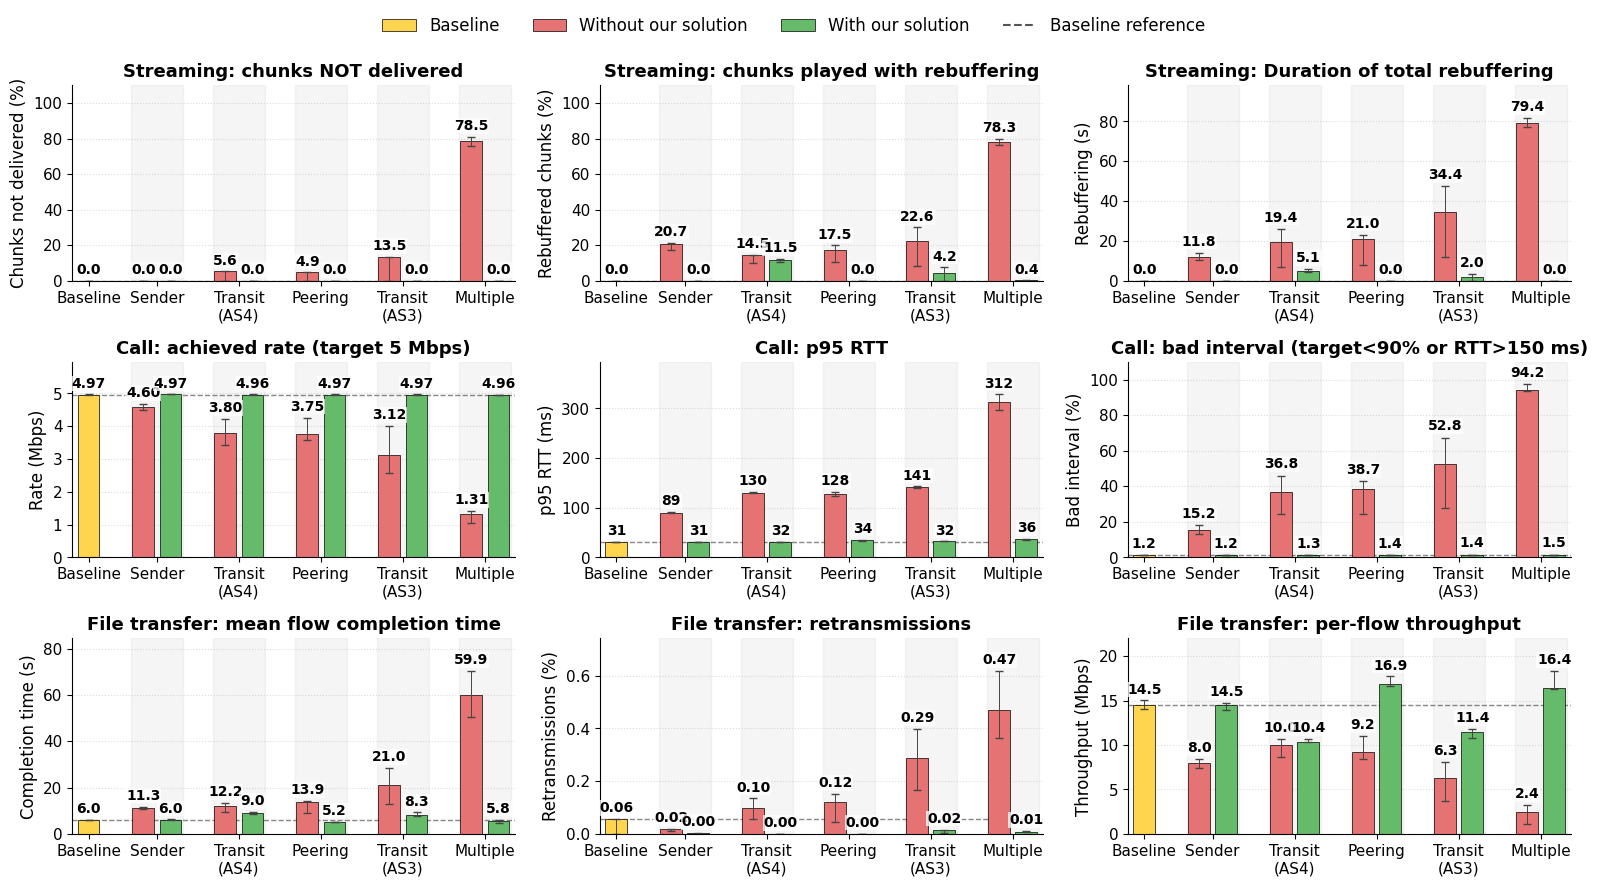

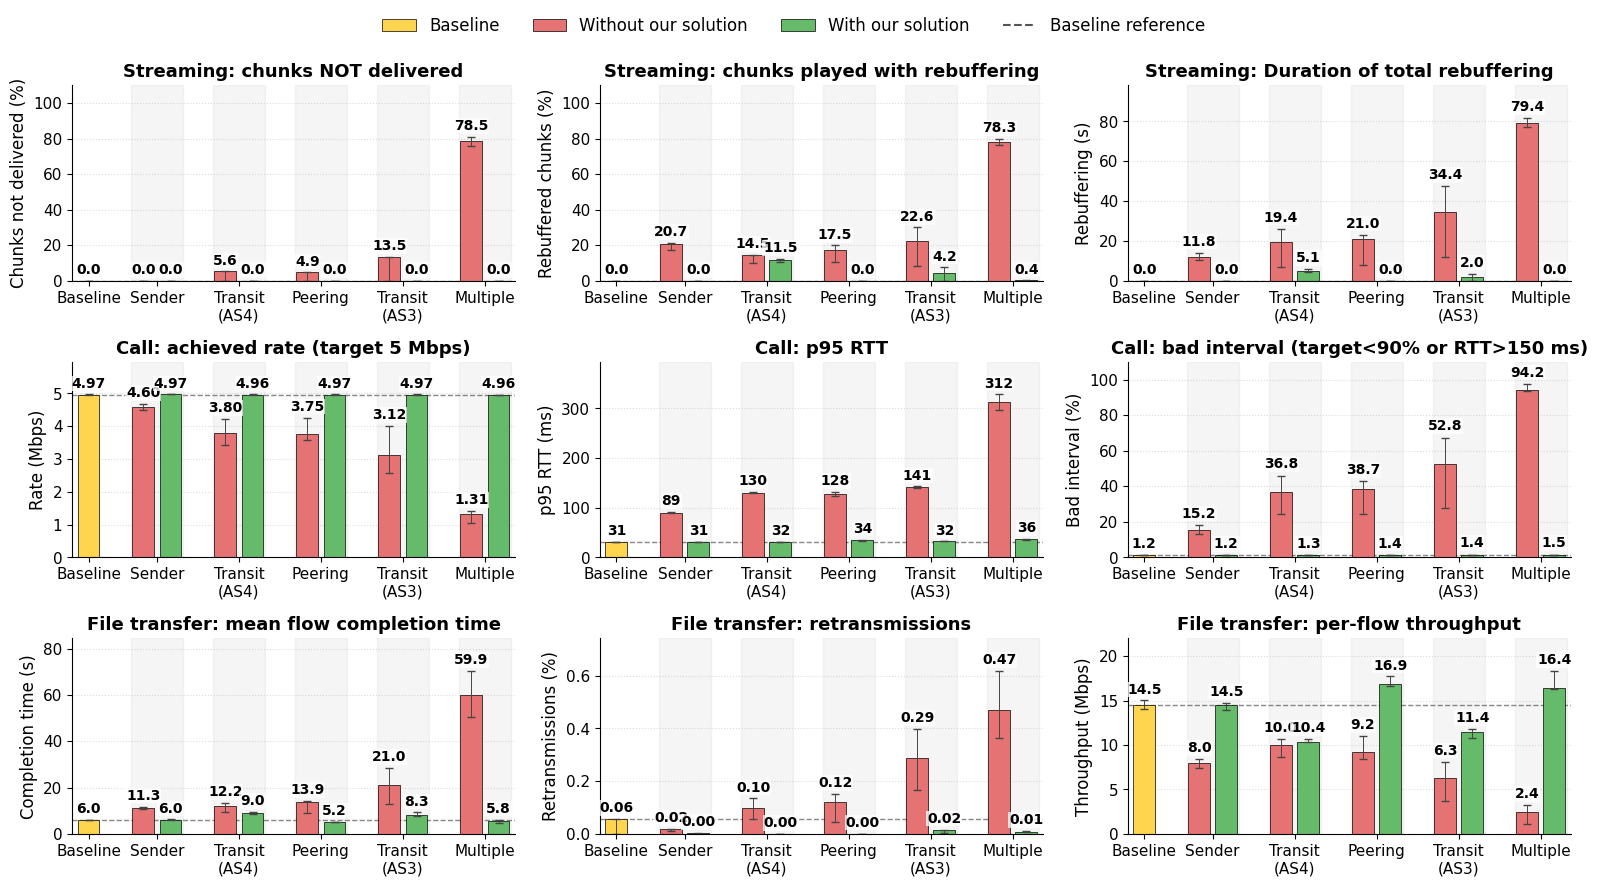

In [ ]:
plot1_app_performance(scenarios=['S1_access_only','S2a_sender_fifo','S2b_sender_priority','S3a_core_shared_fifo','S3b_core_srv6','S4a_peer_fifo','S4b_peer_priority','S5a_no_community','S5b_with_community','S6b_all_fifo_no_solution','S6c_full_solution'], save_path='plot1.pdf')

In [ ]:
analyze_scenario('S1_access_only')

  scenario S1_access_only: trials = [1, 2, 3, 4, 5, 6, 7, 8]
    wrote summary_trial1.json
    wrote summary_trial2.json
    wrote summary_trial3.json
    wrote summary_trial4.json
    wrote summary_trial5.json
    wrote summary_trial6.json
    wrote summary_trial7.json
    wrote summary_trial8.json
  wrote summary_aggregate.json


[1, 2, 3, 4, 5, 6, 7, 8]

In [ ]:
print_scenario_summary('S1_access_only')


=== S1_access_only  (8 trial(s)) ===
  L4S apps run: ['call', 'streaming', 'xfer']
  Streaming played chunks per flow                        30
  Streaming affected played chunks (%)                        0.00
  Streaming chunks triggering rebuf (%)                       0.00
  Streaming rebuffering per flow (s)                          0.00
  Call goodput per flow (Mbps)                                4.97
  Call achieved rate (%)                                     99.35
  Call p95 RTT (ms)                                          31.35
  Call bad interval (%)                                       1.16
  Xfer mean FCT (s)                                           5.99
  Xfer completion (%)                                       100.00
  Classic long mean throughput (Mbps)                        20.64
  Classic short mean FCT (s)                                  3.39
  L4S streaming mean throughput per flow (Mbps)              10.16
  L4S call mean goodput per flow (Mbps)            

In [ ]:
plot_qdisc_timeline('results/S1_access_only', trial=1, router_label='r-access-6',
                    capacity_mbps=100, save_path='r16_t1.png')

no samples at results/S1_access_only/qdisc_samples_r-access-6_trial1.txt


In [ ]:
apply_routing_state('on', 'on')   # bgp,srv6

In [ ]:
# === Path verification via NIC byte counters ===
# Snapshots /sys/class/net/*/statistics/{rx_bytes,tx_bytes} on every router
# before and after a short iperf3 run. Prints which routers/NICs forwarded
# the flow. Works regardless of SRv6 encap (traceroute doesn't).

import time

def _snapshot_nic_bytes(routers):
    snap = {}
    for name in routers:
        try:
            out, _ = slice.get_node(name).execute(
                "for nic in $(ls /sys/class/net | grep -E '^enp' | grep -v enp3s0); do "
                "  rx=$(cat /sys/class/net/$nic/statistics/rx_bytes); "
                "  tx=$(cat /sys/class/net/$nic/statistics/tx_bytes); "
                "  echo $nic $rx $tx; "
                "done",
                quiet=True
            )
            d = {}
            for line in (out or "").strip().splitlines():
                parts = line.split()
                if len(parts) == 3:
                    d[parts[0]] = (int(parts[1]), int(parts[2]))
            snap[name] = d
        except Exception as e:
            print(f"  [WARN] snapshot {name}: {e}")
    return snap


def verify_path(sender_node, receiver_node, dst_addr, cc, label,
                duration=10, port=5201, threshold_mb=5):
    """Run an iperf3 flow and report which router NICs forwarded > threshold_mb of bytes."""
    routers = [n["name"] for n in node_conf if n["name"].startswith("r-")]

    print()
    print("=" * 78)
    print(f"  {label}")
    print(f"    sender={sender_node.get_name()}  receiver={receiver_node.get_name()}")
    print(f"    target={dst_addr}  CC={cc}  duration={duration}s  port={port}")
    print("=" * 78)

    # Make sure CC is loaded on both ends
    for n in (sender_node, receiver_node):
        n.execute(f"sudo modprobe tcp_{cc} 2>/dev/null; "
                  f"sudo sysctl -w net.ipv4.tcp_congestion_control={cc} >/dev/null 2>&1; true",
                  quiet=True)
    # Set tcp_ecn=3 for prague, =1 for cubic
    ecn = 3 if cc == "prague" else 1
    for n in (sender_node, receiver_node):
        n.execute(f"sudo sysctl -w net.ipv4.tcp_ecn={ecn} >/dev/null 2>&1; true", quiet=True)

    # Kill any stale iperf3 on receiver, start fresh server
    receiver_node.execute("pkill -9 iperf3 2>/dev/null; true", quiet=True)
    time.sleep(0.5)
    receiver_node.execute(f"iperf3 -s -p {port} -D 2>/dev/null", quiet=True)
    time.sleep(1)

    # Snapshot before
    print("  [1/3] Snapshotting before...")
    before = _snapshot_nic_bytes(routers)

    # Run client
    print(f"  [2/3] Running iperf3 -c {dst_addr} -C {cc} -t {duration} -P 1 -p {port} ...")
    out, _ = sender_node.execute(
        f"iperf3 -c {dst_addr} -C {cc} -t {duration} -P 1 -p {port}",
        quiet=True
    )
    # Pull the summary lines
    summary = []
    for line in (out or "").splitlines():
        if "sender" in line.lower() or "receiver" in line.lower():
            summary.append(line.strip())
    if summary:
        print("    iperf3 summary:")
        for s in summary[-2:]:
            print(f"      {s}")
    else:
        print("    iperf3 produced no summary — check connectivity.")

    # Snapshot after
    print("  [3/3] Snapshotting after...")
    after = _snapshot_nic_bytes(routers)

    # Cleanup server
    receiver_node.execute("pkill -9 iperf3 2>/dev/null; true", quiet=True)

    # Compute deltas
    rows = []
    for name in routers:
        for nic in sorted(set(before.get(name, {})) | set(after.get(name, {}))):
            rx_b, tx_b = before.get(name, {}).get(nic, (0, 0))
            rx_a, tx_a = after.get(name, {}).get(nic, (0, 0))
            drx_mb = (rx_a - rx_b) / 1e6
            dtx_mb = (tx_a - tx_b) / 1e6
            if drx_mb >= threshold_mb or dtx_mb >= threshold_mb:
                rows.append((name, nic, drx_mb, dtx_mb))

    # Sort by router name for readability
    rows.sort(key=lambda r: (r[0], r[1]))

    print(f"\n  Routers/NICs that carried > {threshold_mb} MB during the flow:")
    if not rows:
        print(f"    (none — flow may have failed, or was below threshold)")
    else:
        print(f"    {'router':<14} {'NIC':<10} {'RX (MB)':>10} {'TX (MB)':>10}")
        print(f"    {'-'*14} {'-'*10} {'-'*10} {'-'*10}")
        for name, nic, rx, tx in rows:
            print(f"    {name:<14} {nic:<10} {rx:>10.1f} {tx:>10.1f}")

    return rows


print("verify_path defined.")

verify_path defined.


In [ ]:
# === Run the two verification flows ===
# Make sure no foreground/background traffic is running before this.

# 1) L4S flow: e_0_5 -> e_0_6 (fd00:6::2)  with TCP Prague
l4s_rows = verify_path(
    sender_node   = e_0_5,
    receiver_node = e_0_6,
    dst_addr      = "fd00:6::2",
    cc            = "prague",
    label         = "L4S path verification",
    duration      = 10,
    port          = 5201,
)

# small gap so counters don't blur between tests
import time as _t; _t.sleep(3)

# 2) Classic flow: e_1_5 -> e_1_6 (fd00:6::3)  with TCP Cubic
classic_rows = verify_path(
    sender_node   = e_1_5,
    receiver_node = e_1_6,
    dst_addr      = "fd00:6::3",
    cc            = "cubic",
    label         = "Classic path verification",
    duration      = 10,
    port          = 5202,    # different port to avoid any leftover-server ambiguity
)


  L4S path verification
    sender=e-0-5  receiver=e-0-6
    target=fd00:6::2  CC=prague  duration=10s  port=5201
  [1/3] Snapshotting before...
  [2/3] Running iperf3 -c fd00:6::2 -C prague -t 10 -P 1 -p 5201 ...
    iperf3 summary:
      [  5]   0.00-10.00  sec  88.0 MBytes  73.8 Mbits/sec    0            sender
      [  5]   0.00-10.03  sec  87.5 MBytes  73.2 Mbits/sec                  receiver
  [3/3] Snapshotting after...

  Routers/NICs that carried > 5 MB during the flow:
    router         NIC           RX (MB)    TX (MB)
    -------------- ---------- ---------- ----------
    r-1-2          enp8s0          104.4        6.2
    r-1-2          enp9s0            3.4       98.9
    r-1-4          enp7s0            6.2      104.4
    r-1-4          enp8s0           98.9        3.4
    r-2-1          enp7s0            6.2      104.4
    r-2-1          enp8s0           98.9        3.4
    r-2-6          enp7s0            3.4       98.9
    r-2-6          enp8s0          104.4       

## Delete Slice

In [ ]:

from fabrictestbed_extensions.fablib.fablib import FablibManager as fablib_manager
fablib = fablib_manager()
SLICE_NAME   = "RUTG-topo"
slice = fablib.get_slice(SLICE_NAME)
fablib.delete_slice(SLICE_NAME)
slice.update()
_ = slice.show()

